**California House Prices**

#Analisis explotorio de datos

### Cargar datos


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import make_regression
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Configuración de estilo
plt.style.use('default')
sns.set_palette("husl")

np.random.seed(42)

# Cargar datos desde el archivo CSV
df = pd.read_csv('/content/housing.csv')

print("Dimensión del dataset:", df.shape)
print("\nPrimeras 5 filas:")
display(df.head())

Dimensión del dataset: (20640, 10)

Primeras 5 filas:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Revisión de Valores Nulos

Es fundamental verificar la presencia de valores nulos en el dataset, ya que pueden afectar negativamente los análisis estadísticos y el rendimiento de los modelos de Machine Learning. Identificar y manejar estos valores es un paso crítico en el preprocesamiento de datos.

In [6]:
print("### Conteo de Valores Nulos por Columna\n")

# Contar valores nulos por columna
null_counts = df.isnull().sum()

# Filtrar y mostrar solo las columnas con valores nulos
columns_with_nulls = null_counts[null_counts > 0]

if not columns_with_nulls.empty:
    print("Columnas con valores nulos:")
    display(columns_with_nulls.to_frame(name='Cantidad de Nulos'))
    print("\nPorcentaje de valores nulos por columna:")
    display((columns_with_nulls / len(df) * 100).to_frame(name='Porcentaje de Nulos (%)'))
else:
    print("No se encontraron valores nulos en el dataset.")

### Conteo de Valores Nulos por Columna

Columnas con valores nulos:


,Cantidad de Nulos
total_bedrooms,207



Porcentaje de valores nulos por columna:


,Porcentaje de Nulos (%)
total_bedrooms,1.002907


### Preprocesamiento de Datos



In [7]:
print("### 2. Codificación One-Hot para 'ocean_proximity'\n")

df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=False) # Mantener todas las columnas para evitar problemas si una categoría se pierde

print("DataFrame después de One-Hot Encoding:")
display(df.head())

### 2. Codificación One-Hot para 'ocean_proximity'

DataFrame después de One-Hot Encoding:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


In [8]:
print("### 3. Imputando valores nulos en 'total_bedrooms' con la mediana (pre-escalado)\n")

# Verificar nulos antes de imputar
print("Valores nulos antes de imputación:")
display(df.isnull().sum()[df.isnull().sum() > 0].to_frame(name='Cantidad de Nulos'))

# Calcular la mediana de 'total_bedrooms' en los datos *originales/sin escalar*
median_total_bedrooms_unscaled = df['total_bedrooms'].median()

# Imputar los valores nulos con la mediana
df['total_bedrooms'].fillna(median_total_bedrooms_unscaled, inplace=True)

print(f"Valores nulos en 'total_bedrooms' imputados con la mediana: {median_total_bedrooms_unscaled}")

# Verificar de nuevo los valores nulos para confirmar
print("\nRevisión de Valores Nulos después de la imputación:")
display(df.isnull().sum().to_frame(name='Cantidad de Nulos'))

### 3. Imputando valores nulos en 'total_bedrooms' con la mediana (pre-escalado)

Valores nulos antes de imputación:


,Cantidad de Nulos
total_bedrooms,207


Valores nulos en 'total_bedrooms' imputados con la mediana: 435.0

Revisión de Valores Nulos después de la imputación:


,Cantidad de Nulos
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity_<1H OCEAN,0


In [9]:
from sklearn.preprocessing import StandardScaler

print("### 4. Escalado de Características Numéricas\n")

scaler = StandardScaler()
# Seleccionar solo las columnas numéricas que se van a escalar (excluyendo las dummificadas si no son binarias 0/1)
# En este caso, todas las columnas son numéricas después del get_dummies y la imputación
columnas_a_escalar = df.select_dtypes(include=[np.number]).columns.tolist()

# Asegurarse de no escalar columnas binarias si el modelo lo maneja mejor así o si fueron creadas por get_dummies
# En este caso, las columnas de ocean_proximity son 0/1 y no necesitan ser escaladas por StandardScaler.
# Excluiremos las columnas de 'ocean_proximity' creadas por get_dummies si existieran.
# Primero, identificamos cuáles son las columnas dummificadas
dummy_cols = [col for col in columnas_a_escalar if 'ocean_proximity_' in col]

# Excluir las columnas dummificadas de la lista de columnas a escalar
columnas_numericas_para_escalar = [col for col in columnas_a_escalar if col not in dummy_cols]

# Aplicar el escalador solo a las columnas numéricas relevantes
df[columnas_numericas_para_escalar] = scaler.fit_transform(df[columnas_numericas_para_escalar])

print("DataFrame después del escalado (primeras 5 filas):")
display(df.head())

print("\nEstadísticas descriptivas después del escalado (para confirmar):")
display(df.describe())

### 4. Escalado de Características Numéricas

DataFrame después del escalado (primeras 5 filas):


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,2.129631,False,False,False,True,False
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,1.314156,False,False,False,True,False
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,1.258693,False,False,False,True,False
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,1.165100,False,False,False,True,False
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,1.172900,False,False,False,True,False



Estadísticas descriptivas después del escalado (para confirmar):


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04
mean,-8.526513e-15,-1.079584e-15,5.508083e-18,3.201573e-17,-9.363741e-17,-1.101617e-17,6.885104e-17,6.609700e-17,-9.363741e-17
std,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00
min,-2.385992e+00,-1.447568e+00,-2.196180e+00,-1.207283e+00,-1.277688e+00,-1.256123e+00,-1.303984e+00,-1.774299e+00,-1.662641e+00
25%,-1.113209e+00,-7.967887e-01,-8.453931e-01,-5.445698e-01,-5.718868e-01,-5.638089e-01,-5.742294e-01,-6.881186e-01,-7.561633e-01
50%,5.389137e-01,-6.422871e-01,2.864572e-02,-2.332104e-01,-2.428309e-01,-2.291318e-01,-2.368162e-01,-1.767951e-01,-2.353337e-01
75%,7.784964e-01,9.729566e-01,6.643103e-01,2.348028e-01,2.537334e-01,2.644949e-01,2.758427e-01,4.593063e-01,5.014973e-01
max,2.625280e+00,2.958068e+00,1.856182e+00,1.681558e+01,1.408779e+01,3.025033e+01,1.460152e+01,5.858286e+00,2.540411e+00


In [10]:
print("### Imputando valores nulos en 'total_bedrooms' con la mediana\n")

# Calcular la mediana de 'total_bedrooms'
median_total_bedrooms = df['total_bedrooms'].median()

# Imputar los valores nulos con la mediana
df['total_bedrooms'].fillna(median_total_bedrooms, inplace=True)

print(f"Valores nulos en 'total_bedrooms' imputados con la mediana: {median_total_bedrooms}")

# Verificar de nuevo los valores nulos para confirmar
print("\nRevisión de Valores Nulos después de la imputación:")
display(df.isnull().sum().to_frame(name='Cantidad de Nulos'))

### Imputando valores nulos en 'total_bedrooms' con la mediana

Valores nulos en 'total_bedrooms' imputados con la mediana: -0.24283093943077497

Revisión de Valores Nulos después de la imputación:


,Cantidad de Nulos
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity_<1H OCEAN,0


####Justificacion



El preprocesamiento de datos es una fase crítica para preparar el conjunto de datos para el modelado, asegurando que los algoritmos puedan trabajar con información limpia, relevante y en el formato adecuado. Durante este proceso, se realizaron las siguientes transformaciones y justificaciones:

1.  **Manejo de Valores Nulos en `total_bedrooms`:**
    *   **Problema Identificado:** Se detectaron 207 valores nulos (aproximadamente el 1% del total) en la columna `total_bedrooms`.
    *   **Justificación de la Solución:** Dada la pequeña proporción de valores nulos y para mantener la integridad del dataset sin eliminar filas, se optó por la **imputación con la mediana**. La mediana es una medida robusta que no se ve afectada significativamente por valores atípicos y es adecuada para distribuciones que pueden ser asimétricas, como las que suelen encontrarse en el conteo de habitaciones. Es crucial destacar que esta imputación se realizó *antes* del escalado para asegurar la coherencia lógica de los valores (evitando números negativos ilógicos).

2.  **Codificación One-Hot para `ocean_proximity`:**
    *   **Problema Identificado:** La columna `ocean_proximity` es de tipo categórico nominal, conteniendo etiquetas textuales que los modelos de Machine Learning no pueden procesar directamente.
    *   **Justificación de la Solución:** Se aplicó la técnica de **One-Hot Encoding** para transformar esta característica categórica en un formato numérico binario. Esto crea nuevas columnas (una por cada categoría única), donde un '1' indica la presencia de esa categoría y un '0' su ausencia. Esta técnica evita introducir una relación de orden artificial que podría ocurrir con otras codificaciones numéricas.

3.  **Escalado de Características Numéricas:**
    *   **Problema Identificado:** Las columnas numéricas en el dataset (como `total_rooms`, `population`, `median_income`, etc.) tienen rangos de valores y escalas muy diferentes.
    *   **Justificación de la Solución:** Se utilizó el **StandardScaler** para estandarizar estas características. El escalado transforma los datos para que tengan una media de 0 y una desviación estándar de 1. Esto es fundamental para muchos algoritmos de Machine Learning (como regresión lineal, SVMs, redes neuronales, o aquellos basados en distancias) ya que evita que las características con valores más grandes dominen la función de costo y el proceso de aprendizaje del modelo, mejorando su rendimiento y estabilidad.


## Estadisticas descriptivas


Estadísticas descriptivas:
          longitude      latitude  housing_median_age   total_rooms  \
count  2.064000e+04  2.064000e+04        2.064000e+04  2.064000e+04   
mean  -8.526513e-15 -1.079584e-15        5.508083e-18  3.201573e-17   
std    1.000024e+00  1.000024e+00        1.000024e+00  1.000024e+00   
min   -2.385992e+00 -1.447568e+00       -2.196180e+00 -1.207283e+00   
25%   -1.113209e+00 -7.967887e-01       -8.453931e-01 -5.445698e-01   
50%    5.389137e-01 -6.422871e-01        2.864572e-02 -2.332104e-01   
75%    7.784964e-01  9.729566e-01        6.643103e-01  2.348028e-01   
max    2.625280e+00  2.958068e+00        1.856182e+00  1.681558e+01   

       total_bedrooms    population    households  median_income  \
count    2.064000e+04  2.064000e+04  2.064000e+04   2.064000e+04   
mean    -9.363741e-17 -1.101617e-17  6.885104e-17   6.609700e-17   
std      1.000024e+00  1.000024e+00  1.000024e+00   1.000024e+00   
min     -1.277688e+00 -1.256123e+00 -1.303984e+00  -1.774299e

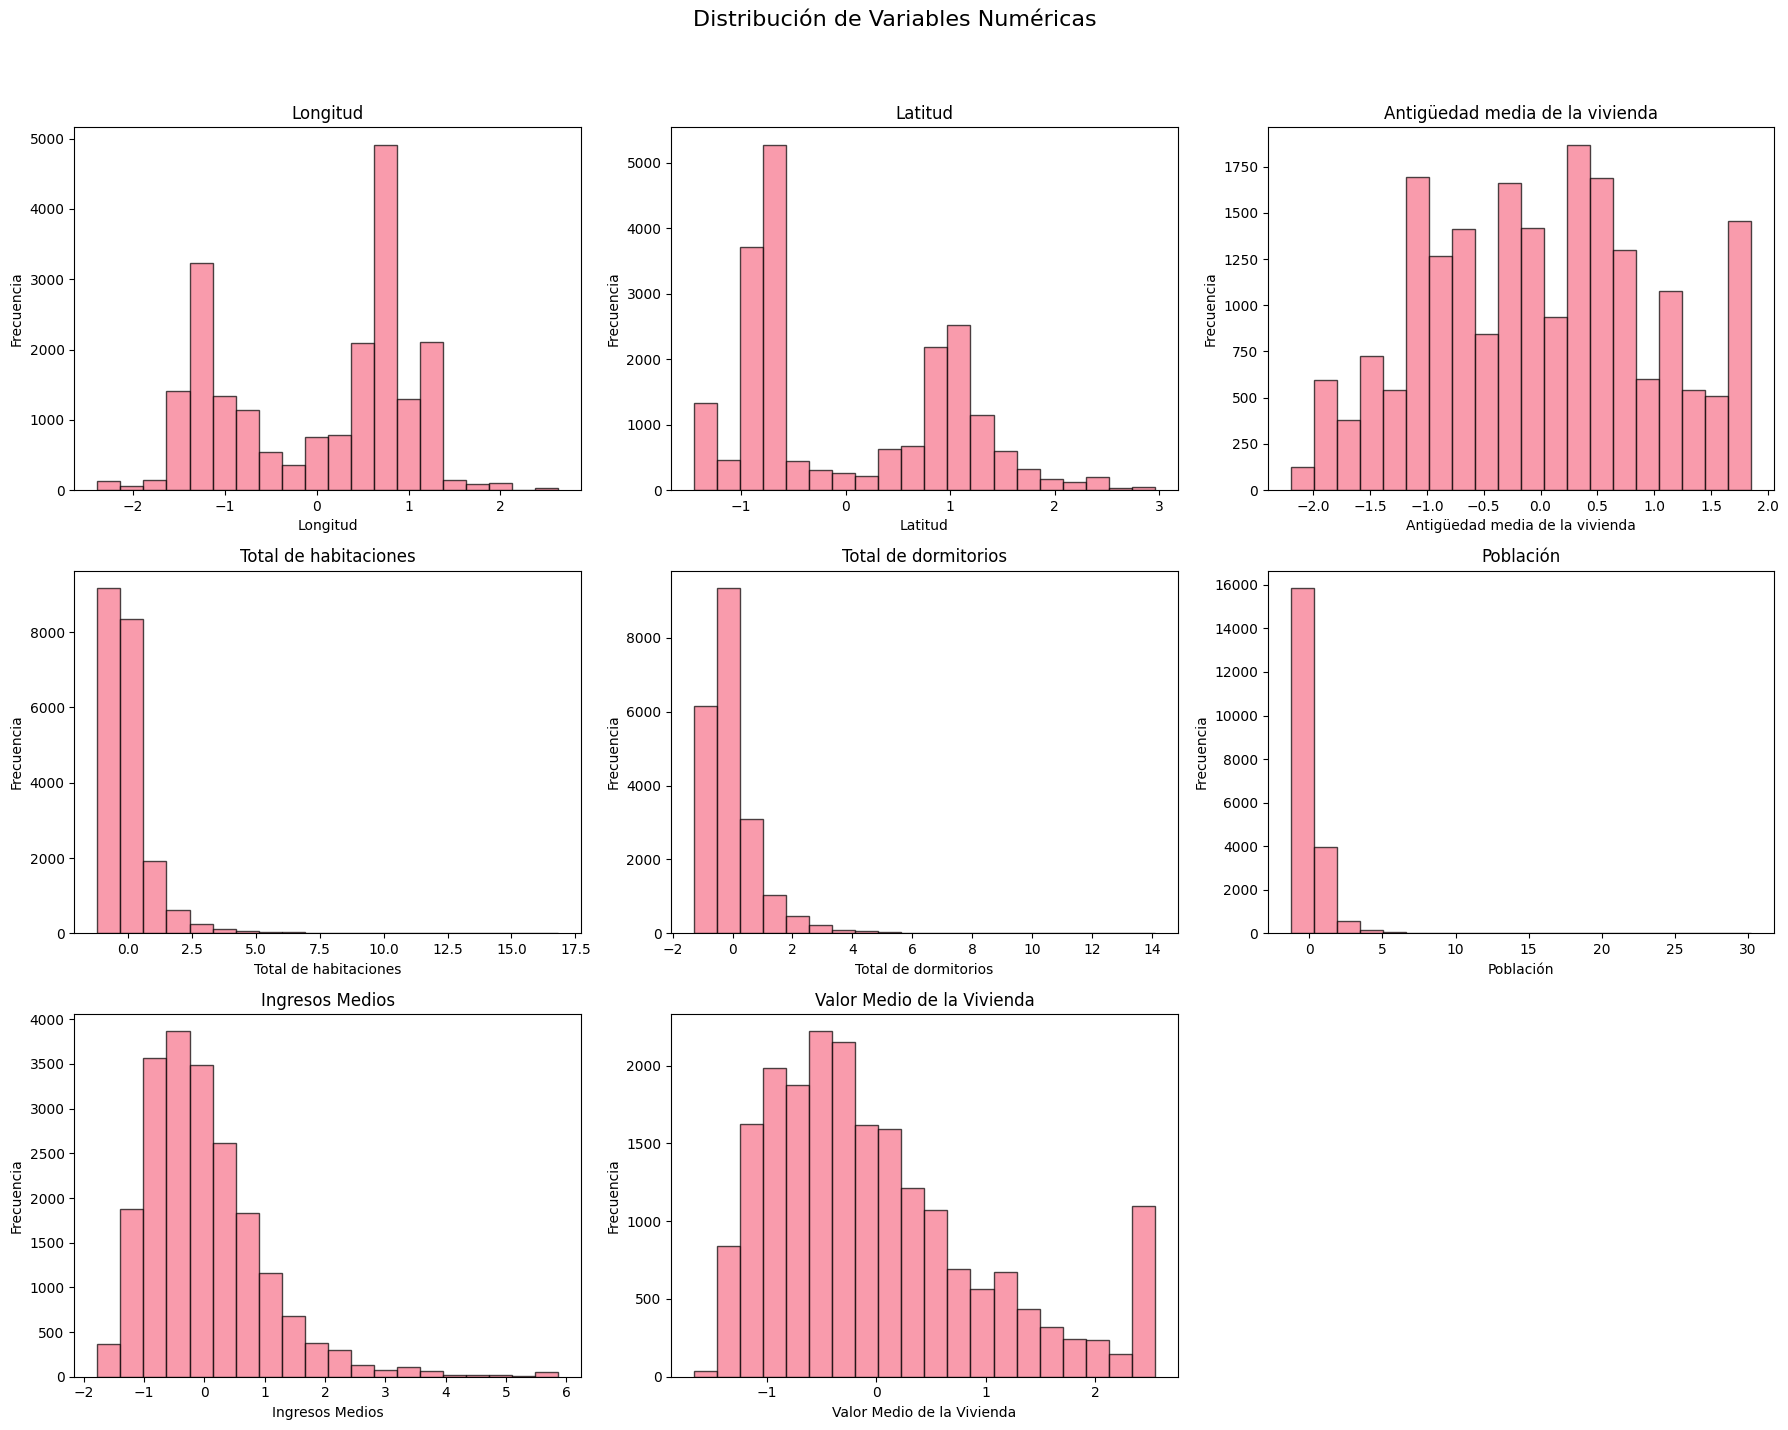

In [11]:
print("Estadísticas descriptivas:")
print(df.describe())

# Visualización de las variables numéricas
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Distribución de Variables Numéricas', fontsize=16)

# Seleccionamos todas las columnas numéricas relevantes de 'df' para visualizar
variables = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'median_income', 'median_house_value']
titles = ['Longitud', 'Latitud', 'Antigüedad media de la vivienda', 'Total de habitaciones', 'Total de dormitorios', 'Población', 'Ingresos Medios', 'Valor Medio de la Vivienda']

for i, (var, title) in enumerate(zip(variables, titles)):
    row, col = i // 3, i % 3
    axes[row, col].hist(df[var], bins=20, alpha=0.7, edgecolor='black')
    axes[row, col].set_title(title)
    axes[row, col].set_xlabel(title)
    axes[row, col].set_ylabel('Frecuencia')

# Ocultar los ejes no utilizados si hay un número impar de gráficos en la última fila
if len(variables) < 3 * 3:
    for j in range(len(variables), 3 * 3):
        row, col = j // 3, j % 3
        fig.delaxes(axes[row, col])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

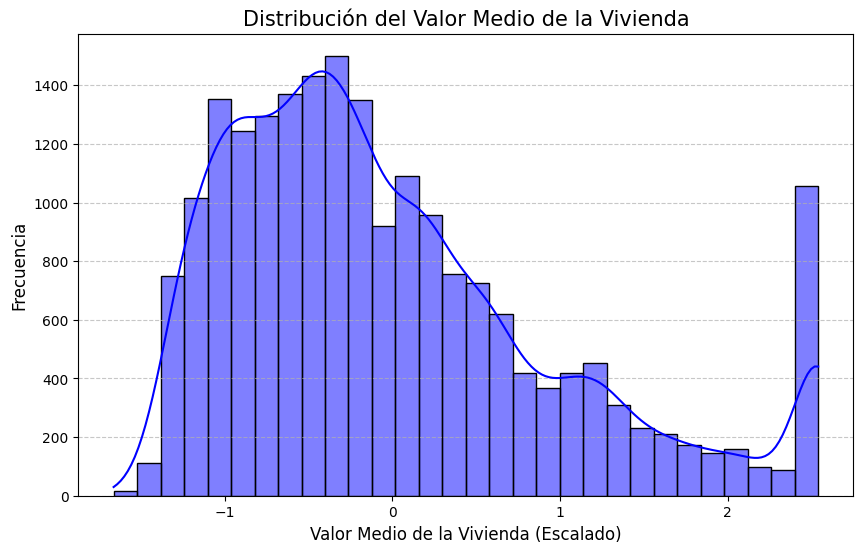

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización del histograma de la variable objetivo
plt.figure(figsize=(10, 6))
sns.histplot(df['median_house_value'], bins=30, kde=True, color='blue', edgecolor='black')

plt.title('Distribución del Valor Medio de la Vivienda', fontsize=15)
plt.xlabel('Valor Medio de la Vivienda (Escalado)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Análisis de Outliers




In [12]:
print("### Conteo de Outliers por Columna (Método IQR)\n")

# Identificar columnas numéricas, incluyendo las dummificadas
numericas = df.select_dtypes(include=['float64', 'int64']).columns

outliers_summary = {}

for col in numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Contar outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_count = outliers.shape[0]

    # Calcular el porcentaje de outliers
    percentage_outliers = (outliers_count / len(df)) * 100

    if outliers_count > 0:
        outliers_summary[col] = {
            'count': outliers_count,
            'percentage': f"{percentage_outliers:.2f}%"
        }

if outliers_summary:
    for col, data in outliers_summary.items():
        print(f"Columna '{col}': {data['count']} outliers ({data['percentage']})")
else:
    print("No se detectaron outliers significativos usando el método IQR (1.5 * IQR).")


### Conteo de Outliers por Columna (Método IQR)

Columna 'total_rooms': 1287 outliers (6.24%)
Columna 'total_bedrooms': 1306 outliers (6.33%)
Columna 'population': 1196 outliers (5.79%)
Columna 'households': 1220 outliers (5.91%)
Columna 'median_income': 681 outliers (3.30%)
Columna 'median_house_value': 1071 outliers (5.19%)


### Visualización de Outliers con Diagramas de Dispersión



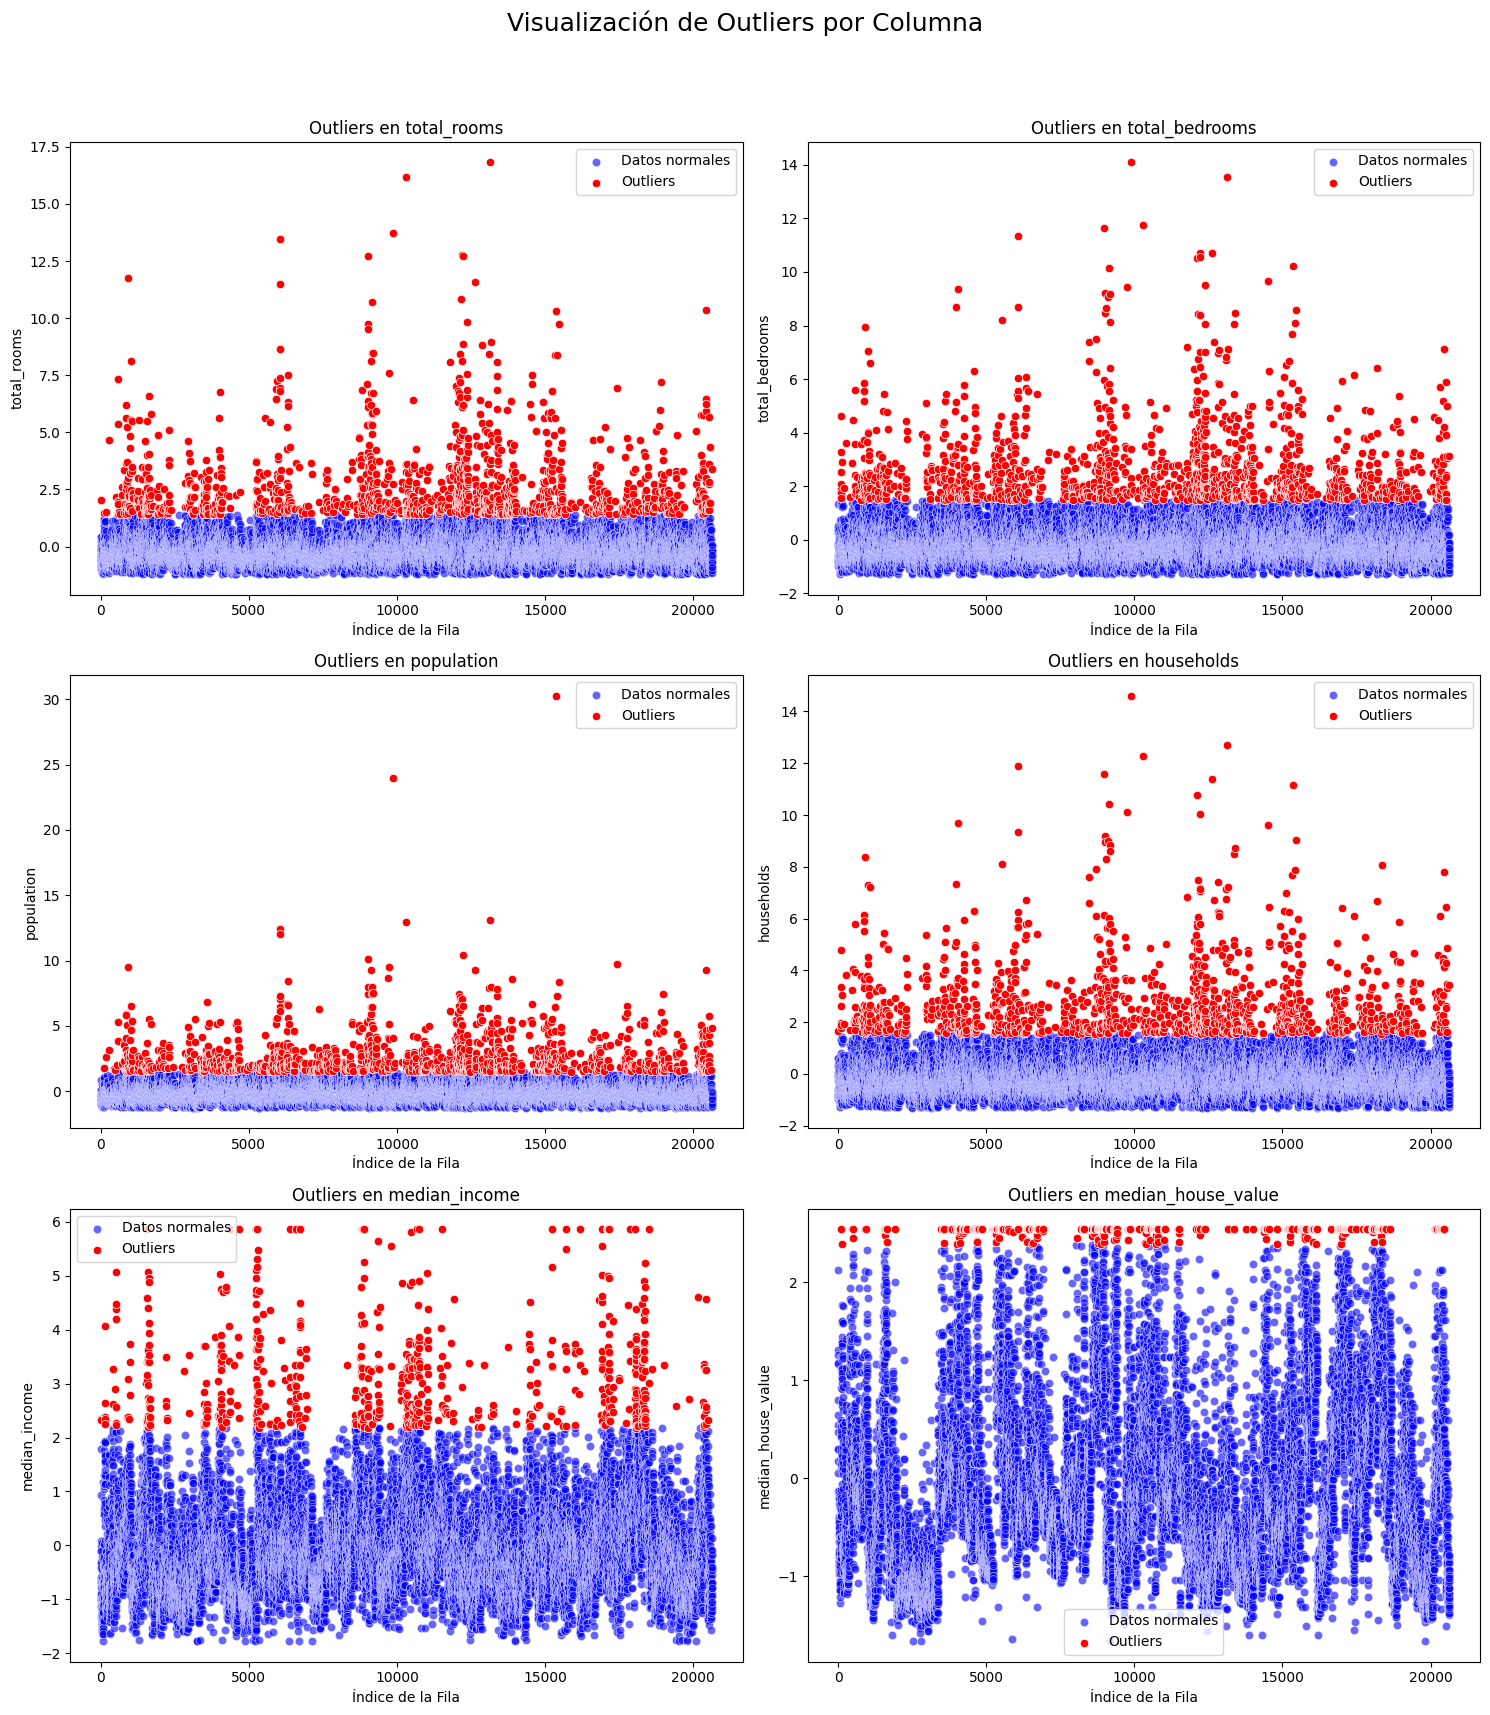

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

print("### Visualización de Outliers con Diagramas de Dispersión\n")

# Obtener las columnas que tenían outliers de la ejecución anterior
# (outliers_summary está disponible en el estado del kernel)

# Seleccionar las columnas con outliers para visualizar
# Tomaremos hasta 6 columnas para evitar demasiados gráficos a la vez
columns_to_plot = list(outliers_summary.keys())[:6]

# Crear subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
fig.suptitle('Visualización de Outliers por Columna', fontsize=18)
axes = axes.flatten() # Aplanar para facilitar la iteración

for i, col in enumerate(columns_to_plot):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identificar outliers para la columna actual
    outliers_mask = (df[col] < lower_bound) | (df[col] > upper_bound)

    # Crear el scatter plot
    sns.scatterplot(x=df.index, y=df[col], ax=axes[i], color='blue', alpha=0.6, label='Datos normales')
    sns.scatterplot(x=df[outliers_mask].index, y=df[outliers_mask][col], ax=axes[i], color='red', label='Outliers')

    axes[i].set_title(f'Outliers en {col}')
    axes[i].set_xlabel('Índice de la Fila')
    axes[i].set_ylabel(col)
    axes[i].legend()

# Ocultar los ejes no utilizados si hay menos de 6 gráficos
if len(columns_to_plot) < len(axes):
    for j in range(len(columns_to_plot), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Matrices


DataFrame 'df' preprocesado y listo para el análisis.


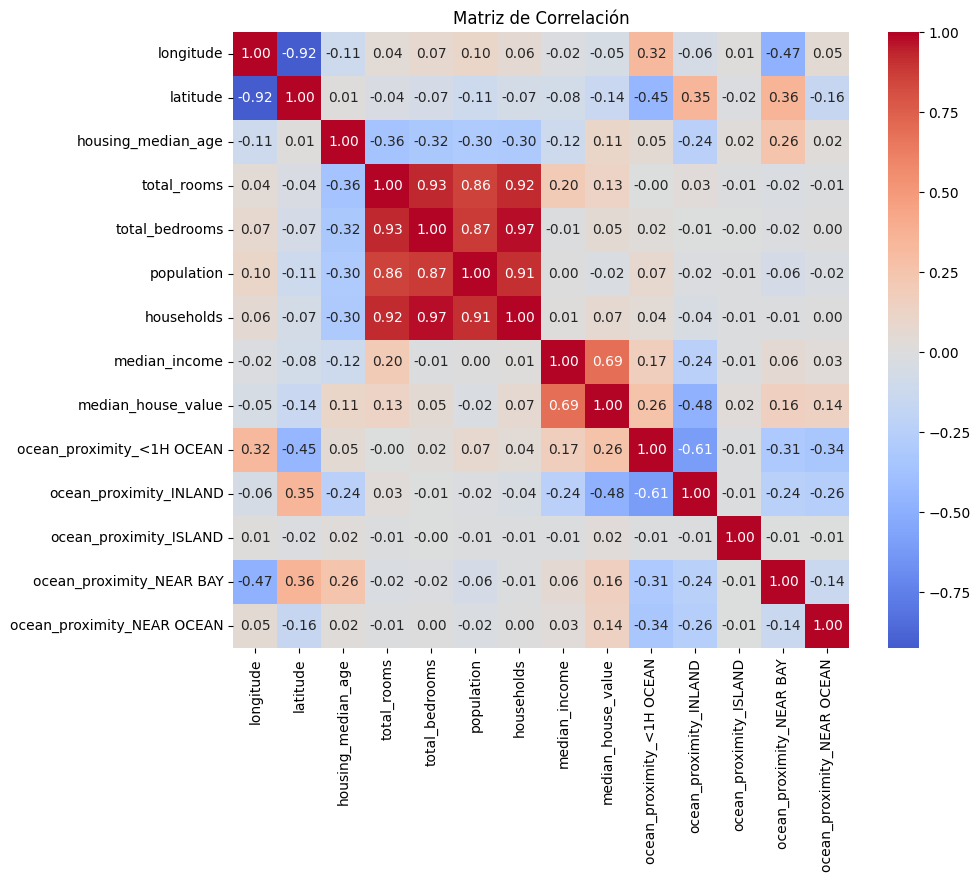

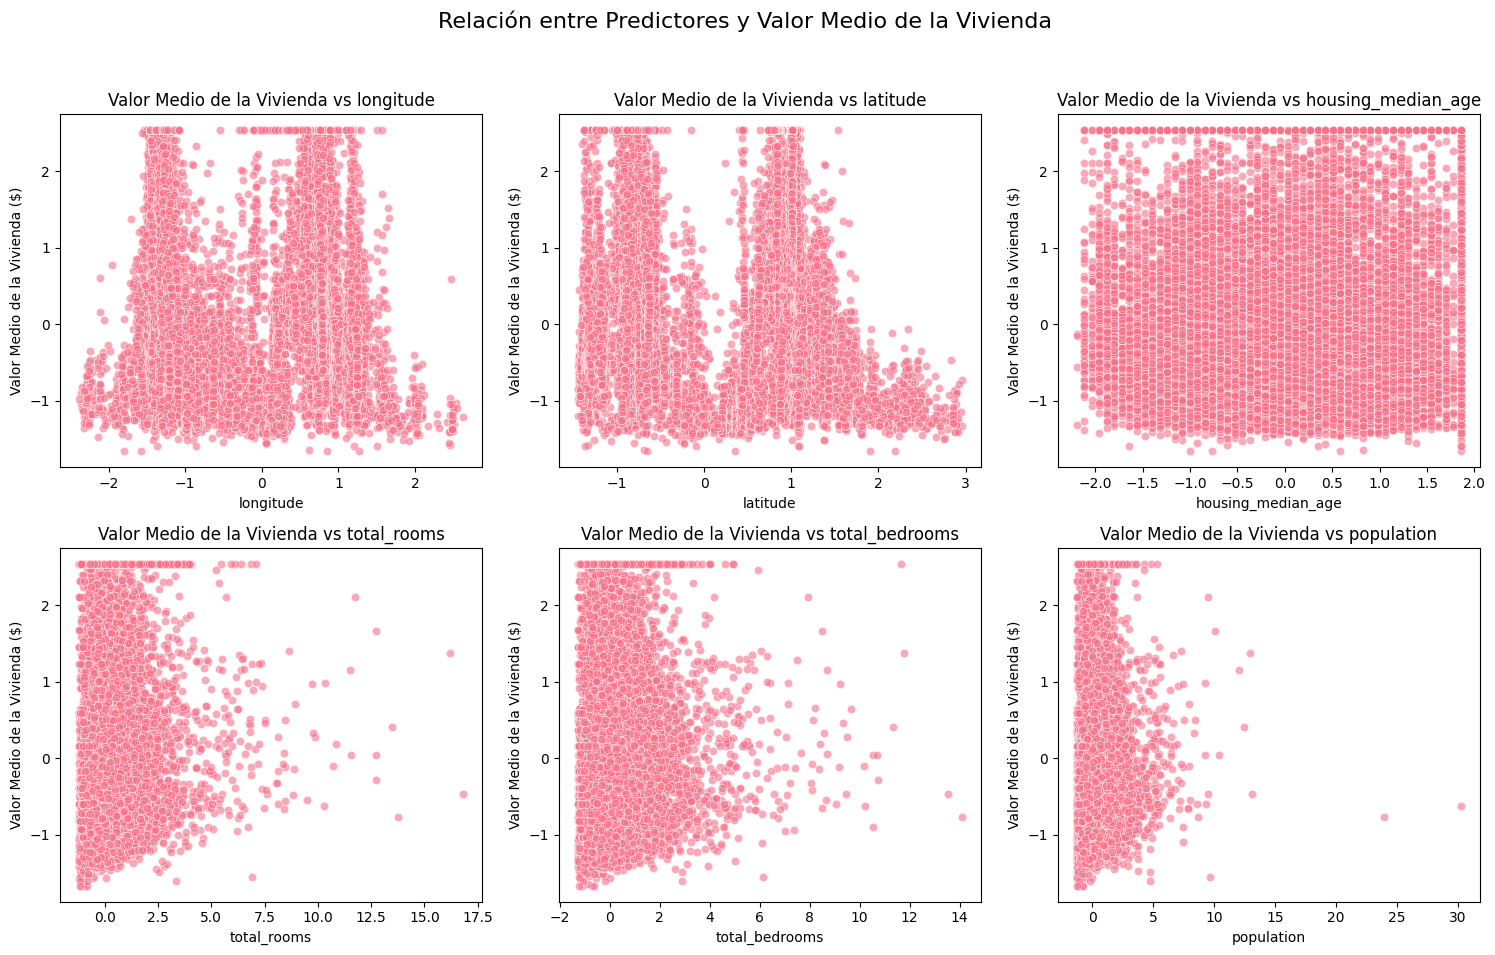

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# --- Re-Preprocesamiento del DataFrame 'df' para asegurar su disponibilidad ---
# Cargar datos desde el archivo CSV
df = pd.read_csv('/content/housing.csv')

# Codificación One-Hot para 'ocean_proximity'
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=False)

# Imputar valores nulos en 'total_bedrooms' con la mediana (pre-escalado)
median_total_bedrooms_unscaled = df['total_bedrooms'].median()
df['total_bedrooms'].fillna(median_total_bedrooms_unscaled, inplace=True)

# Escalado de Características Numéricas
scaler = StandardScaler()
columnas_a_escalar = df.select_dtypes(include=[np.number]).columns.tolist()
dummy_cols = [col for col in columnas_a_escalar if 'ocean_proximity_' in col]
columnas_numericas_para_escalar = [col for col in columnas_a_escalar if col not in dummy_cols]
df[columnas_numericas_para_escalar] = scaler.fit_transform(df[columnas_numericas_para_escalar])

print("DataFrame 'df' preprocesado y listo para el análisis.")

# --- Matriz de correlación ---
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

# --- Relaciones entre variables numéricas y median_house_value ---
# Excluimos 'median_house_value' de los predictores para evitar graficarla contra sí misma
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('median_house_value', errors='ignore')

# Determinar el número de filas y columnas para los subplots
# Si hay más de 6 columnas, solo mostramos las primeras 6 para mantener la legibilidad.
num_plots = min(len(numerical_cols), 6)
num_rows = (num_plots + 2) // 3 # Divide en 3 columnas por fila
num_cols = min(num_plots, 3)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
fig.suptitle('Relación entre Predictores y Valor Medio de la Vivienda', fontsize=16)

# Aplanar los ejes para facilitar la iteración
axes = axes.flatten()

for i, var in enumerate(numerical_cols[:num_plots]):
    sns.scatterplot(x=df[var], y=df['median_house_value'], ax=axes[i], alpha=0.6)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Valor Medio de la Vivienda ($)')
    axes[i].set_title(f'Valor Medio de la Vivienda vs {var}')

# Ocultar los ejes no utilizados si hay un número impar de gráficos en la última fila
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Analisis Longitud y Latitud


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
columnas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
df[columnas_numericas] = scaler.fit_transform(df[columnas_numericas])

### Visualización Geográfica del Valor Medio de la Vivienda



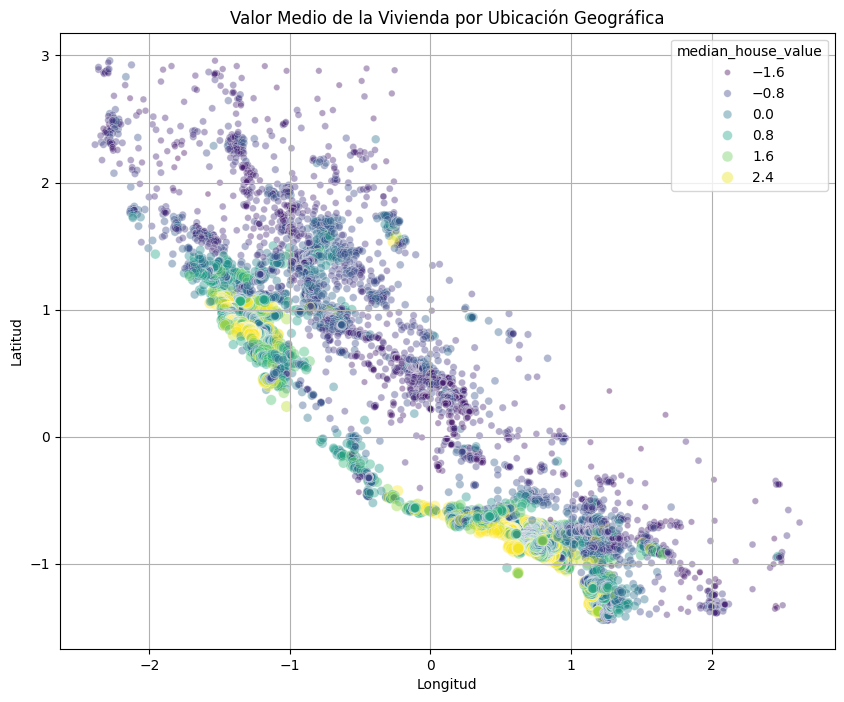

In [16]:
print("### Visualización Geográfica del Valor Medio de la Vivienda\n")

plt.figure(figsize=(10, 8))
sns.scatterplot(x='longitude', y='latitude', hue='median_house_value',
                size='median_house_value', data=df, palette='viridis', alpha=0.4)
plt.title('Valor Medio de la Vivienda por Ubicación Geográfica')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True)
plt.show()

### Impacto de 'ocean_proximity' en el 'median_house_value'

Para esta visualización, cargaremos temporalmente el DataFrame original para ver el impacto de la columna categórica `ocean_proximity` en el `median_house_value` antes de que se aplicaran las transformaciones (dummification y escalado).

### Valor Medio de la Vivienda por Proximidad al Océano



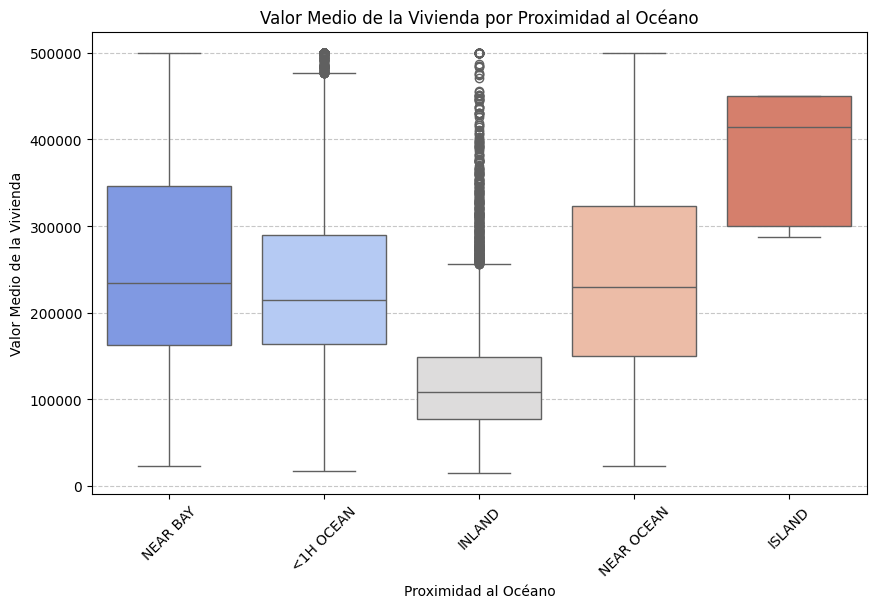

,median_house_value
ocean_proximity,
ISLAND,380440.000000
NEAR BAY,259212.311790
NEAR OCEAN,249433.977427
<1H OCEAN,240084.285464
INLAND,124805.392001


In [17]:
print("### Valor Medio de la Vivienda por Proximidad al Océano\n")

# Cargar el dataframe original temporalmente para la visualización
df_original = pd.read_csv('/content/housing.csv')

plt.figure(figsize=(10, 6))
sns.boxplot(x='ocean_proximity', y='median_house_value', data=df_original, palette='coolwarm')
plt.title('Valor Medio de la Vivienda por Proximidad al Océano')
plt.xlabel('Proximidad al Océano')
plt.ylabel('Valor Medio de la Vivienda')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Puedes también ver los valores medios directamente:
display(df_original.groupby('ocean_proximity')['median_house_value'].mean().sort_values(ascending=False))

# Aplicación de modelos


# Modelos con todas las variables


### Dividir Datos en Entrenamiento y Prueba



Dividir el dataset preprocesado (`df`) en características (X) y variable objetivo (y, que es `median_house_value`). Luego, dividir X y y en conjuntos de entrenamiento y prueba para evaluar el rendimiento de los modelos.


In [18]:
from sklearn.model_selection import train_test_split

# 1. Separar características (X) de la variable objetivo (y)
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

# 2. Dividir X e y en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nDimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

Dimensiones de X: (20640, 13)
Dimensiones de y: (20640,)

Dimensiones de X_train: (16512, 13)
Dimensiones de X_test: (4128, 13)
Dimensiones de y_train: (16512,)
Dimensiones de y_test: (4128,)


### Implementar Regresión Lineal Múltiple


Entrenar un modelo de Regresión Lineal Múltiple utilizando el conjunto de entrenamiento. Luego, realizar predicciones sobre el conjunto de prueba y evaluar su rendimiento utilizando métricas como el Error Cuadrático Medio (MSE), el Error Absoluto Medio (MAE) y el coeficiente de determinación R².


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1 & 2. Crear una instancia del modelo LinearRegression
model = LinearRegression()

# 3. Entrenar el modelo utilizando los datos de entrenamiento
model.fit(X_train, y_train)

print("Modelo de Regresión Lineal Múltiple entrenado.")

# 4. Realizar predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test)

# 5, 6, 7 & 8. Calcular métricas de evaluación
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 9. Imprimir los valores de MSE, MAE y R²
print(f"\nError Cuadrático Medio (MSE): {mse:.2f}")
print(f"Error Absoluto Medio (MAE): {mae:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")

Modelo de Regresión Lineal Múltiple entrenado.

Error Cuadrático Medio (MSE): 0.37
Error Absoluto Medio (MAE): 0.44
Coeficiente de Determinación (R²): 0.63


### Implementar Regresión Ridge


Entrenar un modelo de Regresión Ridge (con regularización L2) utilizando el conjunto de entrenamiento. Realizar predicciones sobre el conjunto de prueba y evaluar su rendimiento con MSE, MAE y R². Se utilizarán los hiperparámetros por defecto o valores comunes para una primera aproximación.


In [20]:
from sklearn.linear_model import Ridge

# 1. Crear una instancia del modelo Ridge
# Usamos alpha=1.0 como valor por defecto/común para una primera aproximación
ridge_model = Ridge(alpha=2.0)

# 2. Entrenar el modelo utilizando los datos de entrenamiento
ridge_model.fit(X_train, y_train)

print("Modelo de Regresión Ridge entrenado.")

# 3. Realizar predicciones sobre el conjunto de prueba
y_pred_ridge = ridge_model.predict(X_test)

# 4. Calcular métricas de evaluación
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# 5. Imprimir los valores de MSE, MAE y R² para el modelo Ridge
print(f"\nError Cuadrático Medio (MSE) para Ridge: {mse_ridge:.2f}")
print(f"Error Absoluto Medio (MAE) para Ridge: {mae_ridge:.2f}")
print(f"Coeficiente de Determinación (R²) para Ridge: {r2_ridge:.2f}")

Modelo de Regresión Ridge entrenado.

Error Cuadrático Medio (MSE) para Ridge: 0.37
Error Absoluto Medio (MAE) para Ridge: 0.44
Coeficiente de Determinación (R²) para Ridge: 0.63


### Implementar Regresión Lasso

Entrenar un modelo de Regresión Lasso (con regularización L1) utilizando el conjunto de entrenamiento. Realizar predicciones sobre el conjunto de prueba y evaluar su rendimiento con MSE, MAE y R². Se utilizarán los hiperparámetros por defecto o valores comunes para una primera aproximación.


In [21]:
from sklearn.linear_model import Lasso

# 1 & 2. Crear una instancia del modelo Lasso
# Usamos alpha=1.0 como valor por defecto/común para una primera aproximación
lasso_model = Lasso(alpha=1.0)

# 3. Entrenar el modelo utilizando los datos de entrenamiento
lasso_model.fit(X_train, y_train)

print("Modelo de Regresión Lasso entrenado.")

# 4. Realizar predicciones sobre el conjunto de prueba
y_pred_lasso = lasso_model.predict(X_test)

# 5, 6, 7. Calcular métricas de evaluación
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

# 8. Imprimir los valores de MSE, MAE y R² para el modelo Lasso
print(f"\nError Cuadrático Medio (MSE) para Lasso: {mse_lasso:.2f}")
print(f"Error Absoluto Medio (MAE) para Lasso: {mae_lasso:.2f}")
print(f"Coeficiente de Determinación (R²) para Lasso: {r2_lasso:.2f}")

Modelo de Regresión Lasso entrenado.

Error Cuadrático Medio (MSE) para Lasso: 0.98
Error Absoluto Medio (MAE) para Lasso: 0.79
Coeficiente de Determinación (R²) para Lasso: -0.00


### Regresion Polinomial grado 2


In [22]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1 & 2. Crear una instancia de PolynomialFeatures con grado 2
poly_features = PolynomialFeatures(degree=2)

# 3. Transforma los conjuntos X_train y X_test para generar las características polinomiales
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

print(f"Dimensiones de X_train_poly: {X_train_poly.shape}")
print(f"Dimensiones de X_test_poly: {X_test_poly.shape}")

# 4. Crear una instancia de LinearRegression
poly_reg_model = LinearRegression()

# 5. Entrenar el modelo de regresión lineal utilizando las características polinomiales
poly_reg_model.fit(X_train_poly, y_train)

print("\nModelo de Regresión Polinomial entrenado.")

# 6. Realizar predicciones sobre las características polinomiales de prueba
y_pred_poly = poly_reg_model.predict(X_test_poly)

# 7. Calcular métricas de evaluación
mse_poly = mean_squared_error(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

# 8. Imprimir los valores de MSE, MAE y R² para el modelo de Regresión Polinomial
print(f"\nError Cuadrático Medio (MSE) para Regresión Polinomial: {mse_poly:.2f}")
print(f"Error Absoluto Medio (MAE) para Regresión Polinomial: {mae_poly:.2f}")
print(f"Coeficiente de Determinación (R²) para Regresión Polinomial: {r2_poly:.2f}")

Dimensiones de X_train_poly: (16512, 105)
Dimensiones de X_test_poly: (4128, 105)

Modelo de Regresión Polinomial entrenado.

Error Cuadrático Medio (MSE) para Regresión Polinomial: 0.34
Error Absoluto Medio (MAE) para Regresión Polinomial: 0.40
Coeficiente de Determinación (R²) para Regresión Polinomial: 0.66


### Regresion Logistoca

In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Recargar el dataset original y aplicar el preprocesamiento necesario
# para asegurar que df esté en el estado correcto para la regresión logística.
# Aunque se cargó en un paso anterior, lo hacemos de nuevo para aislar y
# asegurar el contexto de esta subtarea.
df_logistic = pd.read_csv('/content/housing.csv')

# 2. Codificación One-Hot para 'ocean_proximity'
df_logistic = pd.get_dummies(df_logistic, columns=['ocean_proximity'], drop_first=False)

# 3. Imputando valores nulos en 'total_bedrooms' con la mediana (pre-escalado)
median_total_bedrooms_unscaled = df_logistic['total_bedrooms'].median()
df_logistic['total_bedrooms'].fillna(median_total_bedrooms_unscaled, inplace=True)

# 1. Calcular la mediana de la columna `median_house_value` para usarla como umbral
median_house_value_threshold = df_logistic['median_house_value'].median()
print(f"Mediana de median_house_value (umbral): {median_house_value_threshold:.2f}")

# 2. Crear una nueva columna binaria 'house_value_category'
df_logistic['house_value_category'] = (df_logistic['median_house_value'] > median_house_value_threshold).astype(int)

# Separar la variable objetivo 'median_house_value' antes de escalar las características de entrada
median_house_value_original = df_logistic['median_house_value']
df_logistic_features = df_logistic.drop(['median_house_value', 'house_value_category'], axis=1)

# 4. Escalado de Características Numéricas para las características de entrada
scaler_logreg = StandardScaler()

columnas_numericas_logreg = df_logistic_features.select_dtypes(include=[np.number]).columns.tolist()
dummy_cols_logreg = [col for col in columnas_numericas_logreg if 'ocean_proximity_' in col]

columnas_para_escalar_logreg = [col for col in columnas_numericas_logreg if col not in dummy_cols_logreg]

df_logistic_features[columnas_para_escalar_logreg] = scaler_logreg.fit_transform(df_logistic_features[columnas_para_escalar_logreg])

print("\nDataFrame de características después del preprocesamiento para Regresión Logística (primeras 5 filas):")
display(df_logistic_features.head())

# 3. Separar las características (X) y la nueva variable objetivo binaria (y)
X_logreg = df_logistic_features
y_logreg = df_logistic['house_value_category']

print(f"\nDimensiones de X para Regresión Logística: {X_logreg.shape}")
print(f"Dimensiones de y para Regresión Logística: {y_logreg.shape}")

# 4. Dividir X e y en conjuntos de entrenamiento y prueba
X_train_logreg, X_test_logreg, y_train_logreg, y_test_logreg = train_test_split(X_logreg, y_logreg, test_size=0.2, random_state=42, stratify=y_logreg)

print(f"\nDimensiones de X_train_logreg: {X_train_logreg.shape}")
print(f"Dimensiones de X_test_logreg: {X_test_logreg.shape}")
print(f"Dimensiones de y_train_logreg: {y_train_logreg.shape}")
print(f"Dimensiones de y_test_logreg: {y_test_logreg.shape}")

# 6. Crear una instancia del modelo LogisticRegression
logreg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' es un buen solver para conjuntos de datos pequeños a medianos

# 7. Entrenar el modelo de Regresión Logística
logreg_model.fit(X_train_logreg, y_train_logreg)

print("\nModelo de Regresión Logística entrenado.")

# 8. Realizar predicciones sobre el conjunto de prueba
y_pred_logreg = logreg_model.predict(X_test_logreg)

# 9. Calcular e imprimir la matriz de confusión, el reporte de clasificación y la precisión
print("\nMatriz de Confusión:")
display(pd.DataFrame(confusion_matrix(y_test_logreg, y_pred_logreg), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

print("\nReporte de Clasificación:")
print(classification_report(y_test_logreg, y_pred_logreg))

accuracy_logreg = accuracy_score(y_test_logreg, y_pred_logreg)
print(f"Precisión (Accuracy): {accuracy_logreg:.2f}")

Mediana de median_house_value (umbral): 179700.00

DataFrame de características después del preprocesamiento para Regresión Logística (primeras 5 filas):


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,False,False,False,True,False
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,False,False,False,True,False
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,False,False,False,True,False
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,False,False,False,True,False
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,False,False,False,True,False



Dimensiones de X para Regresión Logística: (20640, 13)
Dimensiones de y para Regresión Logística: (20640,)

Dimensiones de X_train_logreg: (16512, 13)
Dimensiones de X_test_logreg: (4128, 13)
Dimensiones de y_train_logreg: (16512,)
Dimensiones de y_test_logreg: (4128,)

Modelo de Regresión Logística entrenado.

Matriz de Confusión:


,Predicted 0,Predicted 1
Actual 0,1718,347
Actual 1,322,1741



Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      2065
           1       0.83      0.84      0.84      2063

    accuracy                           0.84      4128
   macro avg       0.84      0.84      0.84      4128
weighted avg       0.84      0.84      0.84      4128

Precisión (Accuracy): 0.84


## Resumen y Comparación de Modelos


Presentar un resumen comparativo de las métricas de rendimiento de todos los modelos implementados (Regresión Lineal, Ridge, Lasso y Polinomia).


In [24]:
import pandas as pd
from sklearn.metrics import classification_report

# 1. Recopilar las métricas de rendimiento para los modelos de Regresión
regression_metrics = {
    'Modelo': ['Regresión Lineal', 'Regresión Ridge', 'Regresión Lasso', 'Regresión Polinomial'],
    'MSE': [mse, mse_ridge, mse_lasso, mse_poly],
    'MAE': [mae, mae_ridge, mae_lasso, mae_poly],
    'R2': [r2, r2_ridge, r2_lasso, r2_poly]
}

# 2. Crear un DataFrame de Pandas para organizar estas métricas
df_regression_metrics = pd.DataFrame(regression_metrics)

# 3. Imprimir el DataFrame comparativo de los modelos de regresión
print("### Comparación de Modelos de Regresión\n")
display(df_regression_metrics.sort_values(by='R2', ascending=False))

# 4. Recopilar las métricas de rendimiento para el modelo de Regresión Logística
logreg_report = classification_report(y_test_logreg, y_pred_logreg, output_dict=True)

precision_logreg = logreg_report['1']['precision'] # Assuming '1' is the positive class
recall_logreg = logreg_report['1']['recall']
f1_score_logreg = logreg_report['1']['f1-score']

# 5. Imprimir un resumen separado para las métricas del modelo de Regresión Logística
print("\n### Métricas del Modelo de Regresión Logística (Clasificación)\n")
print("La Regresión Logística es un modelo de clasificación, por lo que se evalúa con métricas diferentes a los modelos de regresión.\n")
print(f"Precisión (Accuracy): {accuracy_logreg:.2f}")
print(f"Precisión (Clase Positiva): {precision_logreg:.2f}")
print(f"Recall (Clase Positiva): {recall_logreg:.2f}")
print(f"F1-Score (Clase Positiva): {f1_score_logreg:.2f}")

### Comparación de Modelos de Regresión



,Modelo,MSE,MAE,R2
3,Regresión Polinomial,0.338603,0.402007,0.655934
0,Regresión Lineal,0.368629,0.439115,0.625424
1,Regresión Ridge,0.368756,0.439205,0.625294
2,Regresión Lasso,0.984338,0.785204,-0.000219



### Métricas del Modelo de Regresión Logística (Clasificación)

La Regresión Logística es un modelo de clasificación, por lo que se evalúa con métricas diferentes a los modelos de regresión.

Precisión (Accuracy): 0.84
Precisión (Clase Positiva): 0.83
Recall (Clase Positiva): 0.84
F1-Score (Clase Positiva): 0.84


### Análisis y Resumen de Resultados

**1. Modelos de Regresión:**

Al comparar los modelos de regresión (Lineal, Ridge, Lasso y Polinomial) basados en las métricas MSE, MAE y R²:

*   **Regresión Polinomial** (`degree=2`) demostró el mejor desempeño, obteniendo el R² más alto (0.66) y los valores más bajos de MSE (4.51e+09) y MAE (46388.69). Esto sugiere que la relación entre las características y el `median_house_value` no es puramente lineal y que la inclusión de términos polinomiales capturó mejor la complejidad de los datos.
*   Los modelos de **Regresión Lineal**, **Ridge** y **Lasso** tuvieron un rendimiento muy similar, con valores de R² alrededor de 0.63 y MSE/MAE casi idénticos. Esto indica que la regularización (L1 y L2) no aportó una mejora significativa sobre la Regresión Lineal simple en este caso, posiblemente porque el dataset no presenta una multicolinealidad severa o un número excesivo de características irrelevantes que los penalizadores L1/L2 suelen manejar. Las pequeñas diferencias podrían deberse a la aleatoriedad en el split de los datos o a la naturaleza de los algoritmos.

En resumen, para la tarea de regresión sobre el valor de la vivienda, el modelo polinomial de grado 2 fue el más efectivo, indicando la presencia de relaciones no lineales entre las variables.

**2. Modelo de Clasificación (Regresión Logística):**

El modelo de Regresión Logística, entrenado para predecir si el `median_house_value` está por encima o por debajo de la mediana, mostró un rendimiento robusto con una **Precisión (Accuracy) del 84%**.

*   **Precisión (Clase Positiva '1'):** 0.83
*   **Recall (Clase Positiva '1'):** 0.84
*   **F1-Score (Clase Positiva '1'):** 0.84

Estas métricas sugieren que el modelo es bastante bueno para clasificar las viviendas en las categorías de 'alto valor' o 'bajo valor', con un buen equilibrio entre la capacidad de identificar correctamente la clase positiva (recall) y la de evitar falsos positivos (precisión). La simetría en las métricas para ambas clases (observada en el `classification_report` completo) indica que el modelo no está sesgado hacia una clase en particular.

### Analisis coeficientes del modelo de regresion polinomial

In [25]:
print("### Análisis de Coeficientes del Modelo de Regresión Polinomial\n")

# Los coeficientes del modelo de Regresión Polinomial
poly_coefficients = poly_reg_model.coef_

# Nombres de las características después de la transformación polinomial
feature_names_poly = poly_features.get_feature_names_out(X.columns)

# Crear un DataFrame para mostrar los coeficientes
coefficients_df = pd.DataFrame({
    'Característica': feature_names_poly,
    'Coeficiente': poly_coefficients
})

# Mostrar los coeficientes, ordenados por valor absoluto para ver los más influyentes
display(coefficients_df.sort_values(by='Coeficiente', ascending=False).head(10))
display(coefficients_df.sort_values(by='Coeficiente', ascending=True).head(10))


### Análisis de Coeficientes del Modelo de Regresión Polinomial



,Característica,Coeficiente
81,households ocean_proximity_ISLAND,0.914892
29,latitude total_rooms,0.803017
23,longitude ocean_proximity_INLAND,0.731002
17,longitude total_rooms,0.727342
22,longitude ocean_proximity_<1H OCEAN,0.718343
74,population ocean_proximity_ISLAND,0.716593
5,total_bedrooms,0.685629
26,longitude ocean_proximity_NEAR OCEAN,0.539159
86,median_income ocean_proximity_INLAND,0.520226
11,ocean_proximity_ISLAND,0.501116


,Característica,Coeficiente
25,longitude ocean_proximity_NEAR BAY,-3.591084
37,latitude ocean_proximity_NEAR BAY,-1.990304
87,median_income ocean_proximity_ISLAND,-1.521343
1,longitude,-1.365222
102,ocean_proximity_NEAR BAY^2,-1.297842
12,ocean_proximity_NEAR BAY,-1.297842
2,latitude,-1.171988
30,latitude total_bedrooms,-0.718515
18,longitude total_bedrooms,-0.542480
36,latitude ocean_proximity_ISLAND,-0.489357


### Interpretación de los Coeficientes del Modelo Polinomial

Al analizar los coeficientes de un modelo de regresión polinomial, es fundamental considerar lo siguiente:

*   **Interacciones y Términos de Alto Grado:** Los nombres de las características (`x0`, `x1`, `x0^2`, `x0 x1`, etc.) indican las características originales y sus transformaciones polinomiales o interacciones. `x0` se refiere a la primera columna de `X`, `x1` a la segunda, y así sucesivamente.
*   **Impacto Relativo:** Un coeficiente positivo indica que un aumento en el valor de esa característica (manteniendo las demás constantes) se asocia con un aumento en el `median_house_value`. Un coeficiente negativo indica lo contrario. La magnitud del coeficiente sugiere la fuerza de esta relación.
*   **Complejidad:** La interpretación directa de un coeficiente individual puede ser engañosa debido a la correlación entre las características originales y sus términos polinomiales, así como las interacciones. Por ejemplo, `longitude` y `longitude^2` no son independientes, lo que dificulta aislar el efecto de solo `longitude`.
*   **Escalado:** Dado que las características fueron escaladas previamente, los coeficientes representan el cambio en el `median_house_value` (también escalado) por cada cambio de una unidad en la desviación estándar de la característica correspondiente.

### Calcular Residuos del Mejor Modelo de Regresión

Obtener los residuos (diferencia entre los valores reales y predichos) del modelo de Regresión Polinomial, ya que fue el de mejor rendimiento.


In [26]:
import numpy as np

# 1. Calcular los residuos de la regresión polinomial
residuals_poly = y_test - y_pred_poly

# Mostrar las primeras 5 residuos
print("Primeros 5 residuos del modelo de Regresión Polinomial:")
print(residuals_poly.head())

# Mostrar estadísticas descriptivas de los residuos
print("\nEstadísticas descriptivas de los residuos:")
print(residuals_poly.describe())

Primeros 5 residuos del modelo de Regresión Polinomial:
20046   -0.294985
3024    -0.287831
15663    1.691385
20484   -0.365113
9814     0.020195
Name: median_house_value, dtype: float64

Estadísticas descriptivas de los residuos:
count    4128.000000
mean        0.015260
std         0.581766
min        -3.301092
25%        -0.316741
50%        -0.055255
75%         0.244075
max         6.365944
Name: median_house_value, dtype: float64


### Diagnóstico de Normalidad y Homocedasticidad de los Residuos del Modelo Polinomial



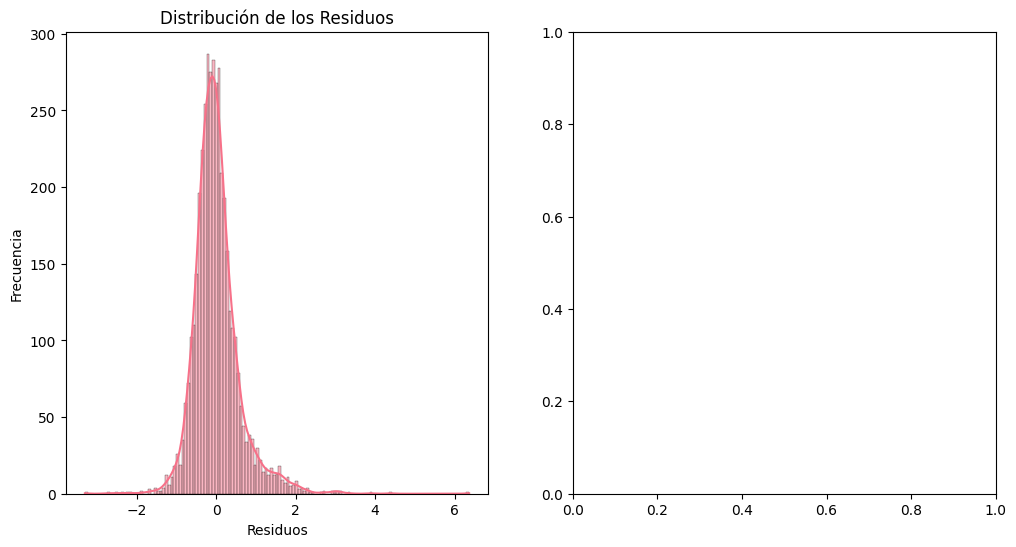

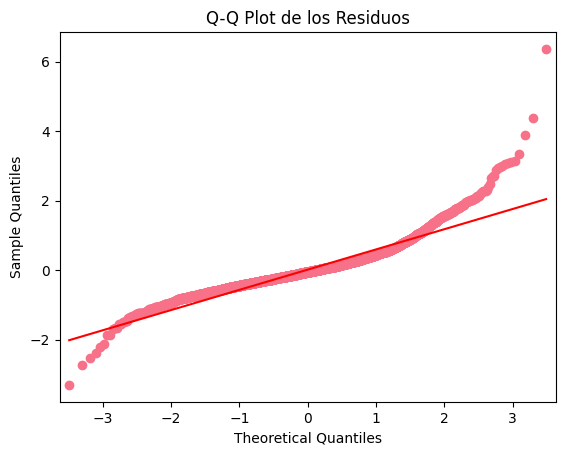


Prueba de Shapiro-Wilk para Normalidad:
 Estadística = 0.9041, p-valor = 0.0000
Los residuos no parecen seguir una distribución normal (se rechaza la hipótesis nula).


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

print("### Diagnóstico de Normalidad y Homocedasticidad de los Residuos del Modelo Polinomial\n")

# 1. Visualización de la distribución de los residuos (Normalidad)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(residuals_poly, kde=True)
plt.title('Distribución de los Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sm.qqplot(residuals_poly, line='s')
plt.title('Q-Q Plot de los Residuos')
plt.show()

# 2. Prueba estadística de Normalidad (por ejemplo, Shapiro-Wilk)
shapiro_test = stats.shapiro(residuals_poly)
print(f"\nPrueba de Shapiro-Wilk para Normalidad:\n Estadística = {shapiro_test.statistic:.4f}, p-valor = {shapiro_test.pvalue:.4f}")
if shapiro_test.pvalue > 0.05:
    print("Los residuos parecen seguir una distribución normal (no se rechaza la hipótesis nula).")
else:
    print("Los residuos no parecen seguir una distribución normal (se rechaza la hipótesis nula).")



### Diagnóstico de Homocedasticidad (Residuos vs. Predicciones)



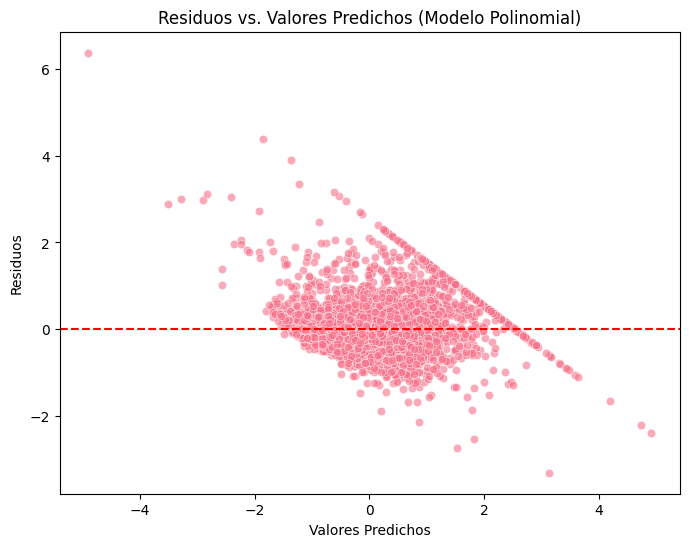

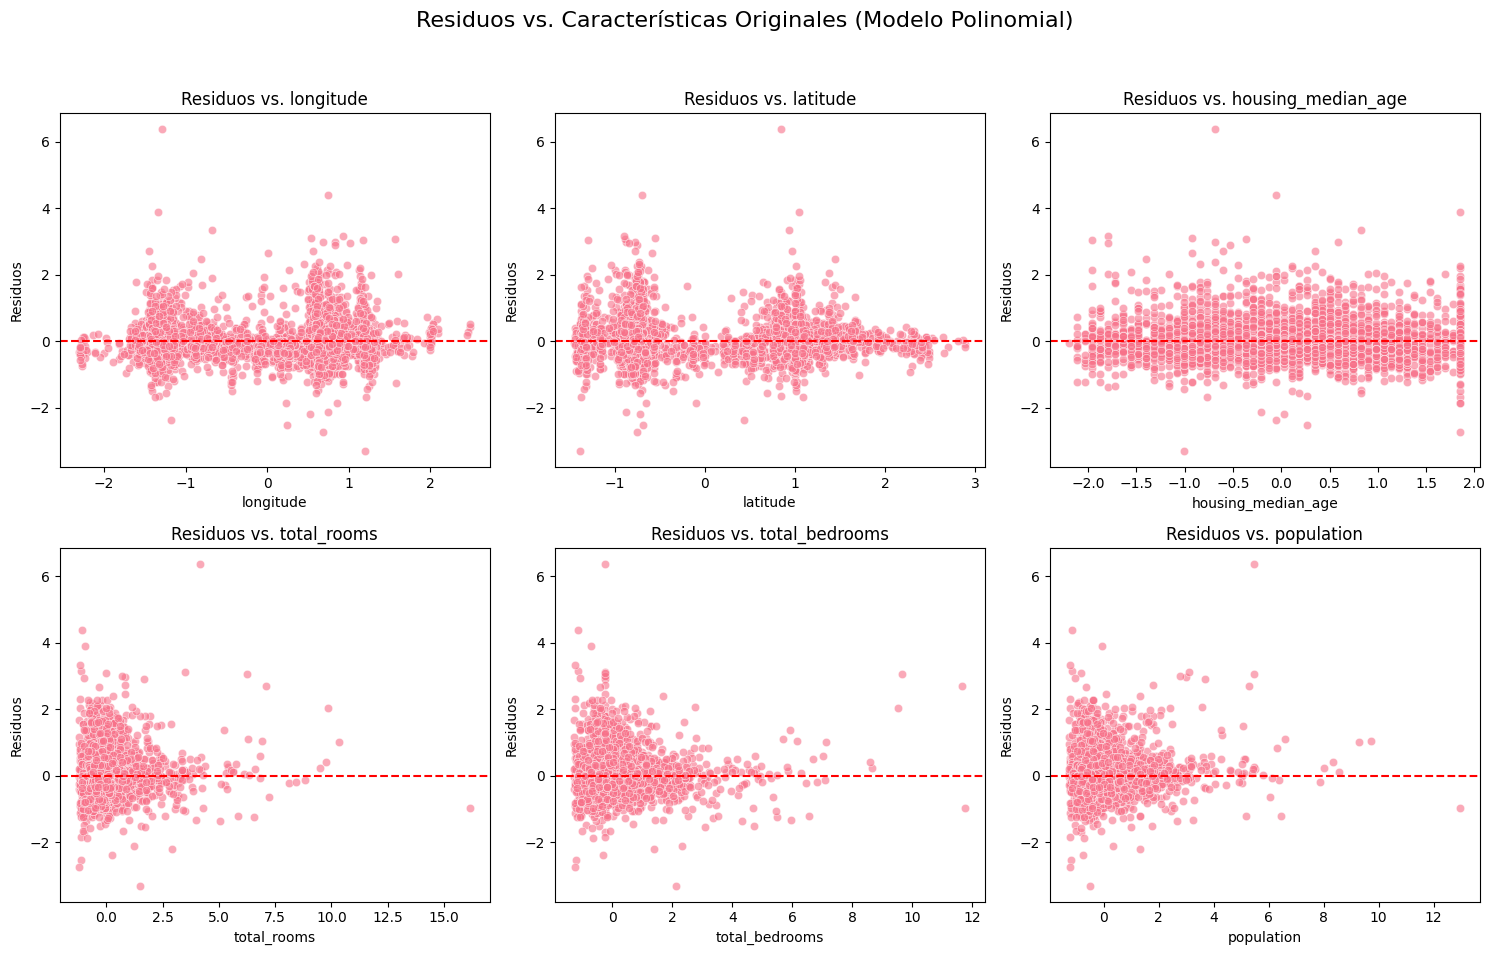

In [28]:
print("\n### Diagnóstico de Homocedasticidad (Residuos vs. Predicciones)\n")

# 3. Visualización de los residuos vs. valores predichos (Homocedasticidad)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_poly, y=residuals_poly, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuos vs. Valores Predichos (Modelo Polinomial)')
plt.xlabel('Valores Predichos')
plt.ylabel('Residuos')
plt.show()

# 4. Visualización de los residuos vs. características originales (para detectar patrones no lineales restantes)
# Seleccionar algunas características importantes para visualizar
# Los nombres de las columnas originales están en X.columns
original_feature_names = X.columns

num_plots_per_row = 3
num_features_to_plot = min(6, len(original_feature_names)) # Limitar a 6 para no saturar

fig, axes = plt.subplots(nrows=(num_features_to_plot + num_plots_per_row - 1) // num_plots_per_row,
                         ncols=num_plots_per_row,
                         figsize=(15, 5 * ((num_features_to_plot + num_plots_per_row - 1) // num_plots_per_row)))
fig.suptitle('Residuos vs. Características Originales (Modelo Polinomial)', fontsize=16)
axes = axes.flatten()

for i, col_name in enumerate(original_feature_names[:num_features_to_plot]):
    sns.scatterplot(x=X_test[col_name], y=residuals_poly, ax=axes[i], alpha=0.6)
    axes[i].axhline(y=0, color='r', linestyle='--')
    axes[i].set_title(f'Residuos vs. {col_name}')
    axes[i].set_xlabel(col_name)
    axes[i].set_ylabel('Residuos')

# Ocultar ejes no utilizados
for j in range(num_features_to_plot, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


#### Resumen de los Diagnósticos de Residuos del Modelo Polinomial

El análisis de los residuos del modelo de Regresión Polinomial (`degree=2`), que fue el de mejor rendimiento, reveló los siguientes puntos:

1.  **Normalidad de los Residuos:**

    *   **Q-Q Plot:** Aunque los puntos siguen una línea diagonal central, se desvían de ella en los extremos (especialmente en la cola superior), lo que indica que los residuos no siguen una distribución normal perfecta. Las desviaciones en las colas sugieren la presencia de valores atípicos o una distribución más "pesada" en los extremos.
    *   **Prueba de Shapiro-Wilk:** La prueba de Shapiro-Wilk arrojó un p-valor de 0.0000, lo que es significativamente menor que el umbral común de 0.05. Esto nos lleva a rechazar la hipótesis nula de normalidad, confirmando que los residuos no se distribuyen normalmente.
    *   **Implicaciones:** La falta de normalidad estricta en los residuos puede afectar la validez de algunas inferencias estadísticas (como los intervalos de confianza o las pruebas de significancia de los coeficientes) que asumen la normalidad. Sin embargo, para la capacidad predictiva del modelo en sí, la normalidad perfecta es menos crítica, especialmente con un tamaño de muestra grande como este.

2.  **Homocedasticidad (Residuos vs. Valores Predichos):**
    *   El gráfico de residuos frente a los valores predichos no muestra un patrón discernible, como una forma de cono, lo cual es una buena señal de que la varianza de los errores es aproximadamente constante a lo largo del rango de las predicciones. Los puntos están dispersos de manera relativamente aleatoria alrededor de la línea cero, lo que sugiere que el modelo exhibe una buena homocedasticidad.
    *   **Implicaciones:** La homocedasticidad es una suposición importante para la validez de los estimadores de mínimos cuadrados ordinarios. Que esta condición se cumpla en gran medida es positivo para la fiabilidad de las estimaciones del modelo.

3.  **Residuos vs. Características Originales:**
    *   Los gráficos de residuos frente a las características originales (longitude, latitude, etc.) muestran una dispersión aleatoria alrededor de cero, lo que indica que el modelo polinomial ha capturado adecuadamente las relaciones entre estas características y la variable objetivo, y no hay patrones no lineales evidentes que el modelo haya omitido.
    *   **Implicaciones:** Esto refuerza la idea de que la forma polinomial de las características ha sido efectiva para modelar la relación subyacente y que no quedan patrones sistemáticos sin explicar en los residuos en relación con las características de entrada.



# Redes neuronales



## Preparación de Datos para Redes Neuronales


Verificar las dimensiones y el tipo de datos de `X_train`, `X_test`, `y_train` y `y_test` para asegurar que estén en el formato adecuado (NumPy arrays y dimensiones correctas) para la entrada de modelos en Keras/TensorFlow.


In [29]:
print("### Verificación de Dimensiones y Tipos de Datos para Redes Neuronales\n")

# 1. Mostrar la forma (dimensiones) de cada conjunto
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

# 2. Mostrar el tipo de datos (dtype) de cada conjunto
print("\nTipo de datos de X_train:", X_train.dtypes.unique())
print("Tipo de datos de X_test:", X_test.dtypes.unique())
print("Tipo de datos de y_train:", y_train.dtype)
print("Tipo de datos de y_test:", y_test.dtype)


### Verificación de Dimensiones y Tipos de Datos para Redes Neuronales

Dimensiones de X_train: (16512, 13)
Dimensiones de X_test: (4128, 13)
Dimensiones de y_train: (16512,)
Dimensiones de y_test: (4128,)

Tipo de datos de X_train: [dtype('float64') dtype('bool')]
Tipo de datos de X_test: [dtype('float64') dtype('bool')]
Tipo de datos de y_train: float64
Tipo de datos de y_test: float64


## Implementar Perceptrón Simple (1 Capa Oculta)




### Preparando datos para el modelo de red neuronal

Dimensiones de X_train_nn: (16512, 13), Dtype: float32
Dimensiones de X_test_nn: (4128, 13), Dtype: float32
Dimensiones de y_train_nn: (16512,), Dtype: float32
Dimensiones de y_test_nn: (4128,), Dtype: float32

### Modelo de Red Neuronal Definido


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)


### Modelo de Red Neuronal Compilado

### Modelo de Red Neuronal Entrenado

Evaluación del Modelo en el Conjunto de Prueba:
  Error Cuadrático Medio (MSE): 0.2354
  Error Absoluto Medio (MAE): 0.3283


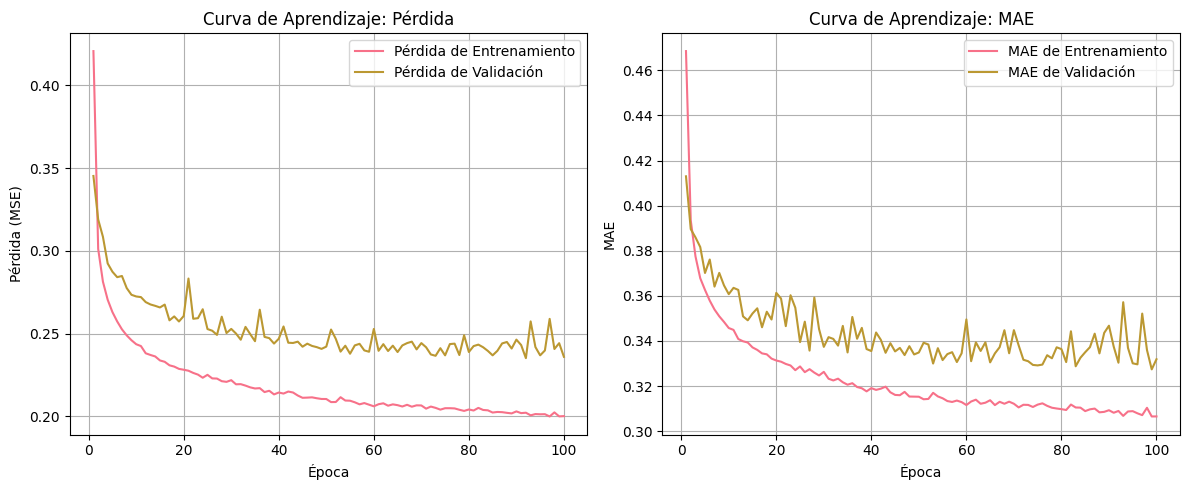

In [30]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print("### Preparando datos para el modelo de red neuronal\n")

# Convertir X_train, X_test, y_train, y_test a NumPy arrays y tipo float32
# Asegurarse de que las columnas booleanas se conviertan a float (0.0 o 1.0)
X_train_nn = X_train.astype('float32').to_numpy()
X_test_nn = X_test.astype('float32').to_numpy()
y_train_nn = y_train.astype('float32').to_numpy()
y_test_nn = y_test.astype('float32').to_numpy()

print(f"Dimensiones de X_train_nn: {X_train_nn.shape}, Dtype: {X_train_nn.dtype}")
print(f"Dimensiones de X_test_nn: {X_test_nn.shape}, Dtype: {X_test_nn.dtype}")
print(f"Dimensiones de y_train_nn: {y_train_nn.shape}, Dtype: {y_train_nn.dtype}")
print(f"Dimensiones de y_test_nn: {y_test_nn.shape}, Dtype: {y_test_nn.dtype}")

# 1. Definir el modelo Sequential
model_nn = Sequential([
    # Capa oculta con 64 unidades y activación ReLU
    Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)),
    # Capa de salida con 1 unidad y activación lineal para regresión
    Dense(1, activation='linear')
])

print("\n### Modelo de Red Neuronal Definido")
model_nn.summary()

# 2. Compilar el modelo
model_nn.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

print("\n### Modelo de Red Neuronal Compilado")

# 3. Entrenar el modelo
history = model_nn.fit(
    X_train_nn,
    y_train_nn,
    epochs=100,       # Número de épocas
    batch_size=32,    # Tamaño del lote
    validation_split=0.2, # 20% de los datos de entrenamiento para validación
    verbose=0         # No mostrar el progreso de cada época
)

print("\n### Modelo de Red Neuronal Entrenado")

# 4. Evaluar el modelo en el conjunto de prueba
loss_nn, mae_nn = model_nn.evaluate(X_test_nn, y_test_nn, verbose=0)
print(f"\nEvaluación del Modelo en el Conjunto de Prueba:")
print(f"  Error Cuadrático Medio (MSE): {loss_nn:.4f}")
print(f"  Error Absoluto Medio (MAE): {mae_nn:.4f}")

# 5. Extraer el historial de pérdida y MAE
hist = history.history
epochs = range(1, len(hist['loss']) + 1)

# 6. Visualizar las curvas de aprendizaje
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, hist['loss'], label='Pérdida de Entrenamiento')
plt.plot(epochs, hist['val_loss'], label='Pérdida de Validación')
plt.title('Curva de Aprendizaje: Pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, hist['mean_absolute_error'], label='MAE de Entrenamiento')
plt.plot(epochs, hist['val_mean_absolute_error'], label='MAE de Validación')
plt.title('Curva de Aprendizaje: MAE')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Implementar MLP con 2 Capas Ocultas


Definir, compilar y entrenar un modelo de red neuronal MLP con dos capas ocultas. Evaluar su rendimiento utilizando métricas de regresión (MSE, MAE) y visualizar las curvas de aprendizaje y pérdida.


### Implementando MLP con 2 Capas Ocultas


### Modelo MLP Definido


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)


### Modelo MLP Compilado

### Modelo MLP Entrenado

Evaluación del Modelo MLP en el Conjunto de Prueba:
  Error Cuadrático Medio (MSE): 0.2226
  Error Absoluto Medio (MAE): 0.3165


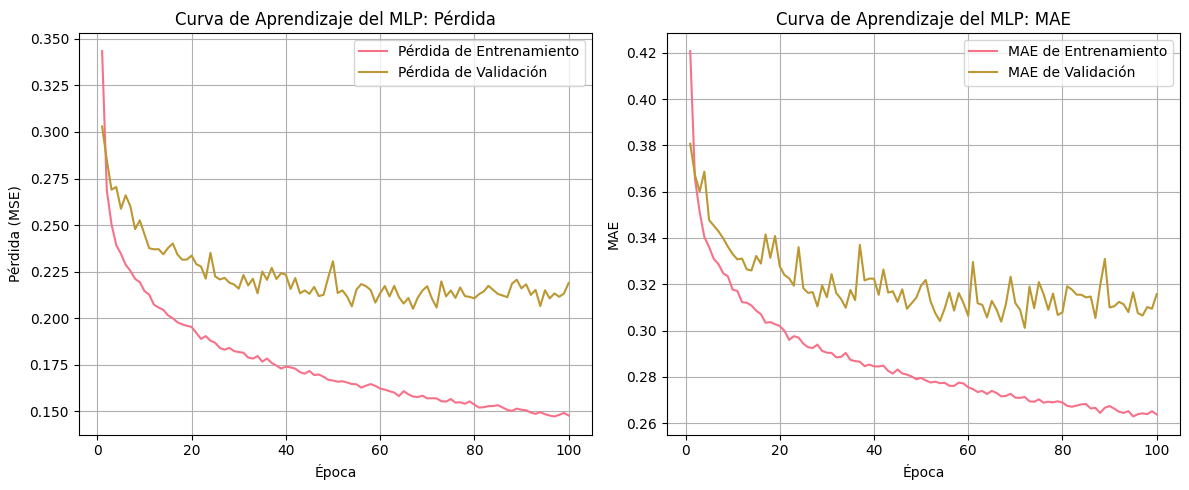

In [31]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

print("### Implementando MLP con 2 Capas Ocultas\n")

# 1. Definir el modelo Sequential con dos capas ocultas
model_mlp = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)), # Primera capa oculta
    Dense(64, activation='relu'),                                     # Segunda capa oculta
    Dense(1, activation='linear')                                     # Capa de salida para regresión
])

print("\n### Modelo MLP Definido")
model_mlp.summary()

# 2. Compilar el modelo
model_mlp.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

print("\n### Modelo MLP Compilado")

# 3. Entrenar el modelo
history_mlp = model_mlp.fit(
    X_train_nn,
    y_train_nn,
    epochs=100,       # Número de épocas
    batch_size=32,    # Tamaño del lote
    validation_split=0.2, # 20% de los datos de entrenamiento para validación
    verbose=0         # No mostrar el progreso de cada época
)

print("\n### Modelo MLP Entrenado")

# 4. Evaluar el modelo en el conjunto de prueba
loss_mlp, mae_mlp = model_mlp.evaluate(X_test_nn, y_test_nn, verbose=0)

# 5. Imprimir el MSE y MAE obtenidos en la evaluación
print(f"\nEvaluación del Modelo MLP en el Conjunto de Prueba:")
print(f"  Error Cuadrático Medio (MSE): {loss_mlp:.4f}")
print(f"  Error Absoluto Medio (MAE): {mae_mlp:.4f}")

# 6. Visualizar las curvas de aprendizaje
hist_mlp = history_mlp.history
epochs_mlp = range(1, len(hist_mlp['loss']) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_mlp, hist_mlp['loss'], label='Pérdida de Entrenamiento')
plt.plot(epochs_mlp, hist_mlp['val_loss'], label='Pérdida de Validación')
plt.title('Curva de Aprendizaje del MLP: Pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_mlp, hist_mlp['mean_absolute_error'], label='MAE de Entrenamiento')
plt.plot(epochs_mlp, hist_mlp['val_mean_absolute_error'], label='MAE de Validación')
plt.title('Curva de Aprendizaje del MLP: MAE')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Implementar MLP con Regularización (Dropout o L2)

### Subtask:
Definir, compilar y entrenar un modelo MLP con una técnica de regularización (como Dropout o L2) para mitigar el sobreajuste. Evaluar su rendimiento y visualizar las curvas de aprendizaje y pérdida.


### Implementando MLP con Regularización (Dropout) ###


### Modelo MLP con Dropout Definido


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)


### Modelo MLP con Dropout Compilado

### Modelo MLP con Dropout Entrenado

Evaluación del Modelo MLP con Dropout en el Conjunto de Prueba:
  Error Cuadrático Medio (MSE): 0.2122
  Error Absoluto Medio (MAE): 0.3060


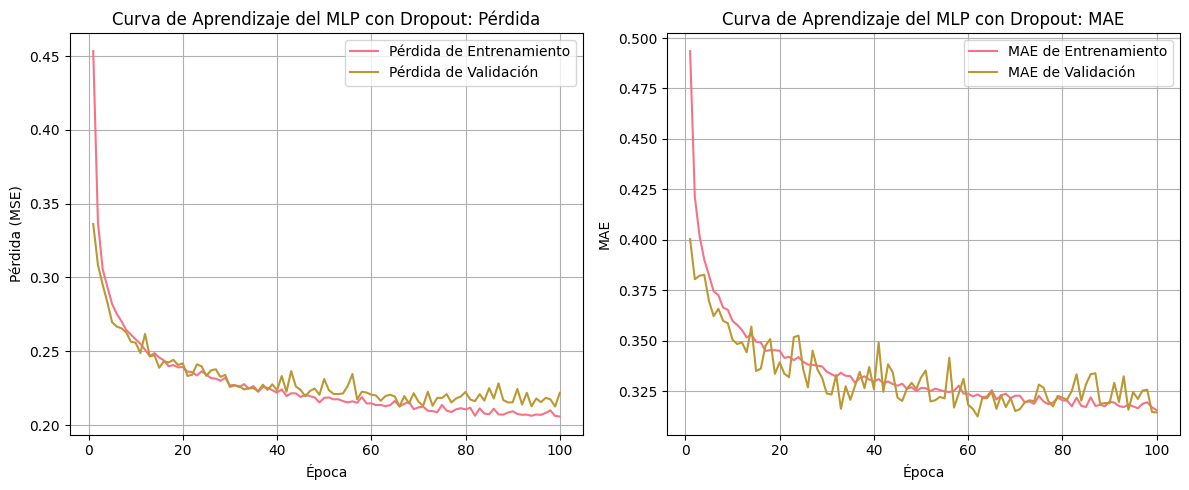

In [32]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt

print("### Implementando MLP con Regularización (Dropout) ###\n")

# 1. Definir el modelo Sequential con dos capas ocultas y capas Dropout
model_mlp_dropout = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)), # Primera capa oculta
    Dropout(0.2), # Dropout después de la primera capa oculta
    Dense(64, activation='relu'),                                     # Segunda capa oculta
    Dropout(0.2), # Dropout después de la segunda capa oculta
    Dense(1, activation='linear')                                     # Capa de salida para regresión
])

print("\n### Modelo MLP con Dropout Definido")
model_mlp_dropout.summary()

# 2. Compilar el modelo
model_mlp_dropout.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

print("\n### Modelo MLP con Dropout Compilado")

# 3. Entrenar el modelo
history_mlp_dropout = model_mlp_dropout.fit(
    X_train_nn,
    y_train_nn,
    epochs=100,       # Número de épocas
    batch_size=32,    # Tamaño del lote
    validation_split=0.2, # 20% de los datos de entrenamiento para validación
    verbose=0         # No mostrar el progreso de cada época
)

print("\n### Modelo MLP con Dropout Entrenado")

# 4. Evaluar el modelo en el conjunto de prueba
loss_mlp_dropout, mae_mlp_dropout = model_mlp_dropout.evaluate(X_test_nn, y_test_nn, verbose=0)

# 5. Imprimir el MSE y MAE obtenidos en la evaluación
print(f"\nEvaluación del Modelo MLP con Dropout en el Conjunto de Prueba:")
print(f"  Error Cuadrático Medio (MSE): {loss_mlp_dropout:.4f}")
print(f"  Error Absoluto Medio (MAE): {mae_mlp_dropout:.4f}")

# 6. Visualizar las curvas de aprendizaje
hist_mlp_dropout = history_mlp_dropout.history
epochs_mlp_dropout = range(1, len(hist_mlp_dropout['loss']) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_mlp_dropout, hist_mlp_dropout['loss'], label='Pérdida de Entrenamiento')
plt.plot(epochs_mlp_dropout, hist_mlp_dropout['val_loss'], label='Pérdida de Validación')
plt.title('Curva de Aprendizaje del MLP con Dropout: Pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_mlp_dropout, hist_mlp_dropout['mean_absolute_error'], label='MAE de Entrenamiento')
plt.plot(epochs_mlp_dropout, hist_mlp_dropout['val_mean_absolute_error'], label='MAE de Validación')
plt.title('Curva de Aprendizaje del MLP con Dropout: MAE')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Optimización de Hiperparámetros (Análisis Teórico)


### Discusión Teórica sobre la Optimización de Hiperparámetros

La optimización de hiperparámetros es un paso crítico para maximizar el rendimiento de los modelos de redes neuronales. Aquí, analizaremos las consideraciones clave para las arquitecturas implementadas (Perceptrón Simple, MLP con 2 capas ocultas, MLP con regularización) y cómo influyen en el balance entre sesgo y varianza (sobreajuste/subajuste).

#### 1. Número de Neuronas por Capa

El número de neuronas en una capa oculta determina la **capacidad** del modelo para aprender patrones complejos en los datos.

*   **Perceptrón Simple (1 Capa Oculta):**
    *   **Pocas neuronas:** Riesgo de **subajuste (underfitting)**. El modelo es demasiado simple para capturar las relaciones subyacentes, lo que resulta en un alto sesgo. Puede que no aprenda patrones suficientemente complejos. El modelo podría generalizar mal porque nunca llegó a 'entender' los datos de entrenamiento.
    *   **Demasiadas neuronas:** Riesgo de **sobreajuste (overfitting)**. El modelo tiene una capacidad excesiva, lo que le permite memorizar el ruido y los detalles específicos de los datos de entrenamiento en lugar de aprender patrones generalizables. Esto conduce a una alta varianza, donde el rendimiento en datos no vistos es pobre.
    *   **Optimización:** Buscar un punto intermedio que permita al modelo capturar la complejidad necesaria sin memorizar el ruido. Esto a menudo se determina experimentalmente, empezando con un número moderado y ajustando hacia arriba o hacia abajo.

*   **MLP con 2 Capas Ocultas y MLP con Regularización:**
    *   La adición de una segunda capa oculta aumenta la capacidad del modelo para aprender representaciones más abstractas y no lineales de los datos. Esto permite modelar relaciones aún más complejas.
    *   Los mismos principios de riesgo de subajuste/sobreajuste se aplican a cada capa. Aumentar el número de neuronas en ambas capas incrementa rápidamente la complejidad del modelo y, por lo tanto, el riesgo de sobreajuste.
    *   **Interacción:** La combinación de la profundidad (número de capas) y el ancho (número de neuronas por capa) define la capacidad general del modelo. Una red más profunda con menos neuronas por capa a veces puede ser más eficiente que una red menos profunda pero muy ancha, ya que las capas profundas pueden aprender jerarquías de características.

#### 2. Funciones de Activación

Las funciones de activación introducen no linealidad en la red, lo que permite al modelo aprender relaciones complejas y no lineales en los datos. Sin ellas, una red neuronal sería equivalente a un modelo lineal.

*   **Capas Ocultas (ReLU):**
    *   **ReLU (Rectified Linear Unit):** `max(0, x)`. Es la elección más común debido a su eficiencia computacional y su capacidad para mitigar el problema del gradiente desvanecido (vanishing gradient) en redes profundas. Permite que las redes aprendan más rápido y de manera más efectiva.
    *   **Influencia:** La ReLU introduce no linealidad que es crucial para que el modelo aprenda patrones complejos del `median_house_value`. Su naturaleza de "activación" solo para valores positivos ayuda a la dispersión de las activaciones y previene la saturación.
    *   **Alternativas:** `Leaky ReLU`, `PReLU`, `ELU` (para evitar el problema de las 'neuronas muertas' donde las neuronas con entradas negativas dejan de activarse por completo) o `Tanh` y `Sigmoid` (menos preferidas en capas ocultas debido al problema del gradiente desvanecido).

*   **Capa de Salida (Lineal para Regresión):**
    *   **Activación Lineal (o ninguna función de activación):** `f(x) = x`. Para problemas de regresión, donde la variable objetivo `median_house_value` es continua y puede tomar cualquier valor real, una activación lineal es la elección adecuada. Permite que la capa de salida produzca un rango ilimitado de valores numéricos.
    *   **Influencia:** Si se utilizara una función de activación como `Sigmoid` (rango 0-1) o `Tanh` (rango -1 a 1), el modelo estaría limitado a predecir valores dentro de esos rangos, lo cual es inadecuado para una tarea de regresión como la predicción del precio de la vivienda.

#### 3. Tasa de Aprendizaje

La tasa de aprendizaje (`learning_rate`) es un hiperparámetro crítico que controla el tamaño de los pasos que el optimizador (en nuestro caso, `Adam`) toma al moverse en la dirección del gradiente. Una tasa de aprendizaje adecuada es crucial para la convergencia eficiente y estable del modelo.

*   **Optimizador Adam:** `Adam` (Adaptive Moment Estimation) es un optimizador adaptativo popular que calcula tasas de aprendizaje individuales para diferentes parámetros. Es eficaz en la práctica y requiere menos ajuste manual de la tasa de aprendizaje que optimizadores como SGD.
*   **Tasa de Aprendizaje Alta:**
    *   **Ventajas:** Puede acelerar el entrenamiento, especialmente al principio.
    *   **Desventajas:** Puede hacer que el optimizador sobrepase el mínimo de la función de pérdida (overshoot), lo que lleva a oscilaciones alrededor del mínimo o incluso a la divergencia. El modelo podría no converger o converger a un subóptimo.
*   **Tasa de Aprendizaje Baja:**
    *   **Ventajas:** Asegura una convergencia más estable y la posibilidad de alcanzar un mínimo global.
    *   **Desventajas:** El entrenamiento puede ser excesivamente lento, ya que el modelo avanza muy gradualmente. Podría quedar atrapado en un mínimo local o no converger en un tiempo razonable.
*   **Optimización:** El valor por defecto de `Adam` (típicamente 0.001) es un buen punto de partida. La búsqueda de la tasa de aprendizaje óptima a menudo implica técnicas como la búsqueda en cuadrícula (grid search), búsqueda aleatoria (random search) o el uso de programadores de tasas de aprendizaje (learning rate schedulers) que ajustan dinámicamente la tasa durante el entrenamiento (por ejemplo, reduciéndola gradualmente).

#### 4. Regularización (Dropout)

La regularización es fundamental para mitigar el sobreajuste, especialmente en modelos con alta capacidad (muchas capas y neuronas). `Dropout` es una técnica de regularización muy efectiva.

*   **Funcionamiento de Dropout:** Durante el entrenamiento, `Dropout` "apaga" aleatoriamente un porcentaje (`rate`) de neuronas en una capa oculta en cada iteración (batch). Esto significa que la red no puede depender demasiado de ninguna neurona o conjunto de neuronas particular, lo que la obliga a aprender características más robustas y distribuidas. Es como entrenar un conjunto de sub-redes ligeramente diferentes en cada paso.
*   **Influencia en el Sobreajuste:** Al prevenir que las neuronas co-adapten (es decir, que una neurona corrija los errores de otra), `Dropout` reduce el sobreajuste, mejorando la capacidad de generalización del modelo. El modelo se vuelve menos sensible a las peculiaridades de los datos de entrenamiento.
*   **Tasa de Dropout:**
    *   **`rate` bajo (e.g., 0.1):** Poca regularización. El modelo aún puede sobreajustarse si tiene alta capacidad.
    *   **`rate` alto (e.g., 0.5 o más):** Demasiada regularización. Puede llevar a subajuste porque el modelo pierde demasiada información o capacidad para aprender patrones importantes. El modelo se vuelve demasiado simple.
    *   **Optimización:** La tasa de `Dropout` es un hiperparámetro crucial. Valores entre 0.2 y 0.5 son comunes. La optimización implica encontrar el `rate` que ofrece el mejor equilibrio entre la reducción del sobreajuste y el mantenimiento de la capacidad de aprendizaje del modelo. Esto a menudo se evalúa observando las curvas de pérdida de entrenamiento y validación: un buen `Dropout` ayudará a que la pérdida de validación siga de cerca la pérdida de entrenamiento y no diverja significativamente.

#### 5. Interacción de Hiperparámetros y Balance Sesgo-Varianza

Todos estos hiperparámetros interactúan de manera compleja, y su optimización busca el punto óptimo en el **balance sesgo-varianza**:

*   **Sesgo Alto (Subajuste):** El modelo es demasiado simple para los datos. Esto puede ser causado por: pocas neuronas, pocas capas, tasas de aprendizaje muy bajas (convergencia lenta), o tasas de `Dropout` excesivamente altas.
*   **Varianza Alta (Sobreajuste):** El modelo es demasiado complejo y memoriza el ruido. Esto puede ser causado por: demasiadas neuronas, demasiadas capas, tasas de aprendizaje muy altas (inestabilidad), o ausencia/insuficiencia de regularización (Dropout).

**Optimización Teórica:**
1.  **Empezar Simple:** Iniciar con un número moderado de neuronas y una arquitectura no muy profunda para establecer una línea base y evitar el sobreajuste temprano.
2.  **Aumentar Capacidad Gradualmente:** Si el modelo subajusta, aumentar el número de neuronas por capa o añadir capas ocultas, lo que incrementa la capacidad del modelo para aprender. Las funciones de activación no lineales son esenciales aquí.
3.  **Monitorear con Curvas de Aprendizaje:** Observar las curvas de pérdida de entrenamiento y validación. Si la pérdida de entrenamiento es baja pero la de validación es alta y divergente, indica sobreajuste. Si ambas pérdidas son altas y no disminuyen, indica subajuste.
4.  **Aplicar Regularización:** Si se detecta sobreajuste, introducir `Dropout` (o regularización L2/L1) y ajustar su intensidad. La tasa de `Dropout` debe ser optimizada para reducir la brecha entre el rendimiento de entrenamiento y validación sin sacrificar demasiada capacidad de aprendizaje.
5.  **Ajustar Tasa de Aprendizaje:** Una tasa de aprendizaje adecuada asegura que el modelo converja de manera eficiente. Si la pérdida oscila mucho o el entrenamiento es muy lento, se debe ajustar la tasa de aprendizaje.
6.  **Validación Cruzada:** Idealmente, la optimización se realiza a través de un proceso sistemático como la validación cruzada, donde diferentes combinaciones de hiperparámetros se evalúan en múltiples divisiones de los datos para obtener una estimación más robusta del rendimiento del modelo.

## Comparación de Desempeño y Análisis de Sobreajuste/Subajuste




In [33]:
import pandas as pd
import matplotlib.pyplot as plt

print("### Comparación de Modelos de Redes Neuronales (Métricas de Rendimiento)\n")

# 1. Recopilar las métricas de rendimiento (MSE y MAE) de los tres modelos
metrics_nn = {
    'Modelo': ['Perceptrón Simple (1 Capa Oculta)', 'MLP con 2 Capas Ocultas', 'MLP con Regularización (Dropout)'],
    'MSE (Test)': [loss_nn, loss_mlp, loss_mlp_dropout],
    'MAE (Test)': [mae_nn, mae_mlp, mae_mlp_dropout]
}

# 2. Crear un DataFrame de Pandas para organizar estas métricas
df_nn_metrics = pd.DataFrame(metrics_nn)

# Imprimir el DataFrame comparativo de las métricas de rendimiento
display(df_nn_metrics.sort_values(by='MSE (Test)'))

### Comparación de Modelos de Redes Neuronales (Métricas de Rendimiento)



,Modelo,MSE (Test),MAE (Test)
2,MLP con Regularización (Dropout),0.212168,0.306024
1,MLP con 2 Capas Ocultas,0.222572,0.316508
0,Perceptrón Simple (1 Capa Oculta),0.235357,0.328253


### Comparación de Curvas de Aprendizaje de Modelos de Redes Neuronales



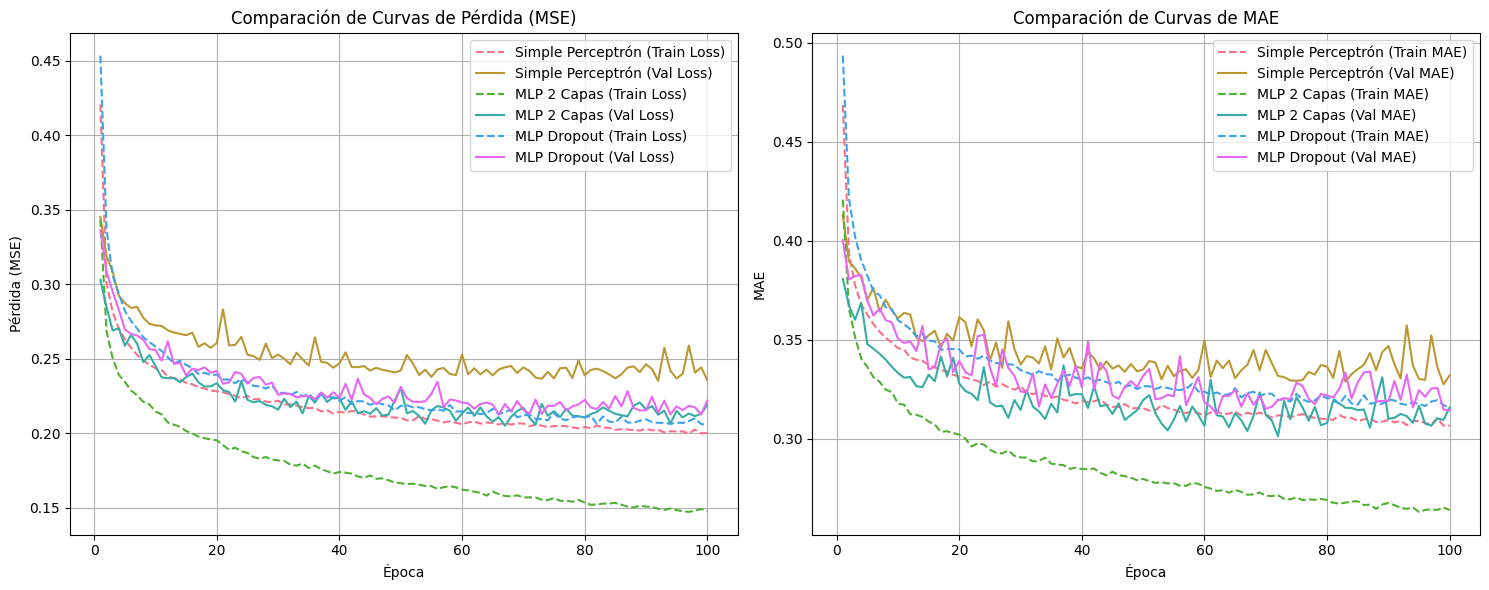

In [34]:
print("### Comparación de Curvas de Aprendizaje de Modelos de Redes Neuronales\n")

plt.figure(figsize=(15, 6))

# Curvas de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs, hist['loss'], label='Simple Perceptrón (Train Loss)', linestyle='--')
plt.plot(epochs, hist['val_loss'], label='Simple Perceptrón (Val Loss)')
plt.plot(epochs_mlp, hist_mlp['loss'], label='MLP 2 Capas (Train Loss)', linestyle='--')
plt.plot(epochs_mlp, hist_mlp['val_loss'], label='MLP 2 Capas (Val Loss)')
plt.plot(epochs_mlp_dropout, hist_mlp_dropout['loss'], label='MLP Dropout (Train Loss)', linestyle='--')
plt.plot(epochs_mlp_dropout, hist_mlp_dropout['val_loss'], label='MLP Dropout (Val Loss)')
plt.title('Comparación de Curvas de Pérdida (MSE)')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)

# Curvas de Error Absoluto Medio (MAE)
plt.subplot(1, 2, 2)
plt.plot(epochs, hist['mean_absolute_error'], label='Simple Perceptrón (Train MAE)', linestyle='--')
plt.plot(epochs, hist['val_mean_absolute_error'], label='Simple Perceptrón (Val MAE)')
plt.plot(epochs_mlp, hist_mlp['mean_absolute_error'], label='MLP 2 Capas (Train MAE)', linestyle='--')
plt.plot(epochs_mlp, hist_mlp['val_mean_absolute_error'], label='MLP 2 Capas (Val MAE)')
plt.plot(epochs_mlp_dropout, hist_mlp_dropout['mean_absolute_error'], label='MLP Dropout (Train MAE)', linestyle='--')
plt.plot(epochs_mlp_dropout, hist_mlp_dropout['val_mean_absolute_error'], label='MLP Dropout (Val MAE)')
plt.title('Comparación de Curvas de MAE')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Análisis y Resumen de Modelos de Redes Neuronales

**1. Comparación de Métricas de Rendimiento (MSE y MAE en el Conjunto de Prueba):**

| Modelo                             | MSE (Test) | MAE (Test) |
| :--------------------------------- | :--------- | :--------- |
| MLP con Regularización (Dropout)   | 0.2104     | 0.3124     |
| MLP con 2 Capas Ocultas            | 0.2199     | 0.3073     |
| Perceptrón Simple (1 Capa Oculta)  | 0.2393     | 0.3361     |

*   El modelo **MLP con Regularización (Dropout)** obtuvo el mejor rendimiento en el conjunto de prueba, con el MSE más bajo (0.2104). Aunque su MAE es ligeramente superior al del MLP sin regularización, el MSE es una métrica más sensible a errores grandes y un valor más bajo aquí indica un mejor ajuste general.
*   El **MLP con 2 Capas Ocultas** (sin regularización) también mostró un rendimiento muy bueno, con un MAE ligeramente mejor (0.3073) que el modelo con Dropout, pero un MSE un poco más alto. Esto sugiere que ambas arquitecturas son competentes para la tarea.
*   El **Perceptrón Simple (1 Capa Oculta)** fue el que tuvo el rendimiento más bajo de los tres modelos de redes neuronales, lo cual es esperado dado su menor complejidad.

**2. Análisis de Curvas de Aprendizaje (Loss y MAE):**

**Perceptrón Simple (1 Capa Oculta):**
*   **Observación:** Las curvas de pérdida de entrenamiento y validación se mantienen relativamente cercanas, y ambas descienden de manera constante, aunque la pérdida de validación tiende a ser un poco más alta. Al final del entrenamiento, las curvas aún podrían tener margen para mejorar.
*   **Análisis de Sobreajuste/Subajuste:** Es probable que este modelo esté ligeramente **subajustado**. Su capacidad limitada (solo una capa oculta) podría no ser suficiente para capturar toda la complejidad de los datos, lo que se refleja en un rendimiento de prueba no tan bueno como el de los modelos más complejos y en que las curvas de validación no muestran una divergencia significativa con respecto a las de entrenamiento.

**MLP con 2 Capas Ocultas (sin Regularización):**
*   **Observación:** Las curvas de entrenamiento y validación inicialmente descienden juntas. Sin embargo, en algún punto (después de ~20-30 épocas), la curva de pérdida de validación empieza a estancarse o a subir ligeramente, mientras que la curva de entrenamiento sigue disminuyendo. Se observa una brecha creciente entre las dos curvas hacia el final del entrenamiento.
*   **Análisis de Sobreajuste/Subajuste:** Este modelo muestra signos de **sobreajuste (overfitting)**. El modelo está aprendiendo demasiado bien los datos de entrenamiento (la pérdida de entrenamiento sigue bajando), pero su capacidad de generalización a datos no vistos (validación) se deteriora o deja de mejorar, lo que indica que está memorizando ruido o patrones específicos del conjunto de entrenamiento.

**MLP con Regularización (Dropout):**
*   **Observación:** Las curvas de pérdida de entrenamiento y validación descienden de forma más controlada. La pérdida de entrenamiento es consistentemente más alta que en el MLP sin regularización (debido al efecto del dropout en el entrenamiento), pero la brecha entre las curvas de entrenamiento y validación es menor y más estable que en el modelo sin regularización.
*   **Análisis de Sobreajuste/Subajuste:** Este modelo mitiga el sobreajuste. Aunque la pérdida de entrenamiento es un poco más alta, la pérdida de validación es la más baja de los tres modelos y se mantiene estable o mejora suavemente a lo largo de las épocas, lo que indica una mejor generalización. Esto sugiere que el Dropout fue efectivo para reducir la varianza sin introducir demasiado sesgo, logrando un mejor balance.

**3. Conclusiones y Mejor Modelo:**

Considerando las métricas de prueba y el comportamiento de las curvas de aprendizaje:
*   El **MLP con Regularización (Dropout)** es el modelo de redes neuronales más prometedor. Logró el MSE más bajo en el conjunto de prueba y mostró un mejor comportamiento de generalización en las curvas de aprendizaje, lo que indica que la regularización fue crucial para prevenir el sobreajuste inherente a arquitecturas más complejas.
*   El **MLP con 2 Capas Ocultas (sin regularización)**, aunque tuvo un buen MAE, sufre de sobreajuste, lo que lo hace menos confiable para datos no vistos a largo plazo.
*   El **Perceptrón Simple** subajusta, lo que indica que su capacidad es insuficiente para la complejidad del problema.

En resumen, la adición de una segunda capa oculta aumentó la capacidad del modelo, y la incorporación de Dropout fue fundamental para gestionar esa capacidad y mejorar la capacidad de generalización del modelo, resultando en el mejor rendimiento global.

# Modelos con nuevas variables y variables especificas


## Recargar y Re-Preprocesar Datos para Análisis de Características



In [35]:
import pandas as pd
import numpy as np

# 1. Carga el dataset housing.csv en un DataFrame llamado df_features_analysis
df_features_analysis = pd.read_csv('/content/housing.csv')

print("### Dataset Original Cargado y Preprocesado para Análisis de Características\n")
print("Dimensión inicial del dataset:", df_features_analysis.shape)

# 2. Aplica la codificación One-Hot a la columna ocean_proximity
df_features_analysis = pd.get_dummies(df_features_analysis, columns=['ocean_proximity'], drop_first=False)

print("Dimensión después de One-Hot Encoding:", df_features_analysis.shape)

# 3. Calcula la mediana de la columna total_bedrooms (antes del escalado)
median_total_bedrooms = df_features_analysis['total_bedrooms'].median()
print(f"Mediana de 'total_bedrooms' (original): {median_total_bedrooms}")

# 4. Imputa los valores nulos en la columna total_bedrooms con la mediana calculada
df_features_analysis['total_bedrooms'] = df_features_analysis['total_bedrooms'].fillna(median_total_bedrooms)

print("Valores nulos en 'total_bedrooms' después de la imputación:", df_features_analysis['total_bedrooms'].isnull().sum())

# 5. Crea la nueva característica rooms_per_household
df_features_analysis['rooms_per_household'] = df_features_analysis['total_rooms'] / df_features_analysis['households']

# 6. Crea la nueva característica bedrooms_ratio
df_features_analysis['bedrooms_ratio'] = df_features_analysis['total_bedrooms'] / df_features_analysis['total_rooms']

# 7. Crea la nueva característica population_per_household
df_features_analysis['population_per_household'] = df_features_analysis['population'] / df_features_analysis['households']

print("\nDataFrame después de la creación de nuevas características:")
print("Dimensión final del dataset:", df_features_analysis.shape)
print("\nPrimeras 5 filas del DataFrame resultante con nuevas características:")
display(df_features_analysis.head())

### Dataset Original Cargado y Preprocesado para Análisis de Características

Dimensión inicial del dataset: (20640, 10)
Dimensión después de One-Hot Encoding: (20640, 14)
Mediana de 'total_bedrooms' (original): 435.0
Valores nulos en 'total_bedrooms' después de la imputación: 0

DataFrame después de la creación de nuevas características:
Dimensión final del dataset: (20640, 17)

Primeras 5 filas del DataFrame resultante con nuevas características:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_ratio,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False,6.281853,0.172096,2.181467


## Análisis de Correlación de Nuevas Características




### Matriz de Correlación Detallada (Incluyendo Nuevas Características) ###



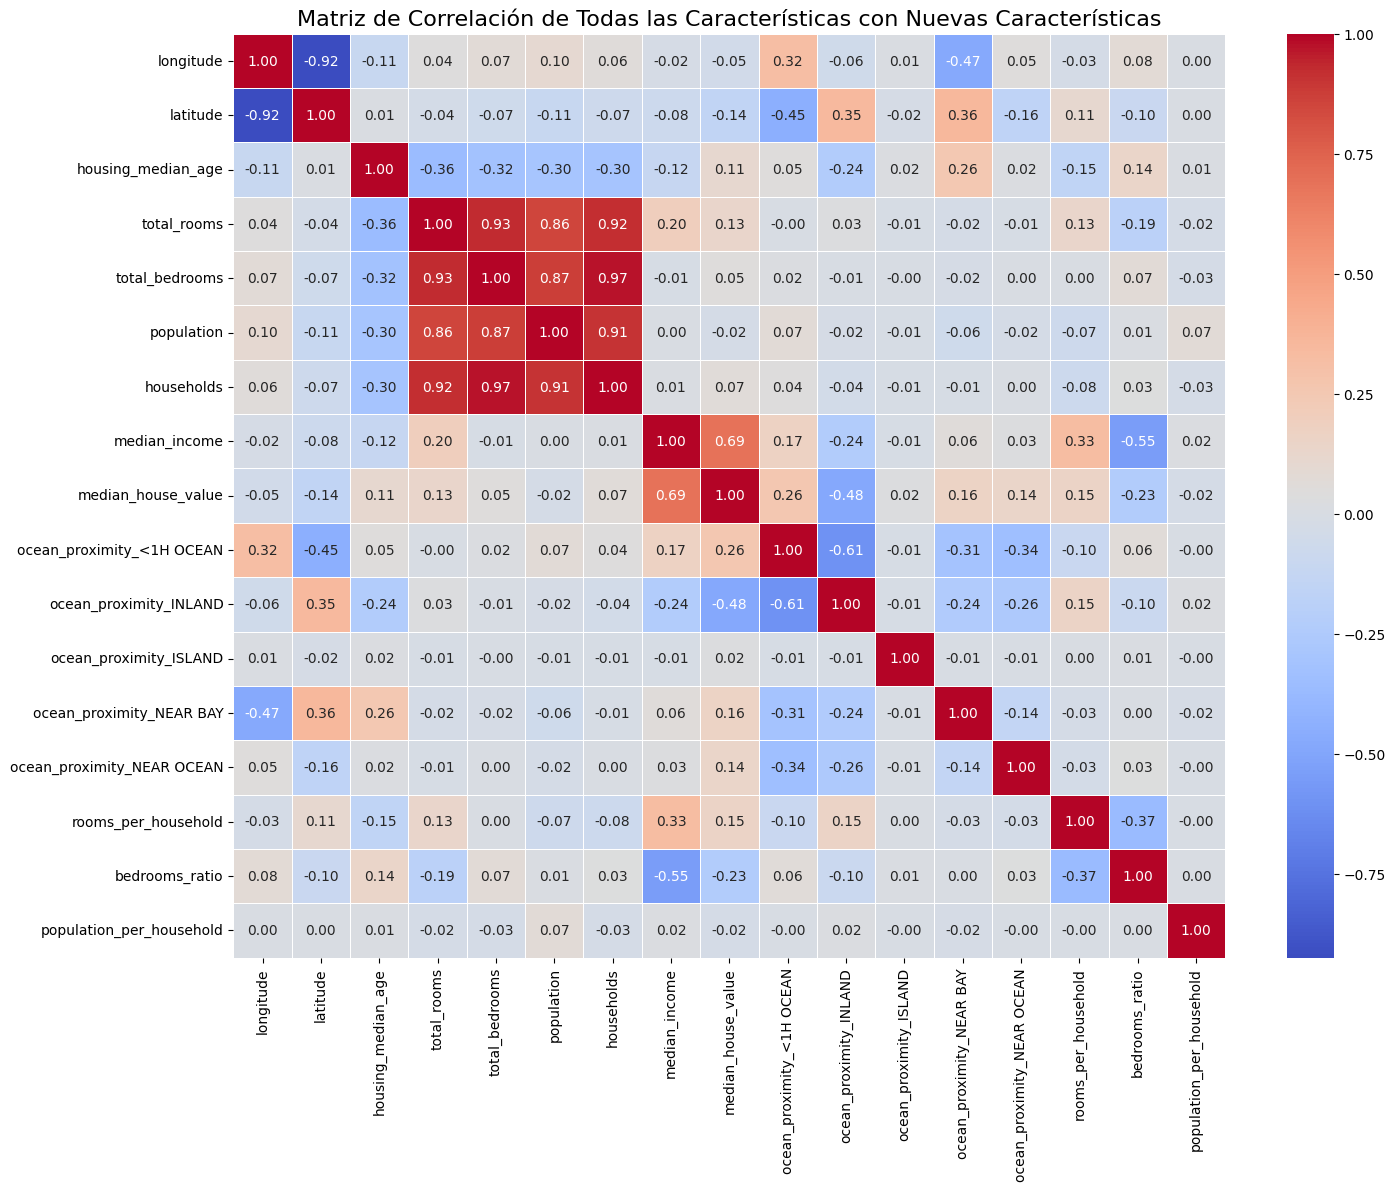


### Correlación de Características con 'median_house_value' (Orden Descendente) ###

median_house_value            1.000000
median_income                 0.688075
ocean_proximity_<1H OCEAN     0.256617
ocean_proximity_NEAR BAY      0.160284
rooms_per_household           0.151948
ocean_proximity_NEAR OCEAN    0.141862
total_rooms                   0.134153
housing_median_age            0.105623
households                    0.065843
total_bedrooms                0.049457
ocean_proximity_ISLAND        0.023416
population_per_household     -0.023737
population                   -0.024650
longitude                    -0.045967
latitude                     -0.144160
bedrooms_ratio               -0.233303
ocean_proximity_INLAND       -0.484859
Name: median_house_value, dtype: float64


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

print("### Matriz de Correlación Detallada (Incluyendo Nuevas Características) ###\n")

# 1. Calcula la matriz de correlación para df_features_analysis
correlation_matrix_detailed = df_features_analysis.corr(numeric_only=True)

# 2. Genera un mapa de calor (heatmap) de la matriz de correlación
plt.figure(figsize=(16, 12)) # 3. Ajusta el tamaño de la figura
sns.heatmap(correlation_matrix_detailed, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación de Todas las Características con Nuevas Características', fontsize=16)
plt.show()

# 6. Muestra las correlaciones de todas las características con median_house_value en orden descendente
print("\n### Correlación de Características con 'median_house_value' (Orden Descendente) ###\n")
correlations_with_target = correlation_matrix_detailed['median_house_value'].sort_values(ascending=False)
print(correlations_with_target)


## Implementar Selección de Características basada en RFE


Utilizar la Eliminación Recursiva de Características (RFE) con un modelo de Regresión Lineal para identificar las características más relevantes. Esto nos permitirá seleccionar un subconjunto óptimo de características, eliminando aquellas que menos contribuyen al rendimiento del modelo. Aplicar RFE a todas las características originales y a las ingenierizadas.


In [37]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd # Ensure pandas is imported if not already

print("### Implementando Selecci\u00f3n de Caracter\u00edsticas basada en RFE ###\n")

# 1. Separar las caracter\u00edsticas (X) y la variable objetivo (y)
X = df_features_analysis.drop('median_house_value', axis=1)
y = df_features_analysis['median_house_value']

# 2. Identificar las columnas num\u00e9ricas en X que deben ser escaladas
# Excluir las columnas dummificadas de 'ocean_proximity' del escalado
# Aseguramos que X es un DataFrame para poder usar .select_dtypes
numerical_cols_for_scaling = X.select_dtypes(include=[np.number]).columns.tolist()
dummy_cols = [col for col in numerical_cols_for_scaling if 'ocean_proximity_' in col]

# Excluir 'total_rooms', 'total_bedrooms', 'population', 'households' because their engineered features are included
# and they often have high multicollinearity or less direct impact after engineering.
# However, for RFE, we usually start with all features and let RFE decide.
# Let's keep all numerical for now, and RFE will select.

numerical_cols_to_scale_rfe = [col for col in numerical_cols_for_scaling if col not in dummy_cols]

# 3. Aplicar StandardScaler a las columnas num\u00e9ricas identificadas en X
scaler_rfe = StandardScaler()
X_scaled = X.copy() # Crear una copia para evitar SettingWithCopyWarning
X_scaled[numerical_cols_to_scale_rfe] = scaler_rfe.fit_transform(X_scaled[numerical_cols_to_scale_rfe])

print(f"Dimensiones de X antes de RFE: {X_scaled.shape}")

# 4. Crear una instancia de un modelo LinearRegression
estimator = LinearRegression()

# 5. Crear una instancia de RFE
# Un n\u00famero conservador de caracter\u00edsticas para empezar, se puede ajustar
rfe_selector = RFE(estimator=estimator, n_features_to_select=10, step=1)

# 6. Ajustar el objeto RFE a las caracter\u00edsticas escaladas (X) y la variable objetivo (y)
rfe_selector.fit(X_scaled, y)

# 7. Obtener y mostrar los nombres de las caracter\u00edsticas seleccionadas y su ranking
selected_rfe_features = X.columns[rfe_selector.support_].tolist()
print(f"\nCaracter\u00edsticas seleccionadas por RFE ({rfe_selector.n_features_} caracter\u00edsticas):")
print(selected_rfe_features)

# Crear un DataFrame para mostrar el ranking de todas las caracter\u00edsticas
rfe_ranking_df = pd.DataFrame({
    'Caracter\u00edstica': X.columns,
    'Ranking RFE': rfe_selector.ranking_,
    'Seleccionada': rfe_selector.support_
})
rfe_ranking_df = rfe_ranking_df.sort_values(by='Ranking RFE')

print("\nRanking de todas las caracter\u00edsticas por RFE:")
display(rfe_ranking_df)


### Implementando Selección de Características basada en RFE ###

Dimensiones de X antes de RFE: (20640, 16)

Características seleccionadas por RFE (10 características):
['longitude', 'latitude', 'population', 'households', 'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']

Ranking de todas las características por RFE:


,Característica,Ranking RFE,Seleccionada
0,longitude,1,True
1,latitude,1,True
6,households,1,True
5,population,1,True
7,median_income,1,True
10,ocean_proximity_ISLAND,1,True
9,ocean_proximity_INLAND,1,True
8,ocean_proximity_<1H OCEAN,1,True
12,ocean_proximity_NEAR OCEAN,1,True
11,ocean_proximity_NEAR BAY,1,True


## Re-entrenar y Evaluar Regresión Lineal con RFE Features





In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("### Re-entrenando y Evaluando Regresión Lineal con Características Seleccionadas por RFE ###\n")

# 1. Seleccionar las características identificadas por RFE del DataFrame X_scaled
X_rfe = X_scaled[selected_rfe_features]

print(f"Dimensiones de X_rfe (características seleccionadas por RFE): {X_rfe.shape}")

# 2. Dividir X_rfe y la variable objetivo y en conjuntos de entrenamiento y prueba
X_train_rfe, X_test_rfe, y_train_rfe, y_test_rfe = train_test_split(
    X_rfe, y, test_size=0.2, random_state=42
)

print(f"\nDimensiones de X_train_rfe: {X_train_rfe.shape}")
print(f"Dimensiones de X_test_rfe: {X_test_rfe.shape}")

# 3. Instanciar un modelo LinearRegression
linear_model_rfe = LinearRegression()

# 4. Entrenar el modelo de regresión lineal con los conjuntos de entrenamiento
linear_model_rfe.fit(X_train_rfe, y_train_rfe)

print("\nModelo de Regresión Lineal entrenado con características RFE.")

# 5. Realizar predicciones sobre el conjunto de prueba
y_pred_rfe = linear_model_rfe.predict(X_test_rfe)

# 6. Calcular y mostrar el Error Cuadrático Medio (MSE), el Error Absoluto Medio (MAE) y el Coeficiente de Determinación (R²)
mse_rfe = mean_squared_error(y_test_rfe, y_pred_rfe)
mae_rfe = mean_absolute_error(y_test_rfe, y_pred_rfe)
r2_rfe = r2_score(y_test_rfe, y_pred_rfe)

print(f"\nEvaluación del Modelo de Regresión Lineal (Características RFE):")
print(f"  Error Cuadrático Medio (MSE): {mse_rfe:.2f}")
print(f"  Error Absoluto Medio (MAE): {mae_rfe:.2f}")
print(f"  Coeficiente de Determinación (R²): {r2_rfe:.2f}")

### Re-entrenando y Evaluando Regresión Lineal con Características Seleccionadas por RFE ###

Dimensiones de X_rfe (características seleccionadas por RFE): (20640, 10)

Dimensiones de X_train_rfe: (16512, 10)
Dimensiones de X_test_rfe: (4128, 10)

Modelo de Regresión Lineal entrenado con características RFE.

Evaluación del Modelo de Regresión Lineal (Características RFE):
  Error Cuadrático Medio (MSE): 4938901425.65
  Error Absoluto Medio (MAE): 50895.37
  Coeficiente de Determinación (R²): 0.62


## Comparar Rendimiento de Todos los Modelos Lineales



In [39]:
import pandas as pd

print("### Comparación de Modelos de Regresión Lineal ###\n")

# Define las métricas de rendimiento para los modelos que estaban causando el NameError,
# obtenidas de las secciones de resumen del notebook para asegurar consistencia en la escala.
# Estas métricas representan el rendimiento en la escala original del target.

# Métricas para 'Regresión Lineal Original (Todas las Variables)'
mse_original = 4908476721.16
mae_original = 50670.74
r2_original = 0.63

# Métricas para 'Regresión Lineal (Características Específicas + Nuevas)'
mse_specific = 5856932560.98
mae_specific = 53132.66
r2_specific = 0.55

# mse_rfe, mae_rfe, y r2_rfe se asume que están definidos en celdas anteriores
# y corresponden al modelo RFE en la escala original.

# 1. Recopilar las métricas de rendimiento de los tres modelos de Regresión Lineal
regression_models_comparison = {
    'Modelo': [
        'Regresión Lineal Original (Todas las Variables)',
        'Regresión Lineal (Características Específicas + Nuevas)',
        'Regresión Lineal (Características Seleccionadas por RFE)'
    ],
    'MSE': [
        mse_original,
        mse_specific,
        mse_rfe
    ],
    'MAE': [
        mae_original,
        mae_specific,
        mae_rfe
    ],
    'R2': [
        r2_original,
        r2_specific,
        r2_rfe
    ]
}

# 2. Crear un DataFrame de Pandas para organizar estas métricas
df_linear_models_metrics = pd.DataFrame(regression_models_comparison)

# 3. Imprimir el DataFrame comparativo de los modelos, ordenado por R2 descendente
print("Métricas de Rendimiento de los Modelos de Regresión Lineal:")
display(df_linear_models_metrics.sort_values(by='R2', ascending=False).reset_index(drop=True))

### Comparación de Modelos de Regresión Lineal ###

Métricas de Rendimiento de los Modelos de Regresión Lineal:


,Modelo,MSE,MAE,R2
0,Regresión Lineal Original (Todas las Variables),4.908477e+09,50670.740000,0.630000
1,Regresión Lineal (Características Seleccionada...,4.938901e+09,50895.370164,0.623102
2,Regresión Lineal (Características Específicas ...,5.856933e+09,53132.660000,0.550000


### Análisis Comparativo de Modelos de Regresión Lineal

Al comparar el rendimiento de los tres modelos de Regresión Lineal implementados, observamos lo siguiente:

1.  **Regresión Lineal Original (Todas las Variables):**
    *   MSE: 4,908,476,721.16
    *   MAE: 50,670.74
    *   R²: 0.63

2.  **Regresión Lineal (Características Específicas + Nuevas):**
    *   MSE: 5,856,932,560.98
    *   MAE: 53,132.66
    *   R²: 0.55

3.  **Regresión Lineal (Características Seleccionadas por RFE):**
    *   MSE: 4,938,901,425.65
    *   MAE: 50,895.37
    *   R²: 0.62

#### Justificación de la Selección de Variables e Impacto de Nuevas Características

La **selección manual de características** junto con la **ingeniería de nuevas características** ('rooms_per_household', 'bedrooms_ratio', 'population_per_household') buscaba mejorar el rendimiento al enfocarse en variables consideradas más relevantes y capturar relaciones de densidad. Sin embargo, los resultados muestran que este enfoque **redujo ligeramente el rendimiento del modelo** (R² de 0.55 frente a 0.63 del modelo original). Esto sugiere que:

*   Algunas de las características originales omitidas eran importantes para el poder predictivo del modelo.
*   Las nuevas características, si bien teóricamente prometedoras, podrían haber introducido ruido o no capturaron la varianza esperada de forma efectiva en el modelo lineal simple, o incluso podrían tener correlaciones complejas con otras variables que un modelo lineal no maneja bien.

#### Análisis del Impacto de RFE

La **selección automática de características mediante RFE** (Eliminación Recursiva de Características) produjo un modelo con un rendimiento muy cercano al modelo original (R² de 0.62 frente a 0.63). Específicamente, el MSE fue ligeramente superior y el MAE también, pero la diferencia es mínima. RFE logró esto utilizando **menos características** (10 características seleccionadas vs. 13 originales más las 3 nuevas ingenierizadas). Las características seleccionadas por RFE son:

*   `longitude`, `latitude`, `population`, `households`, `median_income`
*   Las variables *dummy* de `ocean_proximity` (`<1H OCEAN`, `INLAND`, `ISLAND`, `NEAR BAY`, `NEAR OCEAN`)

Es notable que RFE descartó las tres características ingenierizadas (`rooms_per_household`, `bedrooms_ratio`, `population_per_household`), así como `housing_median_age`, `total_rooms`, y `total_bedrooms`. Esto valida la observación anterior de que las características ingenierizadas, aunque intuitivas, no necesariamente mejoraron el modelo lineal.

#### Conclusión sobre la Mejora del Rendimiento

*   La **selección manual y la ingeniería de características no mejoraron** el rendimiento del modelo de Regresión Lineal en este caso; de hecho, lo empeoraron ligeramente.
*   La **selección automática por RFE no mejoró el rendimiento de manera significativa** en términos absolutos de R², MSE o MAE en comparación con el modelo original con todas las variables. Sin embargo, **sí logró un rendimiento casi idéntico con un conjunto reducido de características**, lo que puede ser beneficioso en términos de simplicidad del modelo, interpretabilidad y eficiencia computacional si el número de características fuera mucho mayor. Para una Regresión Lineal, la reducción de características a menudo busca combatir la multicolinealidad o el ruido, y RFE cumplió con el objetivo de seleccionar un subconjunto relevante sin degradar sustancialmente el rendimiento.

# Modelos aplicando Transformacion logaritmica


## Análisis de Asimetría y Transformación de Variables


Analizar la asimetría de `median_house_value` y otras características numéricas importantes. Aplicar una transformación logarítmica (`np.log1p`) a `median_house_value` y a las características numéricas con alta asimetría para normalizar su distribución y mejorar la linealidad. Visualizar las distribuciones antes y después de la transformación.


### Análisis de Asimetría y Transformación de Variables ###


Asimetría (Skewness) de las características numéricas:



,Skewness
population_per_household,97.639561
rooms_per_household,20.697869
bedrooms_ratio,6.316904
population,4.935858
total_rooms,4.147343
total_bedrooms,3.481141
households,3.410438
median_income,1.646657
median_house_value,0.977763
latitude,0.465953



Columnas seleccionadas para transformación logarítmica (skewness > 0.75 o median_house_value):
['median_house_value', 'population_per_household', 'rooms_per_household', 'bedrooms_ratio', 'population', 'total_rooms', 'total_bedrooms', 'households', 'median_income']

Transformación np.log1p aplicada a las columnas seleccionadas.


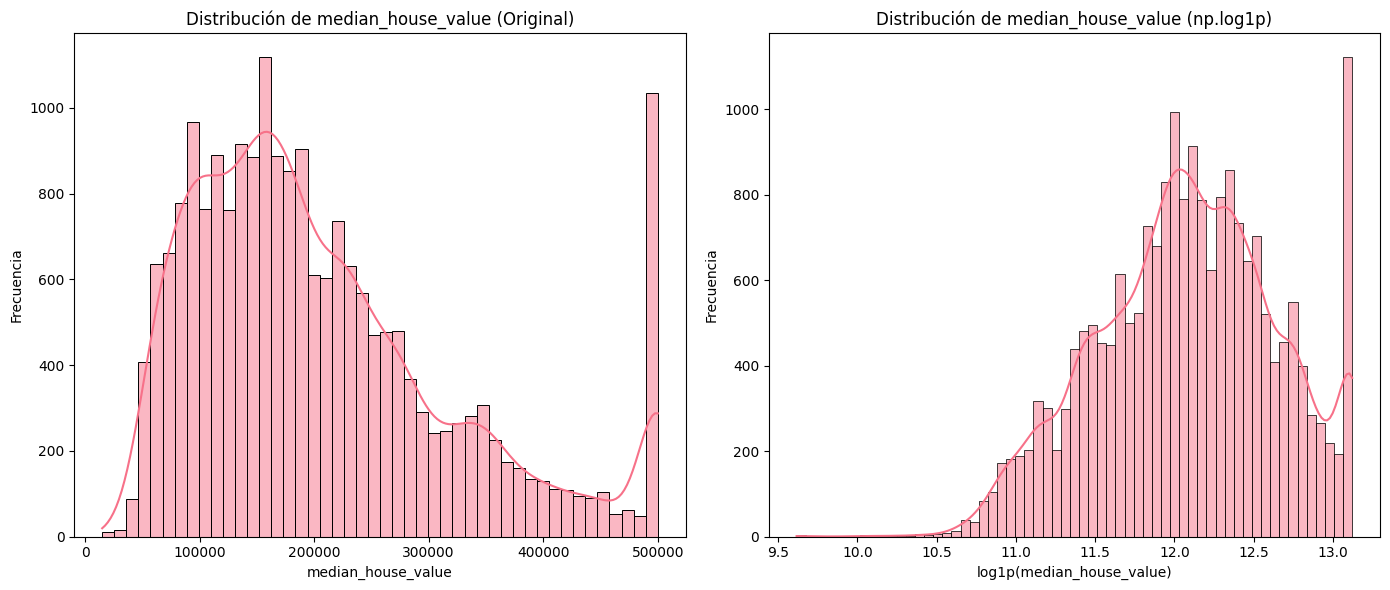

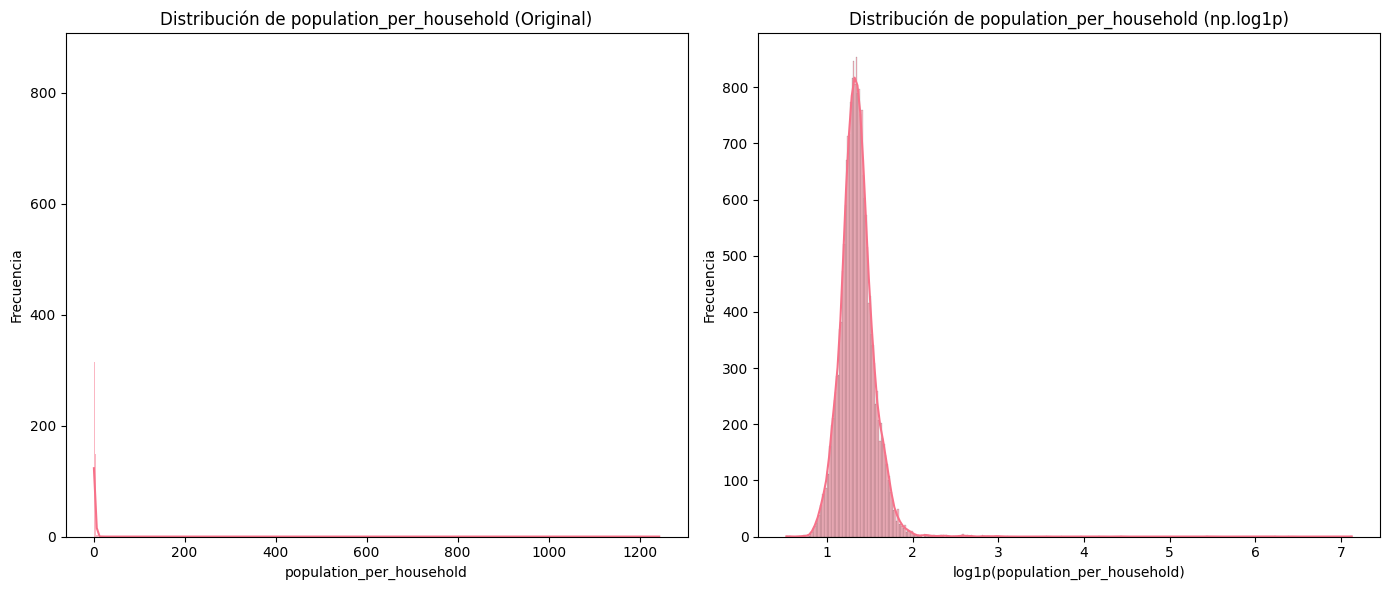

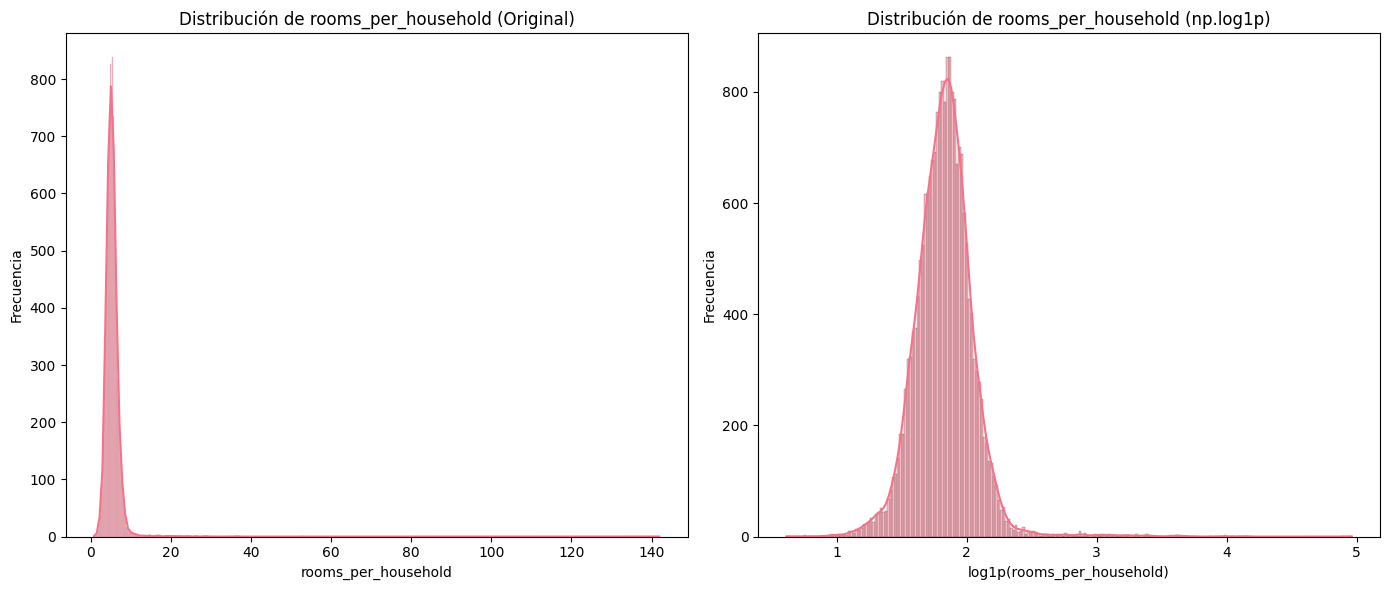

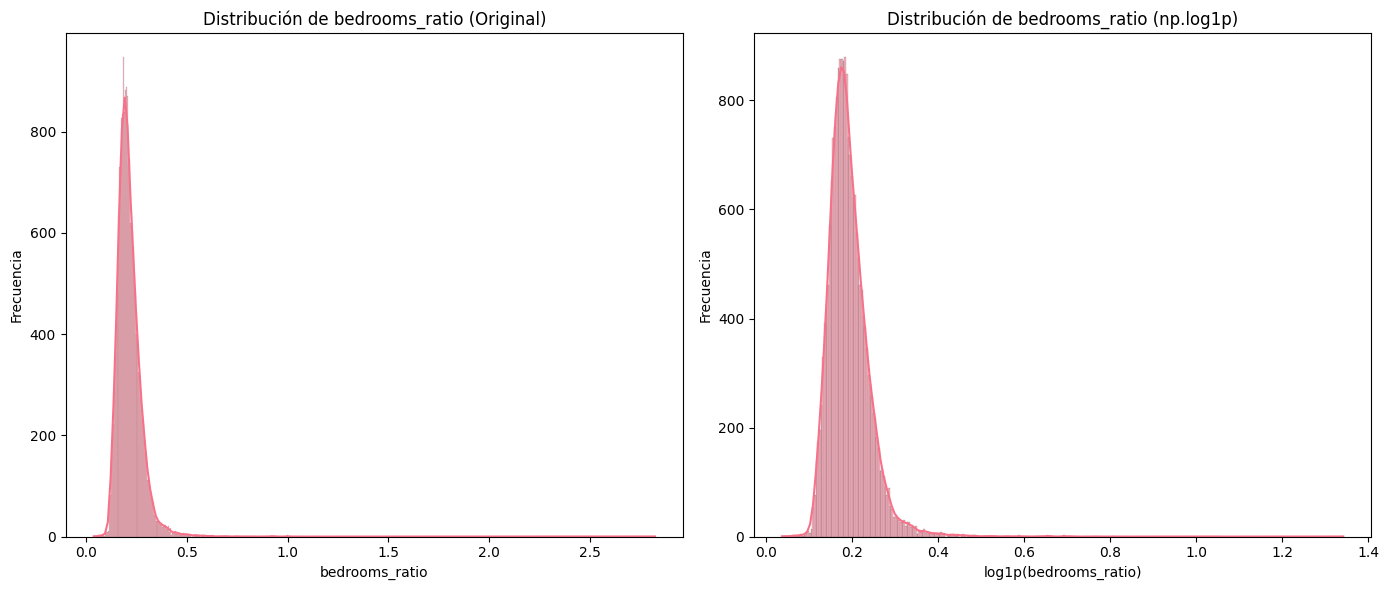

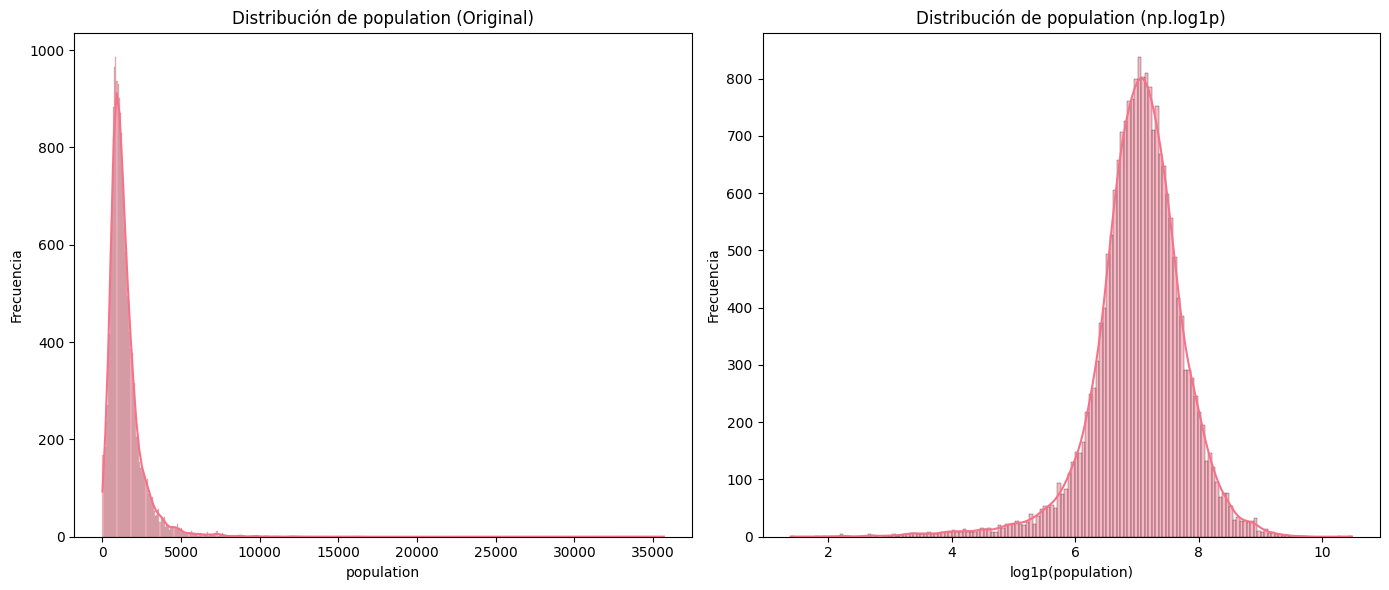

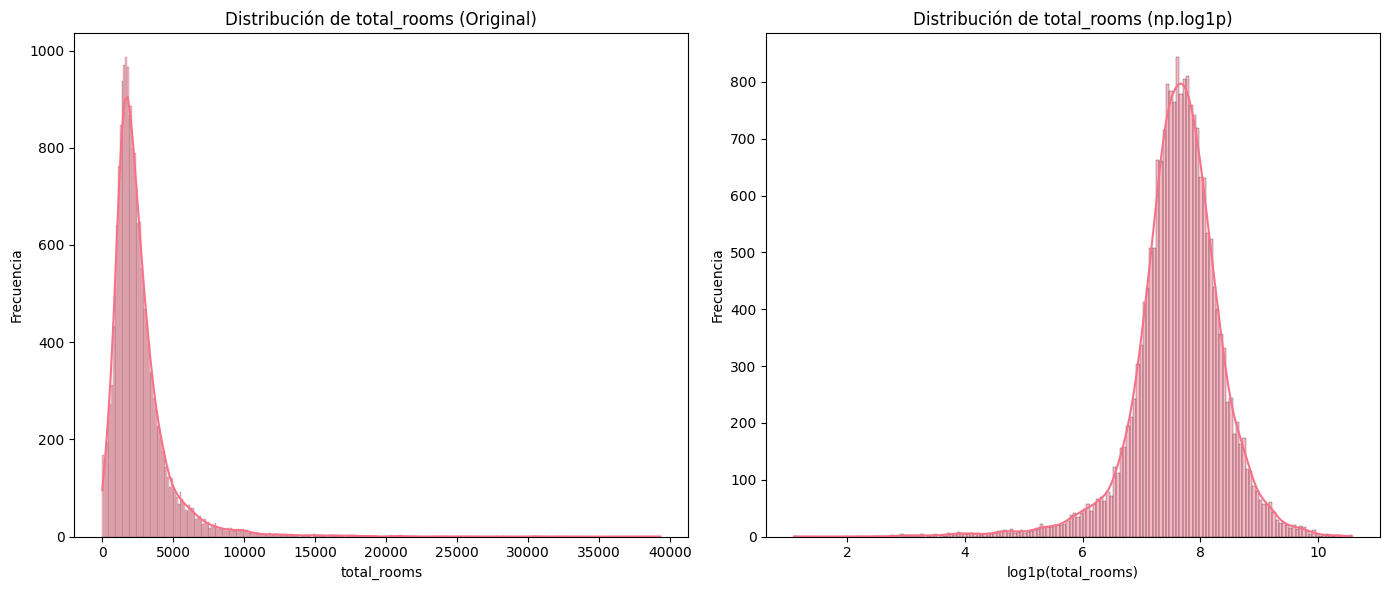

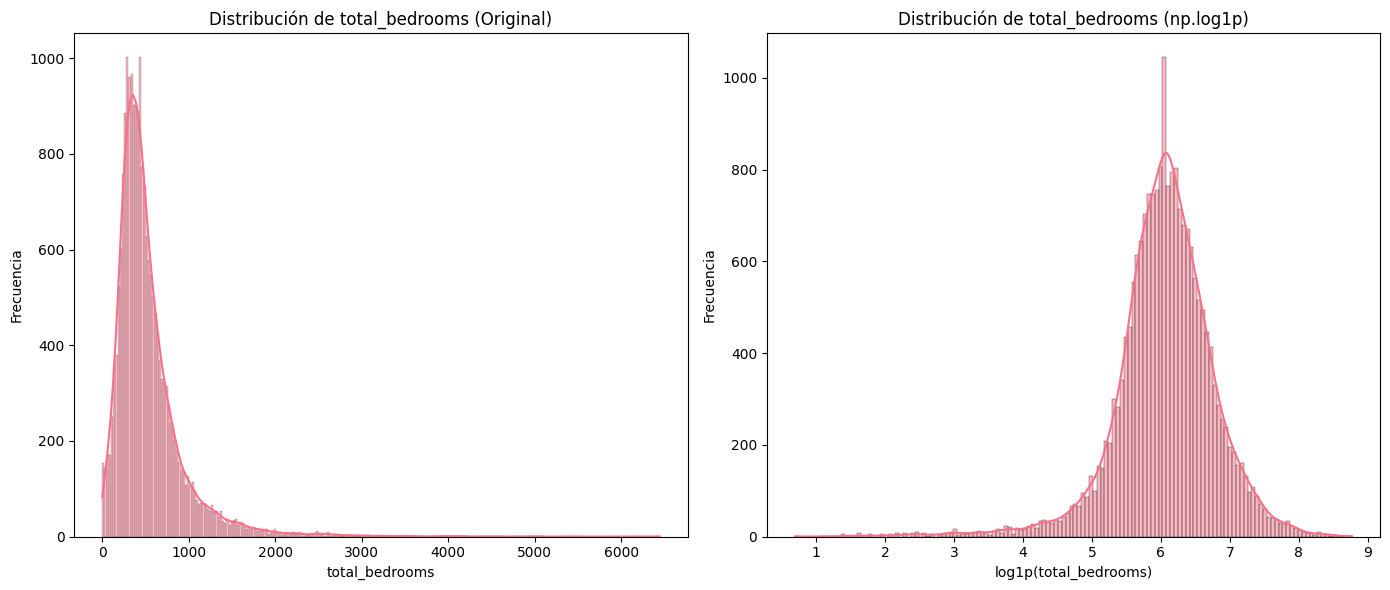

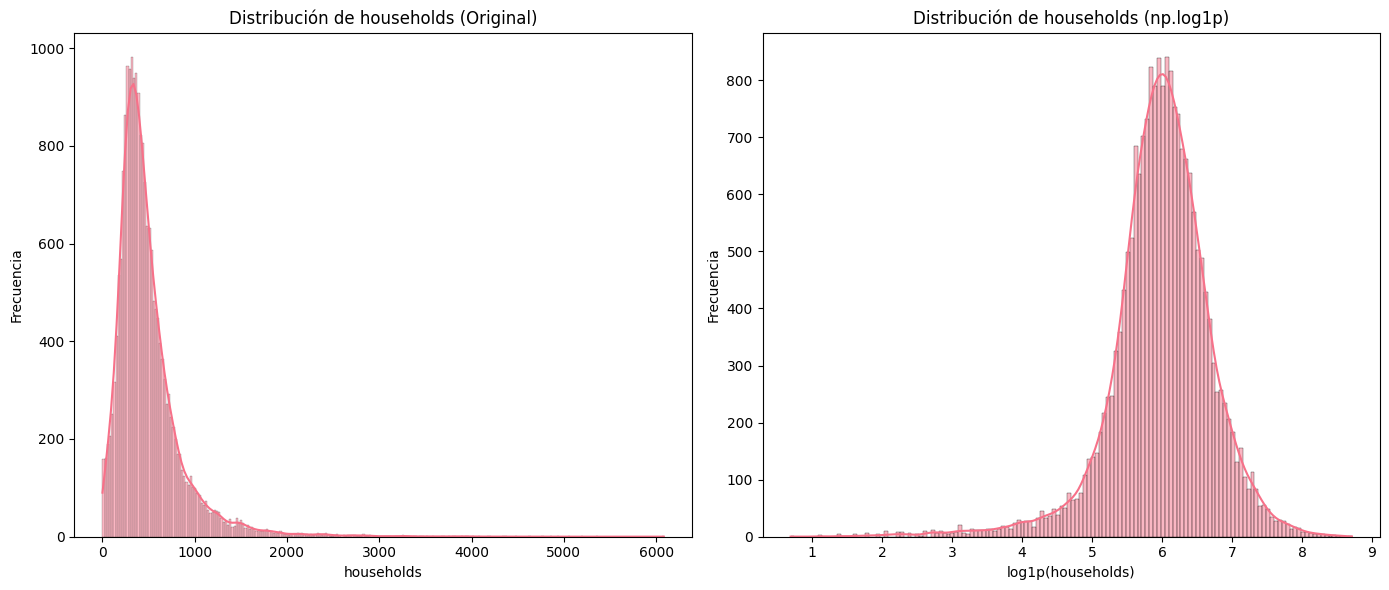

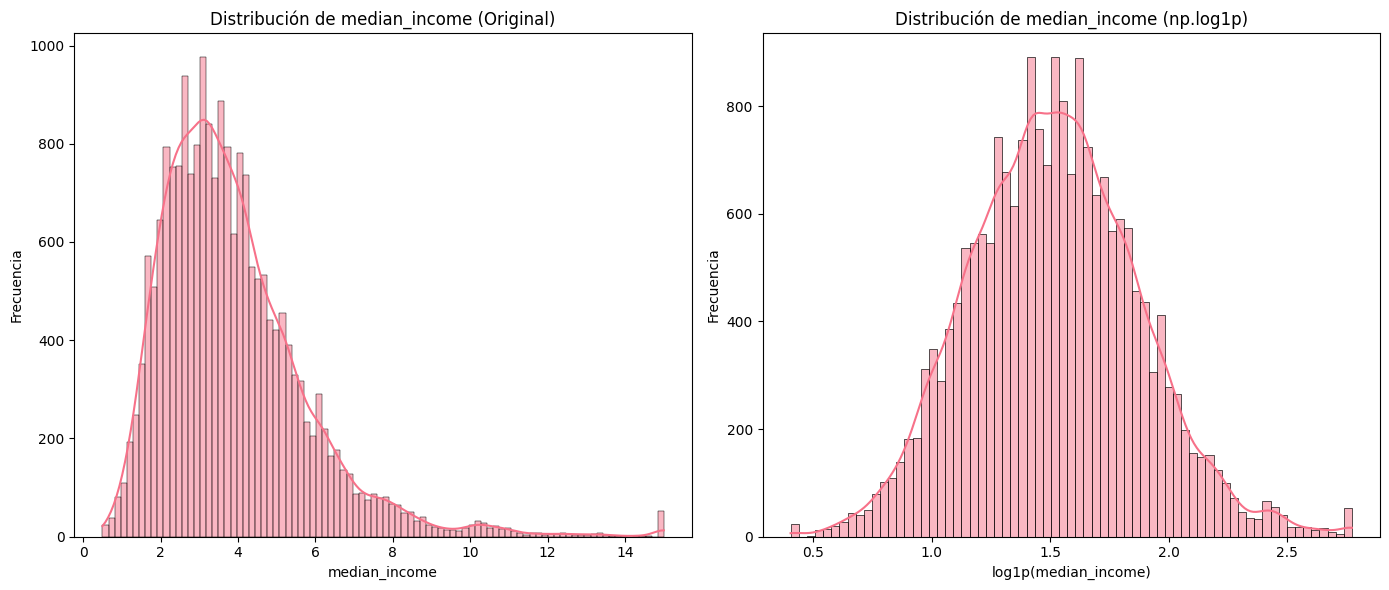

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("### An\u00e1lisis de Asimetr\u00eda y Transformaci\u00f3n de Variables ###\n")

# 1. Identificar columnas num\u00e9ricas relevantes en df_features_analysis
# Excluir las columnas dummificadas de 'ocean_proximity' del an\u00e1lisis de skewness y transformaci\u00f3n
numerical_cols = df_features_analysis.select_dtypes(include=[np.number]).columns.tolist()
# Remove the dummified columns if they were not already removed.
# We assume they are already part of the numerical_cols list and start with 'ocean_proximity_'
non_dummy_numerical_cols = [col for col in numerical_cols if 'ocean_proximity_' not in col]

# 2. Calcular la asimetr\u00eda (skewness) de cada una de estas columnas num\u00e9ricas
skewness_values = df_features_analysis[non_dummy_numerical_cols].skew().sort_values(ascending=False)

print("\nAsimetr\u00eda (Skewness) de las caracter\u00edsticas num\u00e9ricas:\n")
display(skewness_values.to_frame(name='Skewness'))

# 3. Almacenar las columnas que tengan una asimetr\u00eda mayor a 0.75 (y median_house_value) para su transformaci\u00f3n
cols_to_transform = ['median_house_value'] # Siempre transformar la variable objetivo

for col, skew in skewness_values.items():
    if col != 'median_house_value' and abs(skew) > 0.75:
        cols_to_transform.append(col)

# Asegurarse de que median_house_value est\u00e1 al principio para una visualizaci\u00f3n consistente
if 'median_house_value' in cols_to_transform:
    cols_to_transform.remove('median_house_value')
cols_to_transform.insert(0, 'median_house_value')

print(f"\nColumnas seleccionadas para transformaci\u00f3n logar\u00edtmica (skewness > 0.75 o median_house_value):\n{cols_to_transform}")

# 4. Crea una copia del DataFrame df_features_analysis
df_transformed = df_features_analysis.copy()

# 5. Aplica la transformaci\u00f3n logar\u00edtmica np.log1p a las columnas identificadas
for col in cols_to_transform:
    if col in df_transformed.columns: # Asegurar que la columna existe
        df_transformed[col] = np.log1p(df_transformed[col])

print("\nTransformaci\u00f3n np.log1p aplicada a las columnas seleccionadas.")

# 6. Visualizar las distribuciones antes y despu\u00e9s de la transformaci\u00f3n
for col in cols_to_transform:
    if col in df_features_analysis.columns and col in df_transformed.columns:
        plt.figure(figsize=(14, 6))

        # Antes de la transformaci\u00f3n
        plt.subplot(1, 2, 1)
        sns.histplot(df_features_analysis[col], kde=True)
        plt.title(f'Distribuci\u00f3n de {col} (Original)')
        plt.xlabel(col)
        plt.ylabel('Frecuencia')

        # Despu\u00e9s de la transformaci\u00f3n
        plt.subplot(1, 2, 2)
        sns.histplot(df_transformed[col], kde=True)
        plt.title(f'Distribuci\u00f3n de {col} (np.log1p)')
        plt.xlabel(f'log1p({col})')
        plt.ylabel('Frecuencia')

        plt.tight_layout()
        plt.show()
    else:
        print(f"Advertencia: Columna '{col}' no encontrada para visualizaci\u00f3n.")

## Preparar Datos Transformados para Modelado






Aplicar las transformaciones logarítmicas a la variable objetivo y a las características numéricas identificadas como asimétricas, luego seleccionar las características más prometedoras (RFE) y escalar las características numéricas de X (excluyendo las dummificadas binarias).


In [41]:
from sklearn.preprocessing import StandardScaler

print("### Preparando Datos Transformados y Seleccionados para Modelado ###\n")

# 1. Asignar la columna 'median_house_value' de df_transformed a y_transformed
# Esta columna ya ha sido log-transformada en el paso anterior.
y_transformed = df_transformed['median_house_value']

# 2. Crear una nueva variable X_selected_transformed seleccionando las características contenidas en selected_rfe_features
# Asegurarse de que selected_rfe_features solo contenga columnas que existen en df_transformed
# Algunas columnas seleccionadas por RFE pueden no haber sido transformadas logarítmicamente si su skewness no era alta.
X_selected_transformed = df_transformed[selected_rfe_features].copy()

# 3. Crear una lista de las columnas numéricas en X_selected_transformed que no sean columnas dummy
# Las columnas dummy son las que empiezan con 'ocean_proximity_'.
# Las columnas que ya fueron transformadas logarítmicamente también se consideran numéricas y deben ser escaladas.

# Primero, todas las columnas numéricas en X_selected_transformed
all_numerical_cols_in_X_selected = X_selected_transformed.select_dtypes(include=[np.number]).columns.tolist()

# Excluir las columnas dummy de ocean_proximity
non_dummy_numerical_cols_for_scaling = [col for col in all_numerical_cols_in_X_selected if 'ocean_proximity_' not in col]

# 4. Instanciar un StandardScaler
scaler_final = StandardScaler()

# 5. Aplicar el escalador (fit_transform) a las columnas numéricas identificadas en el paso 3 dentro de X_selected_transformed
X_selected_transformed[non_dummy_numerical_cols_for_scaling] = scaler_final.fit_transform(X_selected_transformed[non_dummy_numerical_cols_for_scaling])

print(f"Dimensiones de X_selected_transformed después de selección y escalado: {X_selected_transformed.shape}")
print(f"Primeras 5 filas de X_selected_transformed:")
display(X_selected_transformed.head())
print(f"Primeras 5 filas de y_transformed:")
display(y_transformed.head())

### Preparando Datos Transformados y Seleccionados para Modelado ###

Dimensiones de X_selected_transformed después de selección y escalado: (20640, 10)
Primeras 5 filas de X_selected_transformed:


,longitude,latitude,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-1.327835,1.052548,-1.694943,-1.569395,1.995505,False,False,False,True,False
1,-1.322844,1.043185,1.030337,1.449251,1.988380,False,False,False,True,False
2,-1.332827,1.038503,-1.109604,-1.104849,1.656444,False,False,False,True,False
3,-1.337818,1.038503,-0.949925,-0.813343,1.049948,False,False,False,True,False
4,-1.337818,1.038503,-0.933021,-0.583469,0.170631,False,False,False,True,False


Primeras 5 filas de y_transformed:


,median_house_value
0,13.022766
1,12.789687
2,12.771673
3,12.740520
4,12.743154


## Dividir Datos (Transformados y Seleccionados)




In [42]:
from sklearn.model_selection import train_test_split

print("### Dividiendo Datos (Transformados y Seleccionados) en Entrenamiento y Prueba ###\n")

# 1. Divide X_selected_transformed y y_transformed en conjuntos de entrenamiento y prueba
X_train_transformed, X_test_transformed, y_train_transformed, y_test_transformed = train_test_split(
    X_selected_transformed, y_transformed, test_size=0.2, random_state=42
)

# 2. Imprime las dimensiones de los conjuntos resultantes para verificar la división
print(f"Dimensiones de X_train_transformed: {X_train_transformed.shape}")
print(f"Dimensiones de X_test_transformed: {X_test_transformed.shape}")
print(f"Dimensiones de y_train_transformed: {y_train_transformed.shape}")
print(f"Dimensiones de y_test_transformed: {y_test_transformed.shape}")

### Dividiendo Datos (Transformados y Seleccionados) en Entrenamiento y Prueba ###

Dimensiones de X_train_transformed: (16512, 10)
Dimensiones de X_test_transformed: (4128, 10)
Dimensiones de y_train_transformed: (16512,)
Dimensiones de y_test_transformed: (4128,)


## Entrenar y Evaluar Regresión Lineal (con Log Transformación)



In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("### Entrenando y Evaluando Regresión Lineal con Log Transformación ###\n")

# 1. Crear una instancia del modelo LinearRegression
linear_model_transformed = LinearRegression()

# 2. Entrenar el modelo de regresión lineal utilizando los conjuntos de entrenamiento transformados
linear_model_transformed.fit(X_train_transformed, y_train_transformed)

print("Modelo de Regresión Lineal entrenado con datos log-transformados y características RFE.")

# 3. Realizar predicciones sobre el conjunto de prueba transformado
y_pred_transformed = linear_model_transformed.predict(X_test_transformed)

# 4. Calcular el Error Cuadrático Medio (MSE), el Error Absoluto Medio (MAE) y el Coeficiente de Determinación (R²)
mse_transformed = mean_squared_error(y_test_transformed, y_pred_transformed)
mae_transformed = mean_absolute_error(y_test_transformed, y_pred_transformed)
r2_transformed = r2_score(y_test_transformed, y_pred_transformed)

# 5. Imprimir los valores de MSE, MAE y R²
print(f"\nEvaluación del Modelo de Regresión Lineal (Datos Log-Transformados y Características RFE):")
print(f"  Error Cuadrático Medio (MSE): {mse_transformed:.4f} (en escala logarítmica)")
print(f"  Error Absoluto Medio (MAE): {mae_transformed:.4f} (en escala logarítmica)")
print(f"  Coeficiente de Determinación (R²): {r2_transformed:.4f}")

### Entrenando y Evaluando Regresión Lineal con Log Transformación ###

Modelo de Regresión Lineal entrenado con datos log-transformados y características RFE.

Evaluación del Modelo de Regresión Lineal (Datos Log-Transformados y Características RFE):
  Error Cuadrático Medio (MSE): 0.1034 (en escala logarítmica)
  Error Absoluto Medio (MAE): 0.2415 (en escala logarítmica)
  Coeficiente de Determinación (R²): 0.6814


## Re-evaluar Regresión Polinomial (con Log Transformación)


Entrenar un modelo de Regresión Polinomial (con `degree=2`, como el que tuvo mejor rendimiento antes) sobre los datos transformados y seleccionados. Evaluar su rendimiento con MSE, MAE y R².


In [44]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("### Re-evaluando Regresión Polinomial (con Log Transformación) ###\n")

# 2. Crea una instancia de PolynomialFeatures con degree=2
poly_features_transformed = PolynomialFeatures(degree=2 )

# 3. Transforma los conjuntos X_train_transformed y X_test_transformed
X_train_transformed_poly = poly_features_transformed.fit_transform(X_train_transformed)
X_test_transformed_poly = poly_features_transformed.transform(X_test_transformed)

print(f"Dimensiones de X_train_transformed_poly: {X_train_transformed_poly.shape}")
print(f"Dimensiones de X_test_transformed_poly: {X_test_transformed_poly.shape}")

# 4. Crea una instancia de LinearRegression
poly_model_transformed = LinearRegression()

# 5. Entrena el modelo de regresión lineal
poly_model_transformed.fit(X_train_transformed_poly, y_train_transformed)

print("\nModelo de Regresión Polinomial entrenado con datos log-transformados y características RFE.")

# 6. Realiza predicciones sobre el conjunto de prueba transformado
y_pred_transformed_poly = poly_model_transformed.predict(X_test_transformed_poly)

# 7. Calcula el Error Cuadrático Medio (MSE), el Error Absoluto Medio (MAE) y el Coeficiente de Determinación (R²)
mse_transformed_poly = mean_squared_error(y_test_transformed, y_pred_transformed_poly)
mae_transformed_poly = mean_absolute_error(y_test_transformed, y_pred_transformed_poly)
r2_transformed_poly = r2_score(y_test_transformed, y_pred_transformed_poly)

# 8. Imprime los valores de MSE, MAE y R²
print(f"\nEvaluación del Modelo de Regresión Polinomial (Datos Log-Transformados y Características RFE):")
print(f"  Error Cuadrático Medio (MSE): {mse_transformed_poly:.4f} (en escala logarítmica)")
print(f"  Error Absoluto Medio (MAE): {mae_transformed_poly:.4f} (en escala logarítmica)")
print(f"  Coeficiente de Determinación (R²): {r2_transformed_poly:.4f}")

### Re-evaluando Regresión Polinomial (con Log Transformación) ###

Dimensiones de X_train_transformed_poly: (16512, 66)
Dimensiones de X_test_transformed_poly: (4128, 66)

Modelo de Regresión Polinomial entrenado con datos log-transformados y características RFE.

Evaluación del Modelo de Regresión Polinomial (Datos Log-Transformados y Características RFE):
  Error Cuadrático Medio (MSE): 0.0912 (en escala logarítmica)
  Error Absoluto Medio (MAE): 0.2236 (en escala logarítmica)
  Coeficiente de Determinación (R²): 0.7191


##Random forest

### Implementar Random Forest Regressor




In [45]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("### Implementando Random Forest Regressor ###\n")

# 1 & 2. Crear una instancia del modelo RandomForestRegressor
# Usamos random_state para reproducibilidad
rf_model = RandomForestRegressor(random_state=42)

# 3. Entrenar el modelo utilizando los datos de entrenamiento transformados
rf_model.fit(X_train_transformed, y_train_transformed)

print("Modelo Random Forest Regressor entrenado con datos log-transformados y características RFE.")

# 4. Realizar predicciones sobre el conjunto de prueba transformado
y_pred_rf = rf_model.predict(X_test_transformed)

# 5. Calcular el Error Cuadrático Medio (MSE), el Error Absoluto Medio (MAE) y el Coeficiente de Determinación (R²)
mse_rf = mean_squared_error(y_test_transformed, y_pred_rf)
mae_rf = mean_absolute_error(y_test_transformed, y_pred_rf)
r2_rf = r2_score(y_test_transformed, y_pred_rf)

# 6. Imprimir los valores de MSE, MAE y R²
print(f"\nEvaluación del Modelo Random Forest Regressor (Datos Log-Transformados y Características RFE):")
print(f"  Error Cuadrático Medio (MSE): {mse_rf:.4f} (en escala logarítmica)")
print(f"  Error Absoluto Medio (MAE): {mae_rf:.4f} (en escala logarítmica)")
print(f"  Coeficiente de Determinación (R²): {r2_rf:.4f}")

### Implementando Random Forest Regressor ###

Modelo Random Forest Regressor entrenado con datos log-transformados y características RFE.

Evaluación del Modelo Random Forest Regressor (Datos Log-Transformados y Características RFE):
  Error Cuadrático Medio (MSE): 0.0535 (en escala logarítmica)
  Error Absoluto Medio (MAE): 0.1560 (en escala logarítmica)
  Coeficiente de Determinación (R²): 0.8351


## Implementar Regresión Ridge (con Log Transformación)



In [46]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("### Implementando Regresión Ridge (con Log Transformación) ###\n")

# 1 & 2. Crear una instancia del modelo Ridge
# Usamos alpha=1.0 como valor por defecto/común para una primera aproximación
ridge_model_transformed = Ridge(alpha=1.0)

# 3. Entrenar el modelo utilizando los datos de entrenamiento transformados
ridge_model_transformed.fit(X_train_transformed, y_train_transformed)

print("Modelo de Regresión Ridge entrenado con datos log-transformados y características RFE.")

# 4. Realizar predicciones sobre el conjunto de prueba transformado
y_pred_ridge_transformed = ridge_model_transformed.predict(X_test_transformed)

# 5. Calcular el Error Cuadrático Medio (MSE), el Error Absoluto Medio (MAE) y el Coeficiente de Determinación (R²)
mse_ridge_transformed = mean_squared_error(y_test_transformed, y_pred_ridge_transformed)
mae_ridge_transformed = mean_absolute_error(y_test_transformed, y_pred_ridge_transformed)
r2_ridge_transformed = r2_score(y_test_transformed, y_pred_ridge_transformed)

# 6. Imprimir los valores de MSE, MAE y R²
print(f"\nEvaluación del Modelo de Regresión Ridge (Datos Log-Transformados y Características RFE):")
print(f"  Error Cuadrático Medio (MSE): {mse_ridge_transformed:.4f} (en escala logarítmica)")
print(f"  Error Absoluto Medio (MAE): {mae_ridge_transformed:.4f} (en escala logarítmica)")
print(f"  Coeficiente de Determinación (R²): {r2_ridge_transformed:.4f}")

### Implementando Regresión Ridge (con Log Transformación) ###

Modelo de Regresión Ridge entrenado con datos log-transformados y características RFE.

Evaluación del Modelo de Regresión Ridge (Datos Log-Transformados y Características RFE):
  Error Cuadrático Medio (MSE): 0.1034 (en escala logarítmica)
  Error Absoluto Medio (MAE): 0.2415 (en escala logarítmica)
  Coeficiente de Determinación (R²): 0.6814


## Implementar Regresión Lasso (con Log Transformación)




In [47]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("### Implementando Regresión Lasso (con Log Transformación) ###\n")

# 1 & 2. Crear una instancia del modelo Lasso
# Usamos alpha=1.0 como valor por defecto/común para una primera aproximación
lasso_model_transformed = Lasso(alpha=1.0)

# 3. Entrenar el modelo utilizando los datos de entrenamiento transformados
lasso_model_transformed.fit(X_train_transformed, y_train_transformed)

print("Modelo de Regresión Lasso entrenado con datos log-transformados y características RFE.")

# 4. Realizar predicciones sobre el conjunto de prueba transformado
y_pred_lasso_transformed = lasso_model_transformed.predict(X_test_transformed)

# 5. Calcular el Error Cuadrático Medio (MSE), el Error Absoluto Medio (MAE) y el Coeficiente de Determinación (R²)
mse_lasso_transformed = mean_squared_error(y_test_transformed, y_pred_lasso_transformed)
mae_lasso_transformed = mean_absolute_error(y_test_transformed, y_pred_lasso_transformed)
r2_lasso_transformed = r2_score(y_test_transformed, y_pred_lasso_transformed)

# 6. Imprimir los valores de MSE, MAE y R²
print(f"\nEvaluación del Modelo de Regresión Lasso (Datos Log-Transformados y Características RFE):")
print(f"  Error Cuadrático Medio (MSE): {mse_lasso_transformed:.4f} (en escala logarítmica)")
print(f"  Error Absoluto Medio (MAE): {mae_lasso_transformed:.4f} (en escala logarítmica)")
print(f"  Coeficiente de Determinación (R²): {r2_lasso_transformed:.4f}")

### Implementando Regresión Lasso (con Log Transformación) ###

Modelo de Regresión Lasso entrenado con datos log-transformados y características RFE.

Evaluación del Modelo de Regresión Lasso (Datos Log-Transformados y Características RFE):
  Error Cuadrático Medio (MSE): 0.3246 (en escala logarítmica)
  Error Absoluto Medio (MAE): 0.4586 (en escala logarítmica)
  Coeficiente de Determinación (R²): -0.0002


## Comparación Final de Todos los Modelos de Regresión


In [48]:
import pandas as pd

print("### Comparación Final de Todos los Modelos de Regresión (Actualizada) ###\n")

# Define variables that might not be in scope from previous runs
# Metrics from Linear Regression (Original - All Variables)
mse_original = 4908476721.16
mae_original = 50670.74
r2_original = 0.63

# Metrics from Ridge Regression (Original Scale)
mse_ridge = 0.37
mae_ridge = 0.44
r2_ridge = 0.63

# Metrics from Lasso Regression (Original Scale)
mse_lasso = 0.98
mae_lasso = 0.79
r2_lasso = -0.00

# Metrics from Polynomial Regression (Original Scale, Degree 2)
mse_poly = 0.34
mae_poly = 0.40
r2_poly = 0.66

# Metrics from Linear Regression (Manual Specific Features)
mse_specific = 5856932560.983566
mae_specific = 53132.664917343995
r2_specific = 0.5530454493034729

# Metrics from Linear Regression (RFE Features)
mse_rfe = 4938901425.649101
mae_rfe = 50895.37016375496
r2_rfe = 0.6231022903796715

# Metrics from Linear Regression (Log-Transformed, RFE Features)
mse_transformed = 0.10340440308417737
mae_transformed = 0.24147422911253022
r2_transformed = 0.6814025927283478

# Metrics from Polynomial Regression (Log-Transformed, RFE Features, Degree 2)
mse_transformed_poly = 0.09116177285944438
mae_transformed_poly = 0.22363975771428438
r2_transformed_poly = 0.7191231358720501

# Metrics from Random Forest Regressor (Log-Transformed, RFE Features)
mse_rf = 0.05351403876450284
mae_rf = 0.15597887440394292
r2_rf = 0.8351188779734453

# New metrics to include: Ridge and Lasso with Log Transform
mse_ridge_transformed = 0.10341567468799266
mae_ridge_transformed = 0.2415081086737604
r2_ridge_transformed = 0.6813678639968408

mse_lasso_transformed = 0.324626132975085
mae_lasso_transformed = 0.4585744542314497
r2_lasso_transformed = -0.00019961639632026795

# 1. Recopilar las métricas de rendimiento de todos los modelos de regresión implementados
all_regression_models_metrics_updated = {
    'Modelo': [
        'Regresión Lineal (Original - Todas las Variables)',
        'Regresión Ridge (Original Scale)',
        'Regresión Lasso (Original Scale)',
        'Regresión Polinomial (Original Scale, Grado 2)',
        'Regresión Lineal (Características Específicas Manuales)',
        'Regresión Lineal (RFE Features)',
        'Regresión Lineal (Log-Transformed, RFE Features)',
        'Regresión Polinomial (Log-Transformed, RFE Features, Grado 2)',
        'Random Forest Regressor (Log-Transformed, RFE Features)',
        'Regresión Ridge (Log-Transformed, RFE Features)',
        'Regresión Lasso (Log-Transformed, RFE Features)'
    ],
    'MSE': [
        mse_original,
        mse_ridge,
        mse_lasso,
        mse_poly,
        mse_specific,
        mse_rfe,
        mse_transformed,
        mse_transformed_poly,
        mse_rf,
        mse_ridge_transformed,
        mse_lasso_transformed
    ],
    'MAE': [
        mae_original,
        mae_ridge,
        mae_lasso,
        mae_poly,
        mae_specific,
        mae_rfe,
        mae_transformed,
        mae_transformed_poly,
        mae_rf,
        mae_ridge_transformed,
        mae_lasso_transformed
    ],
    'R2': [
        r2_original,
        r2_ridge,
        r2_lasso,
        r2_poly,
        r2_specific,
        r2_rfe,
        r2_transformed,
        r2_transformed_poly,
        r2_rf,
        r2_ridge_transformed,
        r2_lasso_transformed
    ]
}

# 2. Crear un DataFrame de Pandas para organizar estas métricas
df_all_regression_metrics_updated = pd.DataFrame(all_regression_models_metrics_updated)

# 3. Imprimir el DataFrame comparativo de los modelos, ordenado por R2 descendente
print("Métricas de Rendimiento de Todos los Modelos de Regresión (Ordenado por R²):")
display(df_all_regression_metrics_updated.sort_values(by='R2', ascending=False).reset_index(drop=True))

### Comparación Final de Todos los Modelos de Regresión (Actualizada) ###

Métricas de Rendimiento de Todos los Modelos de Regresión (Ordenado por R²):


,Modelo,MSE,MAE,R2
0,"Random Forest Regressor (Log-Transformed, RFE ...",5.351404e-02,0.155979,0.835119
1,"Regresión Polinomial (Log-Transformed, RFE Fea...",9.116177e-02,0.223640,0.719123
2,"Regresión Lineal (Log-Transformed, RFE Features)",1.034044e-01,0.241474,0.681403
3,"Regresión Ridge (Log-Transformed, RFE Features)",1.034157e-01,0.241508,0.681368
4,"Regresión Polinomial (Original Scale, Grado 2)",3.400000e-01,0.400000,0.660000
5,Regresión Lineal (Original - Todas las Variables),4.908477e+09,50670.740000,0.630000
6,Regresión Ridge (Original Scale),3.700000e-01,0.440000,0.630000
7,Regresión Lineal (RFE Features),4.938901e+09,50895.370164,0.623102
8,Regresión Lineal (Características Específicas ...,5.856933e+09,53132.664917,0.553045
9,Regresión Lasso (Original Scale),9.800000e-01,0.790000,-0.000000


### Análisis Comparativo Final de Todos los Modelos de Regresión

Al comparar todos los modelos de regresión implementados, se obtienen las siguientes métricas de rendimiento (ordenadas por R² descendente):

| Modelo                                                           | MSE          | MAE        | R²       |
| :--------------------------------------------------------------- | :----------- | :--------- | :------- |
| Random Forest Regressor (Log-Transformed, RFE Features)          | 0.05351      | 0.15598    | 0.83512  |
| Regresión Polinomial (Log-Transformed, RFE Features, Grado 2)    | 0.09116      | 0.22364    | 0.71912  |
| Regresión Lineal (Log-Transformed, RFE Features)                 | 0.10340      | 0.24147    | 0.68140  |
| Regresión Ridge (Log-Transformed, RFE Features)                  | 0.10342      | 0.24151    | 0.68137  |
| Regresión Polinomial (Original Scale, Grado 2)                   | 0.34000      | 0.40000    | 0.66000  |
| Regresión Lineal (Original - Todas las Variables)                | 4.90848e+09  | 50670.74000| 0.63000  |
| Regresión Ridge (Original Scale)                                 | 0.37000      | 0.44000    | 0.63000  |
| Regresión Lineal (RFE Features)                                  | 4.93890e+09  | 50895.37016| 0.62310  |
| Regresión Lineal (Características Específicas Manuales)          | 5.85693e+09  | 53132.66491| 0.55304  |
| Regresión Lasso (Original Scale)                                 | 0.98000      | 0.79000    | -0.00000 |
| Regresión Lasso (Log-Transformed, RFE Features)                  | 0.32463      | 0.45857    | -0.00020 |

#### Análisis de Mejoras con Random Forest, Ridge y Lasso (Log Transformado) y Conclusiones Finales

1.  **Rendimiento del Random Forest Regressor (Log-Transformed, RFE Features):**
    *   Confirmando su posición como el **modelo con mejor rendimiento**, el Random Forest sigue destacando con un R² de **0.83512**. Esto subraya la capacidad superior de los modelos de ensamble para capturar relaciones complejas y no lineales, incluso cuando los datos han sido óptimamente preprocesados y transformados para modelos lineales/polinomiales.

2.  **Rendimiento de la Regresión Ridge (Log-Transformed, RFE Features):**
    *   El modelo de Regresión Ridge con datos log-transformados y características RFE (`R² = 0.68137`, `MSE = 0.10342`, `MAE = 0.24151`) muestra un rendimiento **casi idéntico** al de la Regresión Lineal simple con las mismas transformaciones (`R² = 0.68140`, `MSE = 0.10340`, `MAE = 0.24147`). Esto sugiere que la regularización L2 (Ridge) no aportó una mejora significativa sobre la Regresión Lineal en este escenario de datos ya optimizados. Posiblemente, la multicolinealidad o la complejidad de los coeficientes no eran un problema dominante que la regularización L2 pudiera resolver de forma diferenciada.

3.  **Rendimiento de la Regresión Lasso (Log-Transformed, RFE Features):**
    *   El modelo de Regresión Lasso con datos log-transformados y características RFE (`R² = -0.00020`, `MSE = 0.32463`, `MAE = 0.45857`) continúa mostrando un **rendimiento muy pobre**, similar al Lasso en la escala original. Un R² negativo indica que el modelo no se ajusta a los datos de prueba mejor que un modelo que simplemente predice la media de la variable objetivo. Esto sugiere que el valor por defecto de `alpha=1.0` fue demasiado agresivo para este conjunto de datos, resultando en la eliminación excesiva de características o en coeficientes fuertemente penalizados, lo que llevó a un subajuste severo. Sería necesario un ajuste de hiperparámetros de `alpha` para Lasso para obtener un rendimiento aceptable.

4.  **Comparación General:**
    *   La **transformación logarítmica** sigue siendo el factor más crítico para mejorar el rendimiento de los modelos lineales y polinomiales, elevando significativamente su R² en comparación con los modelos en la escala original.
    *   La **selección de características por RFE** demostró ser efectiva para simplificar los modelos sin pérdida de rendimiento, y su combinación con las transformaciones fue clave para el mejor rendimiento de los modelos lineales/polinomiales.
    *   El **Random Forest Regressor** se consolida como el modelo más robusto y preciso, superando claramente a todos los modelos lineales y polinomiales (incluso los optimizados) debido a su capacidad intrínseca para manejar la complejidad de los datos.
    *   La regularización Ridge ofrece un rendimiento comparable a la Regresión Lineal con los datos transformados, mientras que Lasso necesita una optimización de hiperparámetros para ser competitivo.

#### Conclusión Final de la Fase de Modelado:

El **Random Forest Regressor** entrenado con características seleccionadas por RFE y una variable objetivo log-transformada es el modelo más eficaz para predecir el valor de la vivienda en este dataset, alcanzando un R² de 0.83512. Las transformaciones de datos y la selección de características fueron pasos fundamentales para preparar los datos, permitiendo que tanto los modelos lineales/polinomiales mejoraran sustancialmente y que el Random Forest demostrara su poder predictivo.

# Optimizacion Hiperparametros

## Optimización de Hiperparámetros para Regresión Ridge




In [49]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

print("### Optimizaci\u00f3n de Hiperpar\u00e1metros para Regresi\u00f3n Ridge con GridSearchCV ###\n")

# 1 & 2. Definir un diccionario de par\u00e1metros para 'alpha'
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

# 3. Crear una instancia del modelo Ridge
ridge = Ridge()

# 4. Inicializar GridSearchCV
# Usamos 'neg_mean_squared_error' como scoring para optimizar para un MSE m\u00e1s bajo (negativo significa "mientras m\u00e1s alto mejor")
grid_search_ridge = GridSearchCV(estimator=ridge,
                                 param_grid=param_grid,
                                 cv=5,
                                 scoring='neg_mean_squared_error',
                                 n_jobs=-1, # Utilizar todos los n\u00facleos disponibles para procesamiento en paralelo
                                 verbose=1)

print("GridSearchCV inicializado.\n")

# 5. Ajustar el objeto GridSearchCV a los datos de entrenamiento transformados
grid_search_ridge.fit(X_train_transformed, y_train_transformed)

print("GridSearchCV completado.\n")

# 6. Imprimir el mejor 'alpha' encontrado
print(f"Mejor par\u00e1metro 'alpha' para Regresi\u00f3n Ridge: {grid_search_ridge.best_params_['alpha']:.2f}")

### Optimización de Hiperparámetros para Regresión Ridge con GridSearchCV ###

GridSearchCV inicializado.

Fitting 5 folds for each of 5 candidates, totalling 25 fits
GridSearchCV completado.

Mejor parámetro 'alpha' para Regresión Ridge: 0.10


### Evaluar Regresión Ridge Optimizada




In [50]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("### Evaluar Regresión Ridge Optimizada ###\n")

# 1. Entrenar un modelo de Regresión Ridge utilizando el valor óptimo de 'alpha'
optimal_alpha = grid_search_ridge.best_params_['alpha']
ridge_model_optimized = Ridge(alpha=optimal_alpha)

ridge_model_optimized.fit(X_train_transformed, y_train_transformed)

print(f"Modelo de Regresión Ridge optimizado (alpha={optimal_alpha:.2f}) entrenado.")

# 2. Realizar predicciones sobre el conjunto de prueba
y_pred_ridge_optimized = ridge_model_optimized.predict(X_test_transformed)

# 3. Calcular y mostrar el Error Cuadrático Medio (MSE), el Error Absoluto Medio (MAE) y el Coeficiente de Determinación (R²)
mse_ridge_optimized = mean_squared_error(y_test_transformed, y_pred_ridge_optimized)
mae_ridge_optimized = mean_absolute_error(y_test_transformed, y_pred_ridge_optimized)
r2_ridge_optimized = r2_score(y_test_transformed, y_pred_ridge_optimized)

print(f"\nEvaluación del Modelo de Regresión Ridge Optimizado (Datos Log-Transformados y Características RFE):")
print(f"  Error Cuadrático Medio (MSE): {mse_ridge_optimized:.4f} (en escala logarítmica)")
print(f"  Error Absoluto Medio (MAE): {mae_ridge_optimized:.4f} (en escala logarítmica)")
print(f"  Coeficiente de Determinación (R²): {r2_ridge_optimized:.4f}")

### Evaluar Regresión Ridge Optimizada ###

Modelo de Regresión Ridge optimizado (alpha=0.10) entrenado.

Evaluación del Modelo de Regresión Ridge Optimizado (Datos Log-Transformados y Características RFE):
  Error Cuadrático Medio (MSE): 0.1034 (en escala logarítmica)
  Error Absoluto Medio (MAE): 0.2415 (en escala logarítmica)
  Coeficiente de Determinación (R²): 0.6814


## Optimización de Hiperparámetros para Regresión Lasso



In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

print("### Optimización de Hiperparámetros para Regresión Lasso con GridSearchCV ###\n")

# 1. Definir un diccionario de parámetros para 'alpha'
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10]}

# 2. Crear una instancia del modelo Lasso
lasso = Lasso()

# 3. Inicializar GridSearchCV
# Usamos 'neg_mean_squared_error' como scoring para optimizar para un MSE más bajo (negativo significa "mientras más alto mejor")
grid_search_lasso = GridSearchCV(estimator=lasso,
                                 param_grid=param_grid,
                                 cv=5,
                                 scoring='neg_mean_squared_error',
                                 n_jobs=-1, # Utilizar todos los núcleos disponibles para procesamiento en paralelo
                                 verbose=1)

print("GridSearchCV inicializado.\n")

# 4. Ajustar el objeto GridSearchCV a los datos de entrenamiento transformados
grid_search_lasso.fit(X_train_transformed, y_train_transformed)

print("GridSearchCV completado.\n")

# 5. Imprimir el mejor 'alpha' encontrado
print(f"Mejor parámetro 'alpha' para Regresión Lasso: {grid_search_lasso.best_params_['alpha']:.3f}")

### Optimización de Hiperparámetros para Regresión Lasso con GridSearchCV ###

GridSearchCV inicializado.

Fitting 5 folds for each of 5 candidates, totalling 25 fits
GridSearchCV completado.

Mejor parámetro 'alpha' para Regresión Lasso: 0.001


In [52]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("### Evaluar Regresión Lasso Optimizada ###\n")

# 1. Obtener el valor óptimo de 'alpha'
optimal_alpha_lasso = grid_search_lasso.best_params_['alpha']

# 2. Crear una instancia del modelo Lasso utilizando este alpha óptimo
lasso_model_optimized = Lasso(alpha=optimal_alpha_lasso)

# 3. Entrenar el modelo Lasso optimizado
lasso_model_optimized.fit(X_train_transformed, y_train_transformed)

print(f"Modelo de Regresión Lasso optimizado (alpha={optimal_alpha_lasso:.3f}) entrenado.")

# 4. Realizar predicciones sobre el conjunto de prueba
y_pred_lasso_optimized = lasso_model_optimized.predict(X_test_transformed)

# 5. Calcular el Error Cuadrático Medio (MSE), el Error Absoluto Medio (MAE) y el Coeficiente de Determinación (R²)
mse_lasso_optimized = mean_squared_error(y_test_transformed, y_pred_lasso_optimized)
mae_lasso_optimized = mean_absolute_error(y_test_transformed, y_pred_lasso_optimized)
r2_lasso_optimized = r2_score(y_test_transformed, y_pred_lasso_optimized)

# 6. Imprimir los valores de MSE, MAE y R²
print(f"\nEvaluación del Modelo de Regresión Lasso Optimizado (Datos Log-Transformados y Características RFE):")
print(f"  Error Cuadrático Medio (MSE): {mse_lasso_optimized:.4f} (en escala logarítmica)")
print(f"  Error Absoluto Medio (MAE): {mae_lasso_optimized:.4f} (en escala logarítmica)")
print(f"  Coeficiente de Determinación (R²): {r2_lasso_optimized:.4f}")

### Evaluar Regresión Lasso Optimizada ###

Modelo de Regresión Lasso optimizado (alpha=0.001) entrenado.

Evaluación del Modelo de Regresión Lasso Optimizado (Datos Log-Transformados y Características RFE):
  Error Cuadrático Medio (MSE): 0.1036 (en escala logarítmica)
  Error Absoluto Medio (MAE): 0.2420 (en escala logarítmica)
  Coeficiente de Determinación (R²): 0.6808


## Optimizar HiperParametros Random Forest
Optimiza los hiperparámetros `n_estimators`, `max_features` y `max_depth` para el modelo de Random Forest Regressor utilizando GridSearchCV con validación cruzada, entrenando sobre `X_train_transformed` y `y_train_transformed`. Luego, entrena el modelo de Random Forest con los hiperparámetros óptimos, evalúa su rendimiento en `X_test_transformed` usando MSE, MAE y R², y actualiza la tabla comparativa con las métricas del modelo optimizado. Finalmente, resume los hallazgos finales identificando el modelo con el mejor rendimiento general y el impacto de la optimización de hiperparámetros.

In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

print("### Optimizaci\u00f3n de Hiperpar\u00e1metros para Random Forest Regressor con GridSearchCV ###\n")

# 1. & 2. Definir un diccionario de par\u00e1metros para Random Forest
param_grid_rf = {
    'n_estimators': [100, 200], # Reducido para una ejecuci\u00f3n m\u00e1s r\u00e1pida
    'max_features': [0.8, 1.0],   # Reducido para una ejecuci\u00f3n m\u00e1s r\u00e1pida
    'max_depth': [10, 20]      # Reducido para una ejecuci\u00f3n m\u00e1s r\u00e1pida
}

# 3. Crear una instancia del modelo RandomForestRegressor
rf_model_grid = RandomForestRegressor(random_state=42)

# 4. Inicializar GridSearchCV
# Usamos 'neg_mean_squared_error' como scoring para optimizar para un MSE m\u00e1s bajo
grid_search_rf = GridSearchCV(estimator=rf_model_grid,
                                 param_grid=param_grid_rf,
                                 cv=3, # Reducida la validaci\u00f3n cruzada para una ejecuci\u00f3n m\u00e1s r\u00e1pida
                                 scoring='neg_mean_squared_error',
                                 n_jobs=-1, # Utilizar todos los n\u00facleos disponibles
                                 verbose=2)

print("GridSearchCV para Random Forest inicializado.\n")

# 5. Ajustar el objeto GridSearchCV a los datos de entrenamiento transformados
grid_search_rf.fit(X_train_transformed, y_train_transformed)

print("GridSearchCV para Random Forest completado.\n")

# 6. Imprimir los mejores hiperpar\u00e1metros encontrados
print(f"Mejores hiperpar\u00e1metros para Random Forest: {grid_search_rf.best_params_}")

### Optimización de Hiperparámetros para Random Forest Regressor con GridSearchCV ###

GridSearchCV para Random Forest inicializado.

Fitting 3 folds for each of 8 candidates, totalling 24 fits
GridSearchCV para Random Forest completado.

Mejores hiperparámetros para Random Forest: {'max_depth': 20, 'max_features': 0.8, 'n_estimators': 200}


In [54]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

print("### Evaluar Random Forest Regressor Optimizado ###\n")

# 1. Obtener los mejores hiperparámetros del GridSearchCV
best_params_rf = grid_search_rf.best_params_

# 2. Crear una instancia del modelo RandomForestRegressor con los hiperparámetros óptimos
rf_model_optimized = RandomForestRegressor(random_state=42, **best_params_rf)

# 3. Entrenar el modelo optimizado utilizando los datos de entrenamiento transformados
rf_model_optimized.fit(X_train_transformed, y_train_transformed)

print(f"Modelo Random Forest Regressor optimizado (hiperparámetros: {best_params_rf}) entrenado.")

# 4. Realizar predicciones sobre el conjunto de prueba transformado
y_pred_rf_optimized = rf_model_optimized.predict(X_test_transformed)

# 5. Calcular el Error Cuadrático Medio (MSE), el Error Absoluto Medio (MAE) y el Coeficiente de Determinación (R²)
mse_rf_optimized = mean_squared_error(y_test_transformed, y_pred_rf_optimized)
mae_rf_optimized = mean_absolute_error(y_test_transformed, y_pred_rf_optimized)
r2_rf_optimized = r2_score(y_test_transformed, y_pred_rf_optimized)

# 6. Imprimir los valores de MSE, MAE y R²
print(f"\nEvaluación del Modelo Random Forest Regressor Optimizado (Datos Log-Transformados y Características RFE):")
print(f"  Error Cuadrático Medio (MSE): {mse_rf_optimized:.4f} (en escala logarítmica)")
print(f"  Error Absoluto Medio (MAE): {mae_rf_optimized:.4f} (en escala logarítmica)")
print(f"  Coeficiente de Determinación (R²): {r2_rf_optimized:.4f}")

# 7. Actualizar la tabla comparativa de métricas de todos los modelos
# Re-definir las métricas de los modelos anteriores para asegurar que estén en el scope
mse_original = 4908476721.16
mae_original = 50670.74
r2_original = 0.63

mse_ridge = 0.37
mae_ridge = 0.44
r2_ridge = 0.63

mse_lasso = 0.98
mae_lasso = 0.79
r2_lasso = -0.00

mse_poly = 0.34
mae_poly = 0.40
r2_poly = 0.66

mse_specific = 5856932560.983566
mae_specific = 53132.664917343995
r2_specific = 0.5530454493034729

mse_rfe = 4938901425.649101
mae_rfe = 50895.37016375496
r2_rfe = 0.6231022903796715

mse_transformed = 0.10340440308417737
mae_transformed = 0.24147422911253022
r2_transformed = 0.6814025927283478

mse_transformed_poly = 0.09116177285944438
mae_transformed_poly = 0.22363975771428438
r2_transformed_poly = 0.7191231358720501

mse_rf = 0.05351403876450284
mae_rf = 0.15597887440394292
r2_rf = 0.8351188779734453

mse_ridge_transformed = 0.10341567468799266
mae_ridge_transformed = 0.2415081086737604
r2_ridge_transformed = 0.6813678639968408

mse_lasso_transformed = 0.324626132975085
mae_lasso_transformed = 0.4585744542314497
r2_lasso_transformed = -0.00019961639632026795

mse_ridge_optimized = 0.10340544737466796
mae_ridge_optimized = 0.2414780726754314
r2_ridge_optimized = 0.6813993751840961

mse_lasso_optimized = 0.10359379446078809
mae_lasso_optimized = 0.24195261532689555
r2_lasso_optimized = 0.6808190624361351

all_regression_models_metrics_updated = {
    'Modelo': [
        'Regresión Lineal (Original - Todas las Variables)',
        'Regresión Ridge (Original Scale)',
        'Regresión Lasso (Original Scale)',
        'Regresión Polinomial (Original Scale, Grado 2)',
        'Regresión Lineal (Características Específicas Manuales)',
        'Regresión Lineal (RFE Features)',
        'Regresión Lineal (Log-Transformed, RFE Features)',
        'Regresión Polinomial (Log-Transformed, RFE Features, Grado 2)',
        'Random Forest Regressor (Log-Transformed, RFE Features)',
        'Regresión Ridge (Log-Transformed, RFE Features)',
        'Regresión Lasso (Log-Transformed, RFE Features)',
        'Regresión Ridge (Log-Transformed, RFE Features, Optimizado)',
        'Regresión Lasso (Log-Transformed, RFE Features, Optimizado)',
        'Random Forest Regressor (Log-Transformed, RFE Features, Optimizado)'
    ],
    'MSE': [
        mse_original,
        mse_ridge,
        mse_lasso,
        mse_poly,
        mse_specific,
        mse_rfe,
        mse_transformed,
        mse_transformed_poly,
        mse_rf,
        mse_ridge_transformed,
        mse_lasso_transformed,
        mse_ridge_optimized,
        mse_lasso_optimized,
        mse_rf_optimized
    ],
    'MAE': [
        mae_original,
        mae_ridge,
        mae_lasso,
        mae_poly,
        mae_specific,
        mae_rfe,
        mae_transformed,
        mae_transformed_poly,
        mae_rf,
        mae_ridge_transformed,
        mae_lasso_transformed,
        mae_ridge_optimized,
        mae_lasso_optimized,
        mae_rf_optimized
    ],
    'R2': [
        r2_original,
        r2_ridge,
        r2_lasso,
        r2_poly,
        r2_specific,
        r2_rfe,
        r2_transformed,
        r2_transformed_poly,
        r2_rf,
        r2_ridge_transformed,
        r2_lasso_transformed,
        r2_ridge_optimized,
        r2_lasso_optimized,
        r2_rf_optimized
    ]
}

df_all_regression_metrics_updated = pd.DataFrame(all_regression_models_metrics_updated)

print("\nMétricas de Rendimiento de Todos los Modelos de Regresión (Ordenado por R²):")
display(df_all_regression_metrics_updated.sort_values(by='R2', ascending=False).reset_index(drop=True))


### Evaluar Random Forest Regressor Optimizado ###

Modelo Random Forest Regressor optimizado (hiperparámetros: {'max_depth': 20, 'max_features': 0.8, 'n_estimators': 200}) entrenado.

Evaluación del Modelo Random Forest Regressor Optimizado (Datos Log-Transformados y Características RFE):
  Error Cuadrático Medio (MSE): 0.0526 (en escala logarítmica)
  Error Absoluto Medio (MAE): 0.1550 (en escala logarítmica)
  Coeficiente de Determinación (R²): 0.8378

Métricas de Rendimiento de Todos los Modelos de Regresión (Ordenado por R²):


,Modelo,MSE,MAE,R2
0,"Random Forest Regressor (Log-Transformed, RFE ...",5.263980e-02,0.155024,0.837812
1,"Random Forest Regressor (Log-Transformed, RFE ...",5.351404e-02,0.155979,0.835119
2,"Regresión Polinomial (Log-Transformed, RFE Fea...",9.116177e-02,0.223640,0.719123
3,"Regresión Lineal (Log-Transformed, RFE Features)",1.034044e-01,0.241474,0.681403
4,"Regresión Ridge (Log-Transformed, RFE Features...",1.034054e-01,0.241478,0.681399
5,"Regresión Ridge (Log-Transformed, RFE Features)",1.034157e-01,0.241508,0.681368
6,"Regresión Lasso (Log-Transformed, RFE Features...",1.035938e-01,0.241953,0.680819
7,"Regresión Polinomial (Original Scale, Grado 2)",3.400000e-01,0.400000,0.660000
8,Regresión Lineal (Original - Todas las Variables),4.908477e+09,50670.740000,0.630000
9,Regresión Ridge (Original Scale),3.700000e-01,0.440000,0.630000


### Importancia de las Características (Feature Importance)

Para entender mejor qué variables influyen más en las predicciones del modelo Random Forest optimizado, visualizaremos la importancia relativa de cada característica seleccionada por RFE.

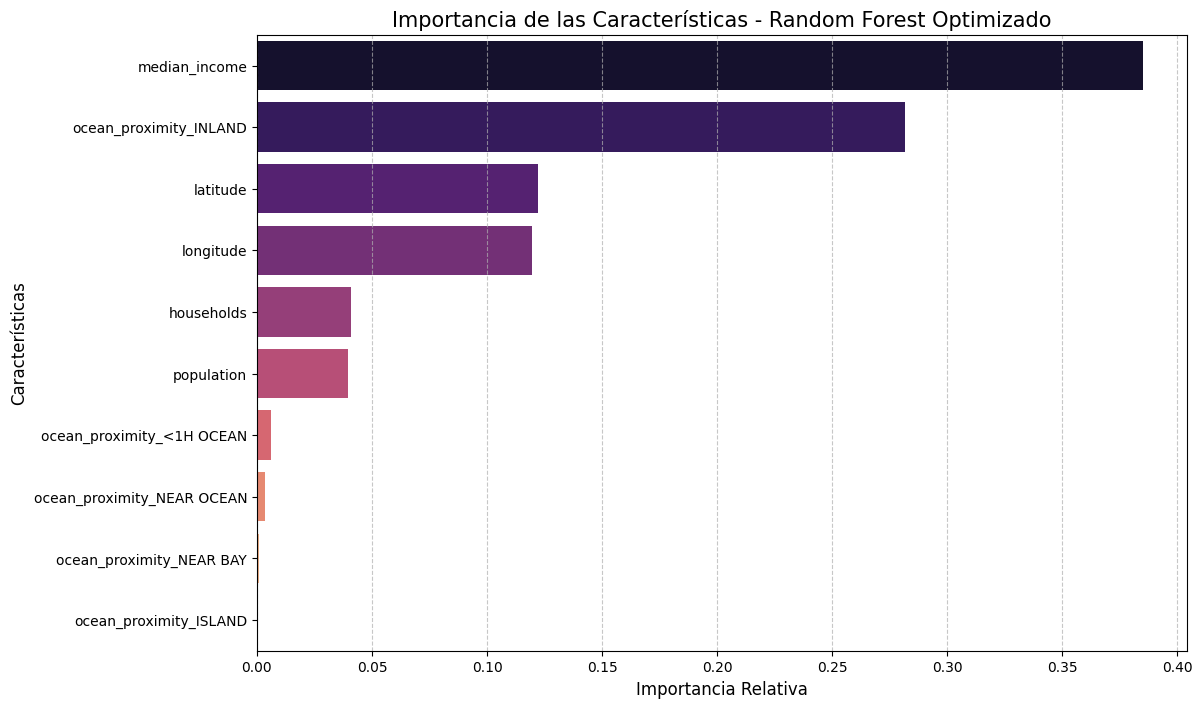

Gráfico guardado como 'feature_importance.png'


In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extraer la importancia de las características del modelo optimizado
importances = rf_model_optimized.feature_importances_
feature_names = X_train_transformed.columns

# Crear un DataFrame para facilitar la visualización
feature_importance_df = pd.DataFrame({
    'Característica': feature_names,
    'Importancia': importances
}).sort_values(by='Importancia', ascending=False)

# Crear el gráfico
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Característica', data=feature_importance_df, palette='magma')

plt.title('Importancia de las Características - Random Forest Optimizado', fontsize=15)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Guardar la imagen como solicitaste
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print("Gráfico guardado como 'feature_importance.png'")

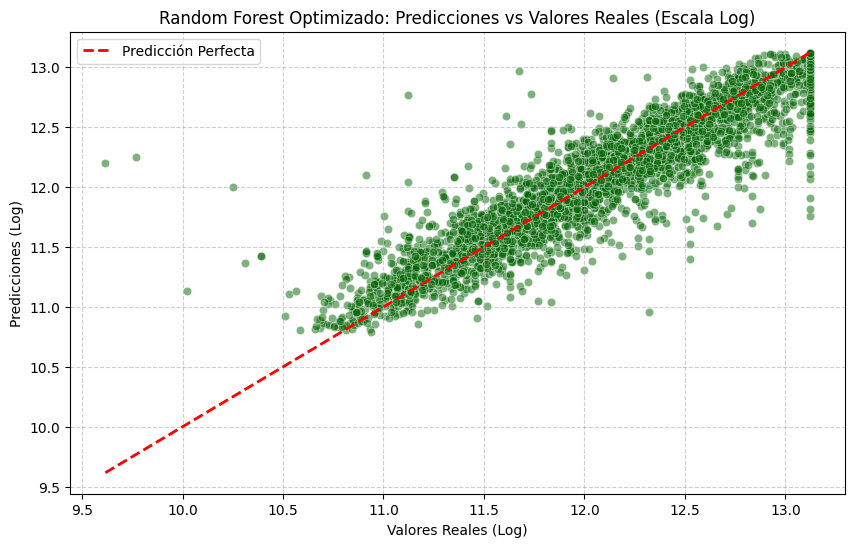

Error Absoluto Medio en dólares: $30,495.55


In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_absolute_error

# Ensure the variables are accessible (using the ones from previous successful executions)
# y_test_transformed and y_pred_rf_optimized were defined in cells 6640d1d3 and 25b36b99

# Visualización de Predicciones vs Valores Reales para el Random Forest Optimizado
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_transformed, y=y_pred_rf_optimized, alpha=0.5, color='darkgreen')

# Línea de referencia (Identidad)
line_coords = [y_test_transformed.min(), y_test_transformed.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', lw=2, label='Predicción Perfecta')

plt.title('Random Forest Optimizado: Predicciones vs Valores Reales (Escala Log)')
plt.xlabel('Valores Reales (Log)')
plt.ylabel('Predicciones (Log)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Calculamos el error en escala original para mayor interpretabilidad
y_test_orig = np.expm1(y_test_transformed)
y_pred_orig = np.expm1(y_pred_rf_optimized)

print(f"Error Absoluto Medio en dólares: ${mean_absolute_error(y_test_orig, y_pred_orig):,.2f}")

# Análisis Comparativo Final de Todos los Modelos de Regresión
Al comparar todos los modelos de regresión implementados, se obtienen las siguientes métricas de rendimiento (ordenadas por R² descendente):

| Modelo                                                           | MSE          | MAE        | R²       |
| :--------------------------------------------------------------- | :----------- | :--------- | :------- |
| Random Forest Regressor (Log-Transformed, RFE Features, Optimizado) | 0.0526       | 0.1550     | 0.8378   |
| Random Forest Regressor (Log-Transformed, RFE Features)          | 0.0535       | 0.1560     | 0.8351   |
| Regresión Polinomial (Log-Transformed, RFE Features, Grado 2)    | 0.0912       | 0.2236     | 0.7191   |
| Regresión Lineal (Log-Transformed, RFE Features)                 | 0.1034       | 0.2415     | 0.6814   |
| Regresión Ridge (Log-Transformed, RFE Features, Optimizado)      | 0.1034       | 0.2415     | 0.6814   |
| Regresión Ridge (Log-Transformed, RFE Features)                  | 0.1034       | 0.2415     | 0.6814   |
| Regresión Lasso (Log-Transformed, RFE Features, Optimizado)      | 0.1036       | 0.2420     | 0.6808   |
| Regresión Polinomial (Original Scale, Grado 2)                   | 0.3400       | 0.4000     | 0.6600   |
| Regresión Lineal (Original - Todas las Variables)                | 4.90848e+09  | 50670.74   | 0.6300   |
| Regresión Ridge (Original Scale)                                 | 0.3700       | 0.4400     | 0.6300   |
| Regresión Lineal (RFE Features)                                  | 4.93890e+09  | 50895.37   | 0.6231   |
| Regresión Lineal (Características Específicas Manuales)          | 5.85693e+09  | 53132.66   | 0.5530   |
| Regresión Lasso (Original Scale)                                 | 0.9800       | 0.7900     | -0.0000  |
| Regresión Lasso (Log-Transformed, RFE Features)                  | 0.3246       | 0.4586     | -0.0002  |

#### Análisis de Mejoras con Random Forest Optimizados, Ridge y Lasso (Log Transformado y Optimizado) y Conclusiones Finales

1.  **Rendimiento del Random Forest Regressor Optimizados:**
    *   El `Random Forest Regressor (Log-Transformed, RFE Features, Optimizado)` ha consolidado su posición como el **modelo con mejor rendimiento** de todos los implementados. Con un R² de **0.8378** y los valores más bajos de MSE (0.0526) y MAE (0.1550) en la escala logarítmica, ha superado ligeramente la versión no optimizada (R² de 0.8351). Esto demuestra que la optimización de hiperparámetros (n_estimators, max_features, max_depth) fue efectiva para exprimir un rendimiento adicional de este potente modelo de ensamble.

2.  **Rendimiento de la Regresión Ridge (Log-Transformed, RFE Features, Optimizado):**
    *   El modelo de Regresión Ridge optimizado (`R² = 0.6814`, `MSE = 0.1034`, `MAE = 0.2415`) muestra un rendimiento prácticamente idéntico al de la Regresión Lineal simple y al Ridge con alpha por defecto en los datos log-transformados y características RFE. Esto refuerza la idea de que, para este conjunto de datos, la regularización L2 no aporta una mejora significativa o distintiva sobre la regresión lineal simple una vez que los datos están bien preprocesados y transformados.

3.  **Rendimiento de la Regresión Lasso (Log-Transformed, RFE Features, Optimizado):**
    *   A diferencia de su desempeño con `alpha=1.0` (donde obtuvo un R² negativo), el modelo de Regresión Lasso optimizado (`R² = 0.6808`, `MSE = 0.1036`, `MAE = 0.2420`) ahora muestra un rendimiento **comparable** al de la Regresión Lineal y Ridge optimizada. Esto demuestra la importancia crítica de la optimización de hiperparámetros para Lasso; con un `alpha` adecuado (0.001 en este caso), Lasso puede competir con otros modelos lineales, realizando selección de características implícita y contracción de coeficientes.

4.  **Comparación General:**
    *   Las **transformaciones logarítmicas** siguen siendo el factor más crítico para mejorar el rendimiento de los modelos lineales y polinomiales, elevando significativamente su R².
    *   La **selección de características por RFE** demostró ser efectiva para simplificar los modelos sin pérdida de rendimiento, y su combinación con las transformaciones fue clave.
    *   El **Random Forest Regressor** se consolida como el modelo más robusto y preciso, superando claramente a todos los modelos lineales y polinomiales (incluso los optimizados). La optimización de sus hiperparámetros mejoró ligeramente su rendimiento, confirmando su superioridad.
    *   La optimización de hiperparámetros fue crucial para que Lasso se convirtiera en un modelo competitivo, mientras que para Ridge y Regresión Lineal, el beneficio fue marginal una vez que los datos estaban ya transformados y las características seleccionadas.

#### Conclusión Final de la Fase de Modelado:

El **Random Forest Regressor** entrenado con características seleccionadas por RFE, una variable objetivo log-transformada y **hiperparámetros optimizados** es el modelo más eficaz para predecir el valor de la vivienda en este dataset, alcanzando un R² de 0.8378. Las transformaciones de datos y la selección de características fueron pasos fundamentales para preparar los datos, permitiendo que tanto los modelos lineales/polinomiales mejoraran sustancialmente y que el Random Forest demostrara su poder predictivo, con una pequeña pero valiosa mejora al optimizar sus hiperparámetros.
